#  G6 FOOD PRICE PREDICTION


---

# 1. Business understanding

## 1.1 Business Overview

Over the last 24 months, the Kenyan market has been characterized by extreme volatility in the prices of essential food items, ranging from fresh produce like tomatoes and avocados to staples such as maize, beans, and flour. These unpredictable fluctuations create a destabilizing cycle for both consumers and producers, as the market rapidly oscillates between wasteful surpluses and 
acute shortages.
 
This project seeks to mitigate these imbalances by utilizing time-series forecasting to provide reliable price predictions. By delivering actionable insights—such as forecasting the value of a 90kg bag of maize half a year into the future—the model empowers farmers in regions like Uasin Gishu to make informed, data-driven decisions on whether to maintain current crop cycles or pivot to more viable alternatives.

## 1.2 Stakeholders
• Consumers: To aid in household budgeting and long-term food procurement planning.

• Farmers & Saccos: To determine optimal planting cycles and market entry timing to 
maximize profit. 

• Government Agencies (Ministry of Agriculture/NCPB): To inform policy interventions such as 
food subsidies or strategic grain reserve management. 

• General Insurance Providers: For potential use in agricultural insurance risk assessment and 
index-based weather insurance.

## 1.3 Business Objectives
### Main Objective:
Develop and deploy a multivariate machine learning model to forecast the prices of key commodities (Maize, Milk, Beans) across different Kenyan markets
### Specific objective:
Integrate external causal factors—specifically rainfall and fuel prices—to enhance the model's predictive accuracy regarding price shocks

## 1.4 Project shortcomings
• Direct Insurance Underwriting: While insights benefit insurers, direct claims management is beyond the scope. 

• Logistics Management: The project does not automate the physical supply chain or transport of goods.

# 2. Data Understanding

## 2.1 Data Sources:
The project will leverage three primary online data sources to ensure a comprehensive feature set:

• WFP Food Prices (HDX): Historical monthly price data for various commodities and markets across Kenya.

• CHIRPS Rainfall Data (Google Earth Engine/HDX): Historical precipitation levels to track climate-related supply shifts. 

• EPRA Fuel Prices: Historical diesel prices to account for transportation and production costs.

## 2.2 Target and Predictors:
• Target: The future price of a specific commodity (e.g., KES per 90kg bag of maize).

• Predictors:

o Time Indicators: Month, year, and seasonality markers. 

o Market Metadata: Region, market name, and commodity type.

o External Features: Monthly average rainfall (mm) and Diesel retail prices (KES)

# 3. Workflow Phases: 
1. Data Exploration
2. Data Preparation & Merging
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Lag Creation
5. Modelling (Linear Regression → Gradient Boosted Trees)
6. Evaluation
7. Prediction Interface


##  4. Importing libraries

In [1]:
# Core Libraries 
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# Modelling 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer




---
##  4.1.  Loading the data

Three independent datasets must be loaded and understood before merging.

### 4a. WFP Food Prices (Target Dataset)

In [2]:
# Load WFP Food Prices 
wfp = pd.read_csv('food_prices_ken.csv', parse_dates=['date'])

print(f'Shape: {wfp.shape}')
print(f'Date range: {wfp["date"].min().date()} → {wfp["date"].max().date()}')
print(f'Unique counties (admin2): {wfp["admin2"].nunique()}')
print(f'Unique commodities: {wfp["commodity"].nunique()}')
print()
wfp.head()

Shape: (19005, 16)
Date range: 2006-01-15 → 2026-03-15
Unique counties (admin2): 27
Unique commodities: 51



,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24


In [3]:
# Summary statistics 
print('=== Missing Values ===')
print(wfp.isnull().sum())
print()
print('=== Numeric Summary ===')
wfp[['price', 'usdprice']].describe()

=== Missing Values ===
date             0
admin1          39
admin2          39
market           0
market_id        0
latitude        39
longitude       39
category         0
commodity        0
commodity_id     0
unit             0
priceflag        0
pricetype        0
currency         0
price            0
usdprice         0
dtype: int64

=== Numeric Summary ===


,price,usdprice
count,19005.000000,19005.000000
mean,1327.815265,12.127999
std,2609.366827,23.113554
min,5.000000,0.039000
25%,67.000000,0.600000
50%,133.000000,1.060000
75%,1105.000000,10.360000
max,19800.000000,184.820000


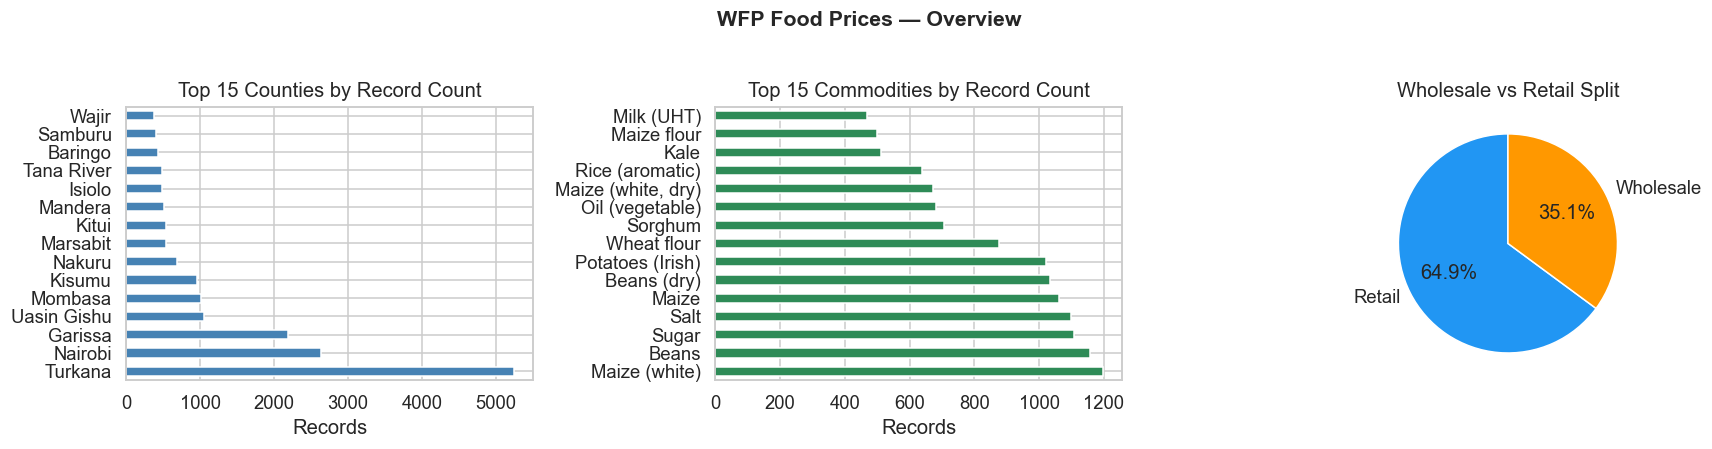

In [4]:
#  Key field distributions 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Records per county
wfp['admin2'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Counties by Record Count')
axes[0].set_xlabel('Records')

# Records per commodity (top 15)
wfp['commodity'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top 15 Commodities by Record Count')
axes[1].set_xlabel('Records')

# Price type split
wfp['pricetype'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%',
                                      colors=['#2196F3', '#FF9800'], startangle=90)
axes[2].set_title('Wholesale vs Retail Split')
axes[2].set_ylabel('')

plt.suptitle('WFP Food Prices — Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4b. CHIRPS Rainfall Data

In [5]:
# Load Rainfall Data 
rain = pd.read_csv('ken-rainfall-subnat-full.csv', parse_dates=['date'])

print(f'Shape: {rain.shape}')
print(f'Date range: {rain["date"].min().date()} → {rain["date"].max().date()}')
print(f'Admin levels: {rain["adm_level"].unique()}')
print(f'Unique PCODEs: {rain["PCODE"].nunique()}')
print()
rain.head()

Shape: (132273, 15)
Date range: 1981-01-01 → 2026-05-01
Admin levels: [1 2]
Unique PCODEs: 81



,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,1981-01-01,1,51325,KE019,427.0,7.372365,15.759407,NaN,NaN,NaN,NaN,59.598840,NaN,NaN,final
1,1981-01-11,1,51325,KE019,427.0,4.325527,19.294770,NaN,NaN,NaN,NaN,38.384920,NaN,NaN,final
2,1981-01-21,1,51325,KE019,427.0,5.569087,16.265417,17.266980,51.319595,NaN,NaN,49.700817,39.536823,NaN,final
3,1981-02-01,1,51325,KE019,427.0,5.882904,12.719282,15.777517,48.279470,NaN,NaN,61.418427,38.997230,NaN,final
4,1981-02-11,1,51325,KE019,427.0,17.180328,18.768618,28.632318,47.753320,NaN,NaN,93.317700,63.753933,NaN,final


In [6]:
# Rainfall fields glossary 
glossary = {
    'rfh':     'Rainfall height for the current dekad (10-day period) in mm',
    'rfh_avg': 'Historical average rainfall for this dekad',
    'r1h':     'Cumulative rainfall over the past 1 month (mm)',
    'r1h_avg': 'Historical 1-month average rainfall',
    'r3h':     'Cumulative rainfall over the past 3 months (mm)',
    'r3h_avg': 'Historical 3-month average rainfall',
    'rfq':     'Rainfall anomaly (current vs. average, %) — dekadal',
    'r1q':     'Rainfall anomaly — 1-month rolling',
    'r3q':     'Rainfall anomaly — 3-month rolling',
}
print('CHIRPS Rainfall Feature ')
print('=' * 55)
for k, v in glossary.items():
    print(f'  {k:<10} {v}')

CHIRPS Rainfall Feature 
  rfh        Rainfall height for the current dekad (10-day period) in mm
  rfh_avg    Historical average rainfall for this dekad
  r1h        Cumulative rainfall over the past 1 month (mm)
  r1h_avg    Historical 1-month average rainfall
  r3h        Cumulative rainfall over the past 3 months (mm)
  r3h_avg    Historical 3-month average rainfall
  rfq        Rainfall anomaly (current vs. average, %) — dekadal
  r1q        Rainfall anomaly — 1-month rolling
  r3q        Rainfall anomaly — 3-month rolling


In [7]:
print('Missing values in rainfall data:')
print(rain.isnull().sum())
print()
print('County-level PCODEs (adm_level = 1):')
print(rain[rain['adm_level']==1]['PCODE'].unique())

Missing values in rainfall data:
date           0
adm_level      0
adm_id         0
PCODE          0
n_pixels       0
rfh            0
rfh_avg        0
r1h          162
r1h_avg      162
r3h          648
r3h_avg      648
rfq            0
r1q          162
r3q          648
version        0
dtype: int64

County-level PCODEs (adm_level = 1):
['KE019' 'KE004' 'KE010' 'KE047' 'KE008' 'KE043' 'KE023' 'KE037']


### 4c. EPRA Fuel Prices

In [8]:
# Load Fuel Prices 
fuel = pd.read_csv('Pump Prices  Energy and Petroleum Regulatory Authority.csv')

# Standardise date — multiple formats exist in this dataset
fuel['date'] = pd.to_datetime(fuel['Date'], dayfirst=True)
fuel = fuel.drop(columns=['Date']).sort_values('date').reset_index(drop=True)

print(f'Shape: {fuel.shape}')
print(f'Date range: {fuel["date"].min().date()} → {fuel["date"].max().date()}')
print(f'Towns covered: {fuel["Town"].unique()}')
print()
fuel.head(8)

Shape: (197, 5)
Date range: 2010-01-15 → 2026-04-16
Towns covered: ['Nairobi']



,Town,Super (PMS),Diesel (AGO),Kerosene (IK),date
0,Nairobi,98.50,89.2,80.10,2010-01-15
1,Nairobi,99.80,90.5,81.40,2010-02-15
2,Nairobi,88.52,76.9,61.35,2010-03-15
3,Nairobi,90.64,79.9,61.80,2010-04-15
4,Nairobi,103.70,94.4,85.30,2010-05-15
5,Nairobi,105.00,95.7,86.60,2010-06-15
6,Nairobi,106.30,97.0,87.90,2010-07-15
7,Nairobi,107.60,98.3,89.20,2010-08-15


plot the fuel price trend across the years

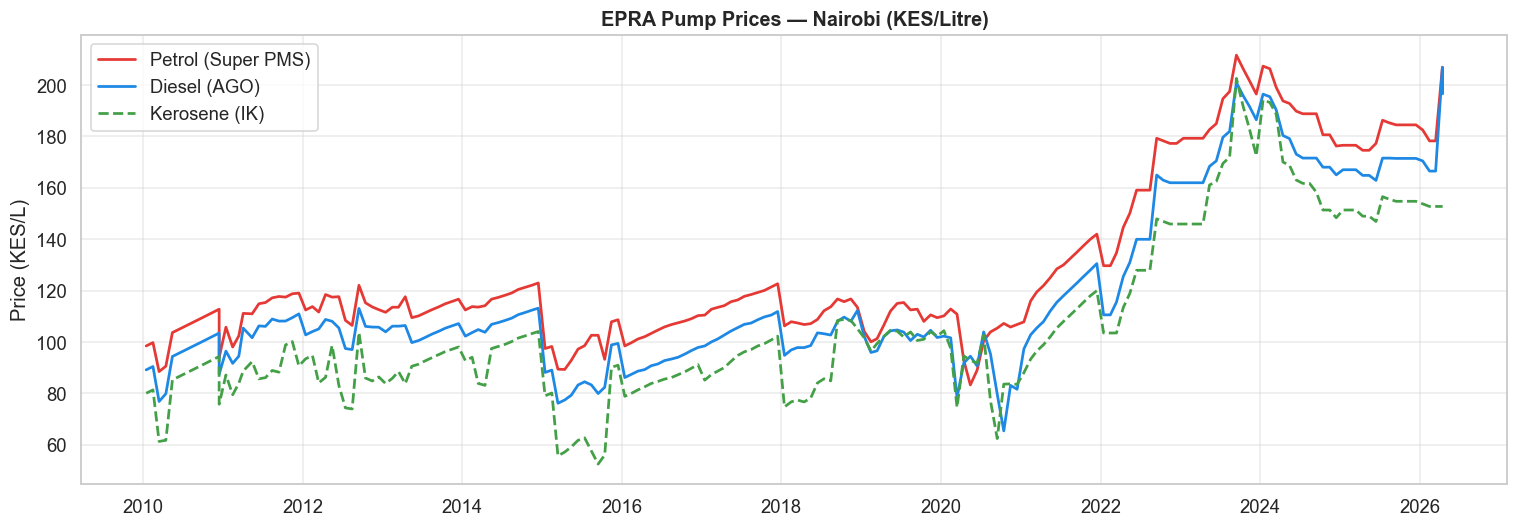

In [9]:
# Plot fuel price trends 
nairobi_fuel = fuel[fuel['Town'] == 'Nairobi'].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(nairobi_fuel['date'], nairobi_fuel['Super (PMS)'],  label='Petrol (Super PMS)',  color='#E53935', lw=1.8)
ax.plot(nairobi_fuel['date'], nairobi_fuel['Diesel (AGO)'], label='Diesel (AGO)',         color='#1E88E5', lw=1.8)
ax.plot(nairobi_fuel['date'], nairobi_fuel['Kerosene (IK)'],label='Kerosene (IK)',        color='#43A047', lw=1.8, ls='--')
ax.set_title('EPRA Pump Prices — Nairobi (KES/Litre)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (KES/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

---
##  4.2 Data Preparation & Merging

### 4.2a. Standardise Dates to Monthly (YYYY-MM-DD)

Step 1: Normalise all dates to month-start

In [10]:
# WFP — already monthly
wfp['date_month'] = wfp['date'].dt.to_period('M').dt.to_timestamp()

# Fuel — irregular dates; take median monthly price
fuel['date_month'] = fuel['date'].dt.to_period('M').dt.to_timestamp()
fuel_monthly = (
    fuel[fuel['Town'] == 'Nairobi']
    .groupby('date_month')[['Super (PMS)', 'Diesel (AGO)', 'Kerosene (IK)']]
    .median()
    .reset_index()
)
fuel_monthly.columns = ['date_month', 'petrol_kes', 'diesel_kes', 'kerosene_kes']
print('Fuel monthly shape:', fuel_monthly.shape)
fuel_monthly.tail()

Fuel monthly shape: (195, 4)


,date_month,petrol_kes,diesel_kes,kerosene_kes
190,2025-12-01,184.520,171.470,154.78
191,2026-01-01,182.520,170.470,153.78
192,2026-02-01,178.280,166.540,152.78
193,2026-03-01,178.280,166.540,152.78
194,2026-04-01,202.285,201.735,152.78


### 4.2b. Rainfall — Aggregate Dekadal → Monthly

In [11]:
# PCODE → County name mapping 
# Using Kenya official PCODE standard (47 counties)
# Only counties covered by EPRA/WFP data need mapping
pcode_county_map = {
    # Standard 2-char PCODEs (adm_level 1 in CHIRPS)
    'KE001': 'Mombasa',     'KE002': 'Kwale',       'KE003': 'Kilifi',
    'KE004': 'Tana River',  'KE005': 'Lamu',         'KE006': 'Taita Taveta',
    'KE007': 'Garissa',     'KE008': 'Wajir',        'KE009': 'Mandera',
    'KE010': 'Marsabit',    'KE011': 'Isiolo',       'KE012': 'Meru',
    'KE013': 'Tharaka Nithi','KE014': 'Embu',        'KE015': 'Kitui',
    'KE016': 'Machakos',    'KE017': 'Makueni',      'KE018': 'Nyandarua',
    'KE019': 'Nyeri',       'KE020': 'Kirinyaga',    'KE021': "Muranga",
    'KE022': 'Kiambu',      'KE023': 'Turkana',      'KE024': 'West Pokot',
    'KE025': 'Samburu',     'KE026': 'Trans Nzoia',  'KE027': 'Uasin Gishu',
    'KE028': 'Elgeyo Marakwet','KE029': 'Nandi',     'KE030': 'Baringo',
    'KE031': 'Laikipia',    'KE032': 'Nakuru',       'KE033': 'Narok',
    'KE034': 'Kajiado',     'KE035': 'Kericho',      'KE036': 'Bomet',
    'KE037': 'Kakamega',    'KE038': 'Vihiga',       'KE039': 'Bungoma',
    'KE040': 'Busia',       'KE041': 'Siaya',        'KE042': 'Kisumu',
    'KE043': 'Homa Bay',    'KE044': 'Migori',       'KE045': 'Kisii',
    'KE046': 'Nyamira',     'KE047': 'Nairobi',
}

# For sub-county PCODEs like 'KE022122', the parent county is the first 5 chars
def pcode_to_county(pcode):
    key = pcode[:5]  # e.g. 'KE022' from 'KE022122'
    return pcode_county_map.get(key, None)

rain['county'] = rain['PCODE'].apply(pcode_to_county)
print('PCODEs with no county mapping:', rain[rain['county'].isna()]['PCODE'].unique()[:10])
rain = rain[rain['county'].notna()].copy()
print(f'Rainfall rows after mapping: {len(rain)}')

PCODEs with no county mapping: []
Rainfall rows after mapping: 132273


In [12]:
# Aggregate dekadal rainfall → monthly per county 
rain['date_month'] = rain['date'].dt.to_period('M').dt.to_timestamp()

rain_monthly = (
    rain.groupby(['date_month', 'county'])
    .agg(
        rainfall_mm   = ('rfh',     'sum'),    # total mm for the month
        rainfall_avg  = ('rfh_avg', 'mean'),   # historical monthly average
        r1h           = ('r1h',     'last'),   # 1-month rolling (last dekad is most recent)
        r3h           = ('r3h',     'last'),   # 3-month rolling
        rainfall_anom = ('rfq',     'mean'),   # anomaly %
    )
    .reset_index()
)

print('Monthly rainfall shape:', rain_monthly.shape)
print('Counties in rainfall:', sorted(rain_monthly['county'].unique()))
rain_monthly.head()

Monthly rainfall shape: (25615, 7)
Counties in rainfall: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo Marakwet', 'Embu', 'Garissa', 'Homa Bay', 'Isiolo', 'Kajiado', 'Kakamega', 'Kericho', 'Kiambu', 'Kilifi', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Laikipia', 'Lamu', 'Machakos', 'Makueni', 'Mandera', 'Marsabit', 'Meru', 'Migori', 'Mombasa', 'Muranga', 'Nairobi', 'Nakuru', 'Nandi', 'Narok', 'Nyamira', 'Nyandarua', 'Nyeri', 'Samburu', 'Siaya', 'Taita Taveta', 'Tana River', 'Tharaka Nithi', 'Trans Nzoia', 'Turkana', 'Uasin Gishu', 'Vihiga', 'Wajir', 'West Pokot']


,date_month,county,rainfall_mm,rainfall_avg,r1h,r3h,rainfall_anom
0,1981-01-01,Baringo,13.319234,9.958047,7.421053,NaN,49.891181
1,1981-01-01,Bomet,65.770188,27.815266,29.913044,NaN,50.741880
2,1981-01-01,Bungoma,36.528572,14.973360,15.100000,NaN,56.066522
3,1981-01-01,Busia,56.735294,19.629811,28.000000,NaN,59.195616
4,1981-01-01,Elgeyo Marakwet,18.062756,12.632012,8.301887,NaN,47.327582


### 4.2c. WFP — Filter & Focus on Key Commodities

In [13]:
# Focus on Retail prices for key staples 
# (Retail is most relevant to consumers & farmers)
KEY_COMMODITIES = [
    'Maize (white)', 'Maize', 'Beans (dry)', 'Beans',
    'Milk (cow, pasteurized)', 'Milk (cow, fresh)',
    'Maize flour', 'Wheat flour'
]

wfp_filtered = wfp[
    (wfp['commodity'].isin(KEY_COMMODITIES)) &
    (wfp['pricetype'] == 'Retail')
].copy()

# Consolidate commodity names for easier modelling
commodity_map = {
    'Maize (white)': 'Maize', 'Maize': 'Maize',
    'Beans (dry)':   'Beans', 'Beans': 'Beans',
    'Milk (cow, pasteurized)': 'Milk', 'Milk (cow, fresh)': 'Milk',
    'Maize flour': 'Maize Flour', 'Wheat flour': 'Wheat Flour'
}
wfp_filtered['commodity_clean'] = wfp_filtered['commodity'].map(commodity_map)

print(f'Filtered WFP shape: {wfp_filtered.shape}')
print('Commodity distribution:')
print(wfp_filtered['commodity_clean'].value_counts())

Filtered WFP shape: (4140, 18)
Commodity distribution:
Maize          1179
Beans          1094
Wheat Flour     875
Maize Flour     500
Milk            492
Name: commodity_clean, dtype: int64


In [14]:
# Monthly average price per county-commodity 
wfp_monthly = (
    wfp_filtered.groupby(['date_month', 'admin2', 'commodity_clean'])
    .agg(
        price    = ('price',    'mean'),
        usdprice = ('usdprice', 'mean'),
        n_obs    = ('price',    'count')
    )
    .reset_index()
    .rename(columns={'admin2': 'county', 'commodity_clean': 'commodity'})
)

print('WFP monthly shape:', wfp_monthly.shape)
wfp_monthly.head()

WFP monthly shape: (1753, 6)


,date_month,county,commodity,price,usdprice,n_obs
0,2006-01-01,Kitui,Maize,17.0,0.24,1
1,2006-01-01,Mandera,Maize,30.0,0.42,1
2,2006-01-01,Marsabit,Maize,21.0,0.29,1
3,2006-01-01,Nairobi,Milk,22.0,0.31,1
4,2006-01-01,Turkana,Maize,26.0,0.36,1


### 4.3. Merging the datasets
• Merging: Datasets will be joined on the Date and Admin1 (County) levels to align prices with localised rainfall and fuel costs.

In [15]:
#Step 3: Merge WFP + Rainfall + Fuel 
# Merge 1: WFP + Rainfall (on date + county)
df_merged = wfp_monthly.merge(
    rain_monthly,
    on=['date_month', 'county'],
    how='left'
)

# Merge 2: + Fuel (on date only; Nairobi price = national proxy)
df_merged = df_merged.merge(
    fuel_monthly,
    on='date_month',
    how='left'
)

df_merged = df_merged.sort_values(['county', 'commodity', 'date_month']).reset_index(drop=True)

print(f'Merged dataset shape: {df_merged.shape}')
print(f'Date range: {df_merged["date_month"].min().date()} → {df_merged["date_month"].max().date()}')
print()
print('Missing values after merge:')
print(df_merged.isnull().sum())

Merged dataset shape: (1753, 14)
Date range: 2006-01-01 → 2026-03-01

Missing values after merge:
date_month         0
county             0
commodity          0
price              0
usdprice           0
n_obs              0
rainfall_mm       19
rainfall_avg      19
r1h               19
r3h               19
rainfall_anom     19
petrol_kes       219
diesel_kes       219
kerosene_kes     219
dtype: int64


### 4.4. Creating Lag Features (Crucial!)
• Lagging: Rainfall and fuel features will be "lagged" by 1–3 months to capture the delayed impact of weather and transport costs on food prices.


> *A drought today does not change the price of maize tomorrow — it changes it in 3–6 months.*

In [16]:
# Step 4: Lag Features 
# Sort properly before shifting
df = df_merged.sort_values(['county', 'commodity', 'date_month']).copy()

group_cols = ['county', 'commodity']

# Rainfall lags (3 & 6 months) — weather impact is delayed
for lag in [1, 3, 6]:
    df[f'rainfall_lag_{lag}'] = (
        df.groupby(group_cols)['rainfall_mm'].shift(lag)
    )

# Rainfall lags
for lag in [1, 3]:
    df[f'rainfall_anom_lag_{lag}'] = (
        df.groupby(group_cols)['rainfall_anom'].shift(lag)
    )

# Fuel lags (1 & 2 months) — transport costs feed through faster
for lag in [1, 2]:
    df[f'diesel_lag_{lag}'] = (
        df.groupby(group_cols)['diesel_kes'].shift(lag)
    )

# Price lags (autoregressive features)
for lag in [1, 3, 6, 12]:
    df[f'price_lag_{lag}'] = (
        df.groupby(group_cols)['price'].shift(lag)
    )

# 3-month rolling mean price (trend feature)
df['price_rolling_3'] = (
    df.groupby(group_cols)['price']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
)

# Time features 
df['year']  = df['date_month'].dt.year
df['month'] = df['date_month'].dt.month

# Cyclical encoding of month (captures seasonality)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print(f'Dataset shape after feature engineering: {df.shape}')
print('New lag & time columns added:', [c for c in df.columns if 'lag' in c or c in ['year','month','month_sin','month_cos']])

Dataset shape after feature engineering: (1753, 30)
New lag & time columns added: ['rainfall_lag_1', 'rainfall_lag_3', 'rainfall_lag_6', 'rainfall_anom_lag_1', 'rainfall_anom_lag_3', 'diesel_lag_1', 'diesel_lag_2', 'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12', 'year', 'month', 'month_sin', 'month_cos']


---
# 5. Exploratory Data Analysis (EDA)

This section provides an in-depth analysis of **all key food commodities** tracked in the dataset:
- **Maize** — primary staple grain
- **Beans** — key protein source  
- **Milk** — dairy staple
- **Maize Flour** — processed staple
- **Wheat Flour** — secondary grain staple


## 5.1. Price Trends for All Key Commodities Across Counties

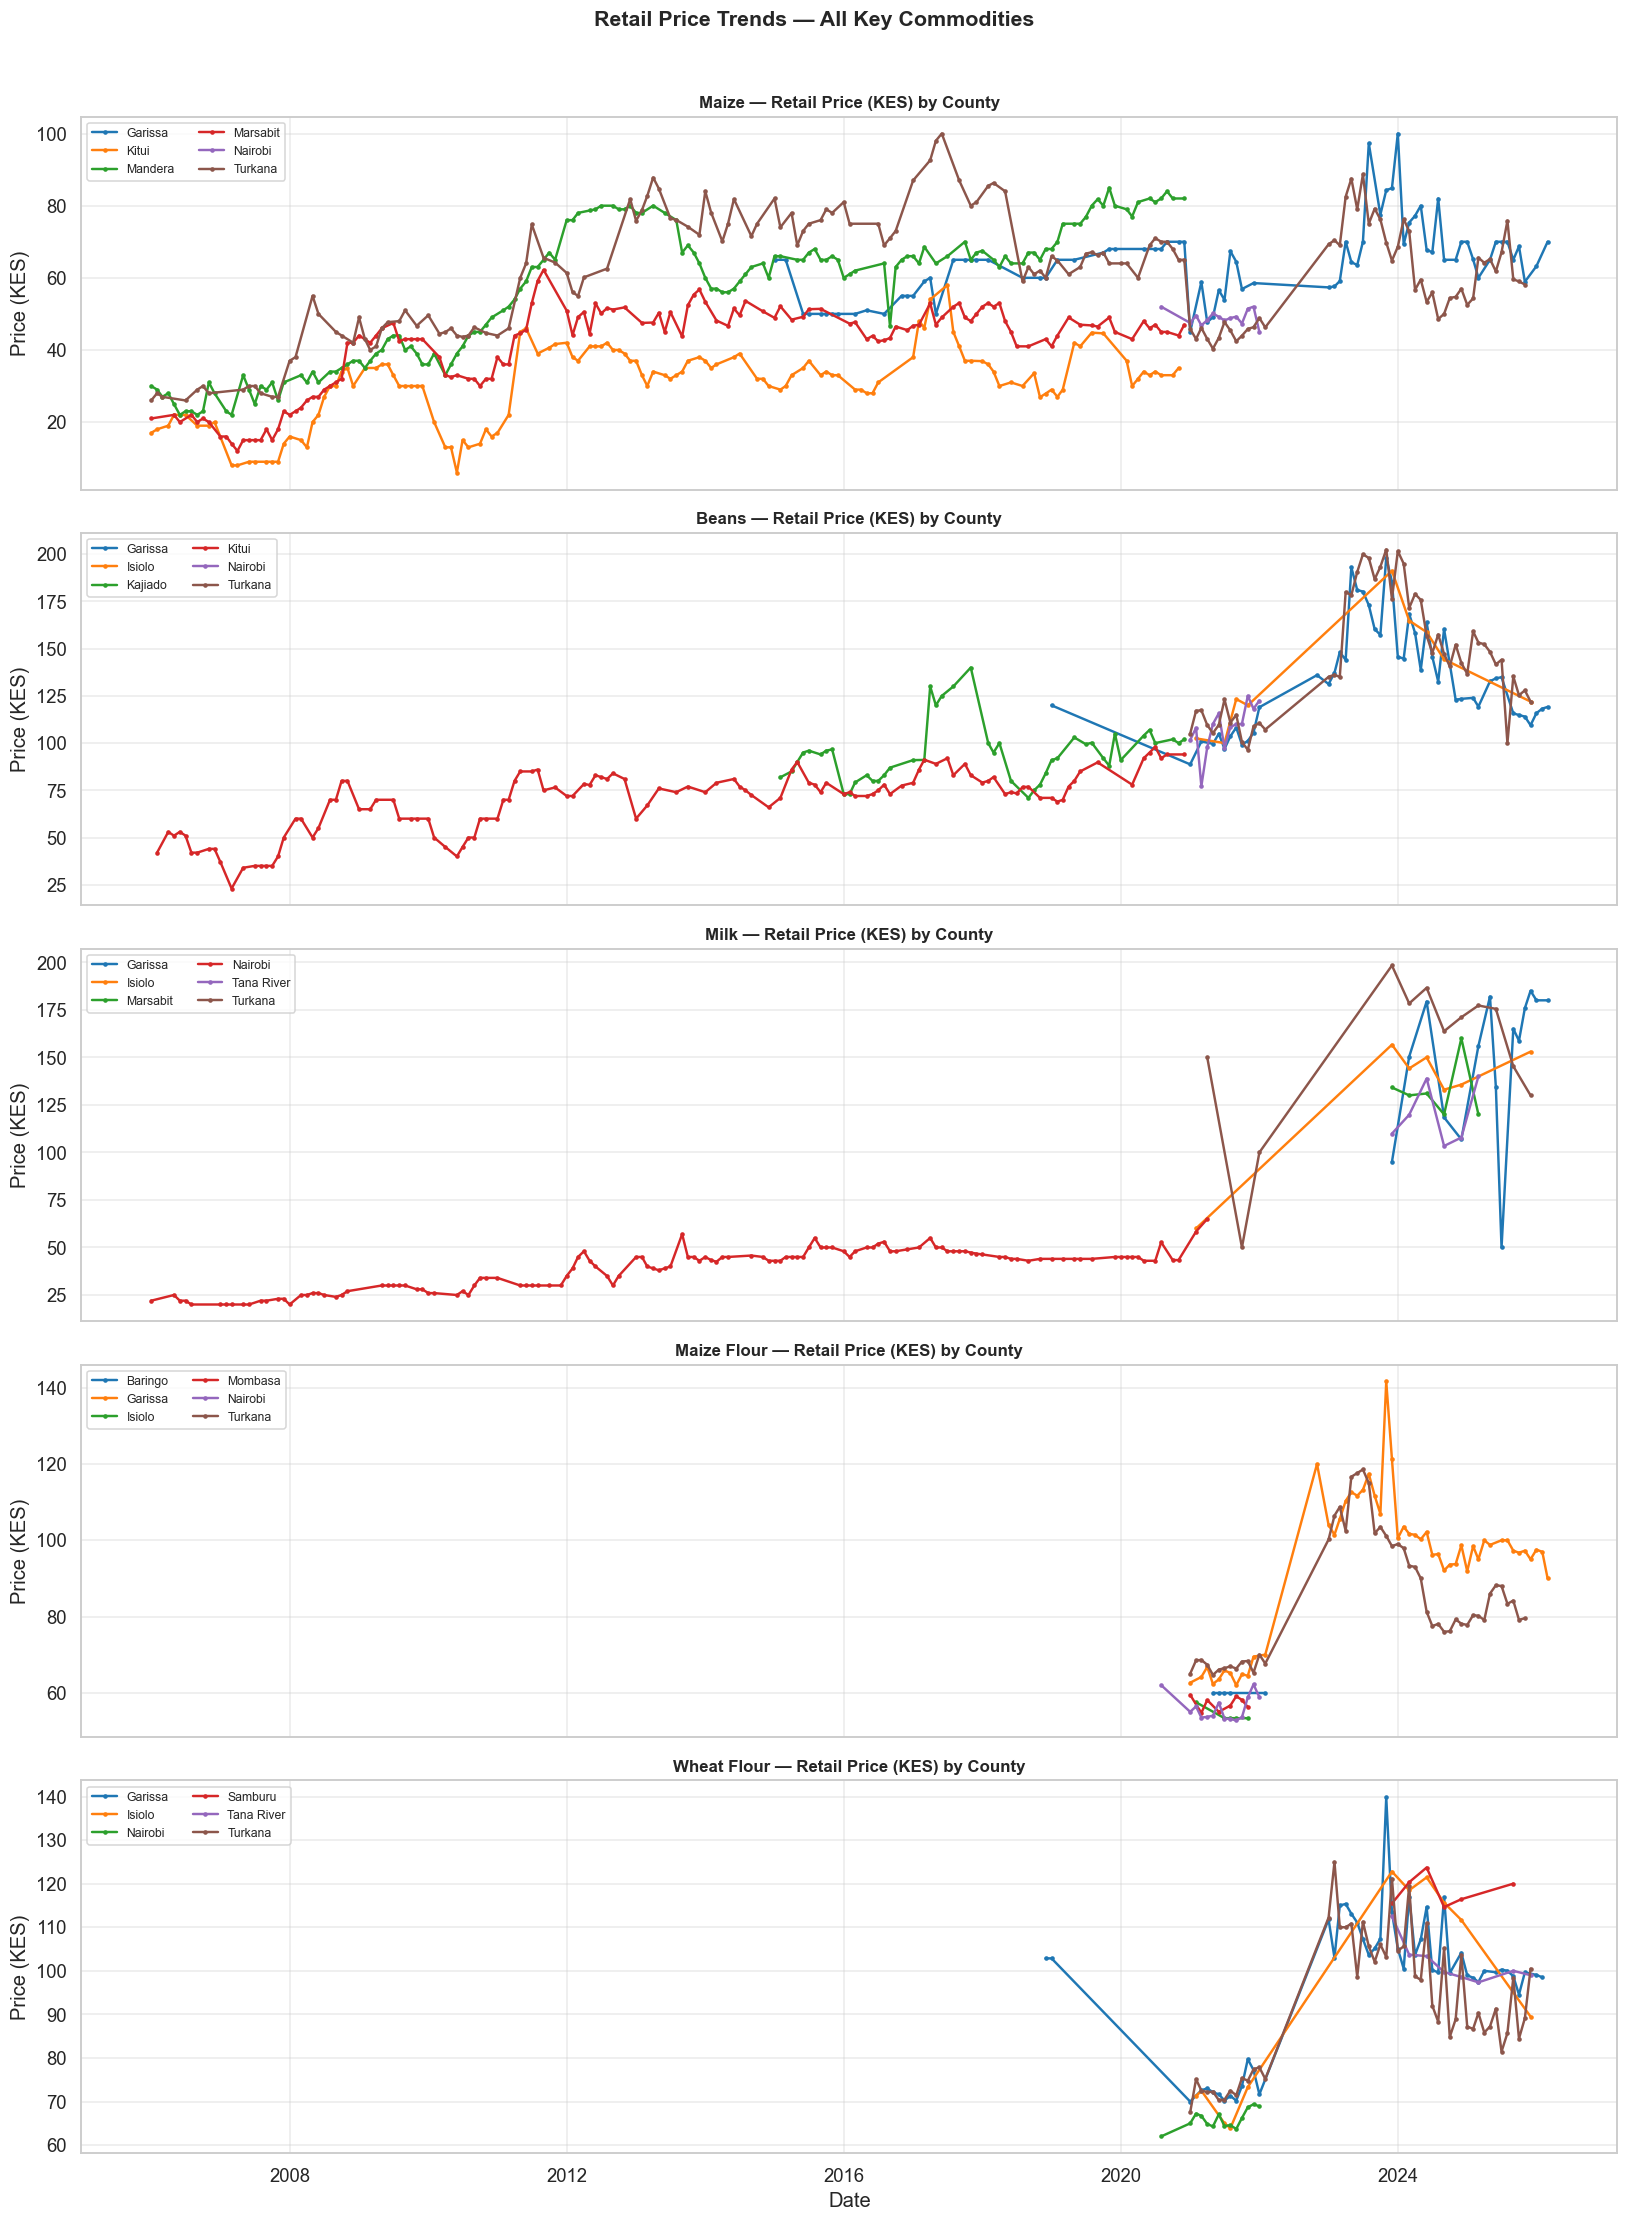

In [17]:
# Price trends for ALL key commodities across top counties
KEY_COMM_LIST = [c for c in ['Maize', 'Beans', 'Milk', 'Maize Flour', 'Wheat Flour'] 
                 if c in df['commodity'].unique()]

n_comm = len(KEY_COMM_LIST)
fig, axes = plt.subplots(n_comm, 1, figsize=(15, 4 * n_comm), sharex=True)
if n_comm == 1:
    axes = [axes]

palette = sns.color_palette('tab10', 8)

for ax, commodity in zip(axes, KEY_COMM_LIST):
    sub = df[df['commodity'] == commodity].copy()
    top_counties = sub.groupby('county')['n_obs'].sum().nlargest(6).index.tolist()
    sub_top = sub[sub['county'].isin(top_counties)]
    for j, (county, grp) in enumerate(sub_top.groupby('county')):
        ax.plot(grp['date_month'], grp['price'], label=county,
                lw=1.6, marker='o', ms=2, color=palette[j])
    ax.set_title(f'{commodity} — Retail Price (KES) by County', fontweight='bold', fontsize=11)
    ax.set_ylabel('Price (KES)')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.suptitle('Retail Price Trends — All Key Commodities', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5.2. Price Distribution & Spread by Commodity

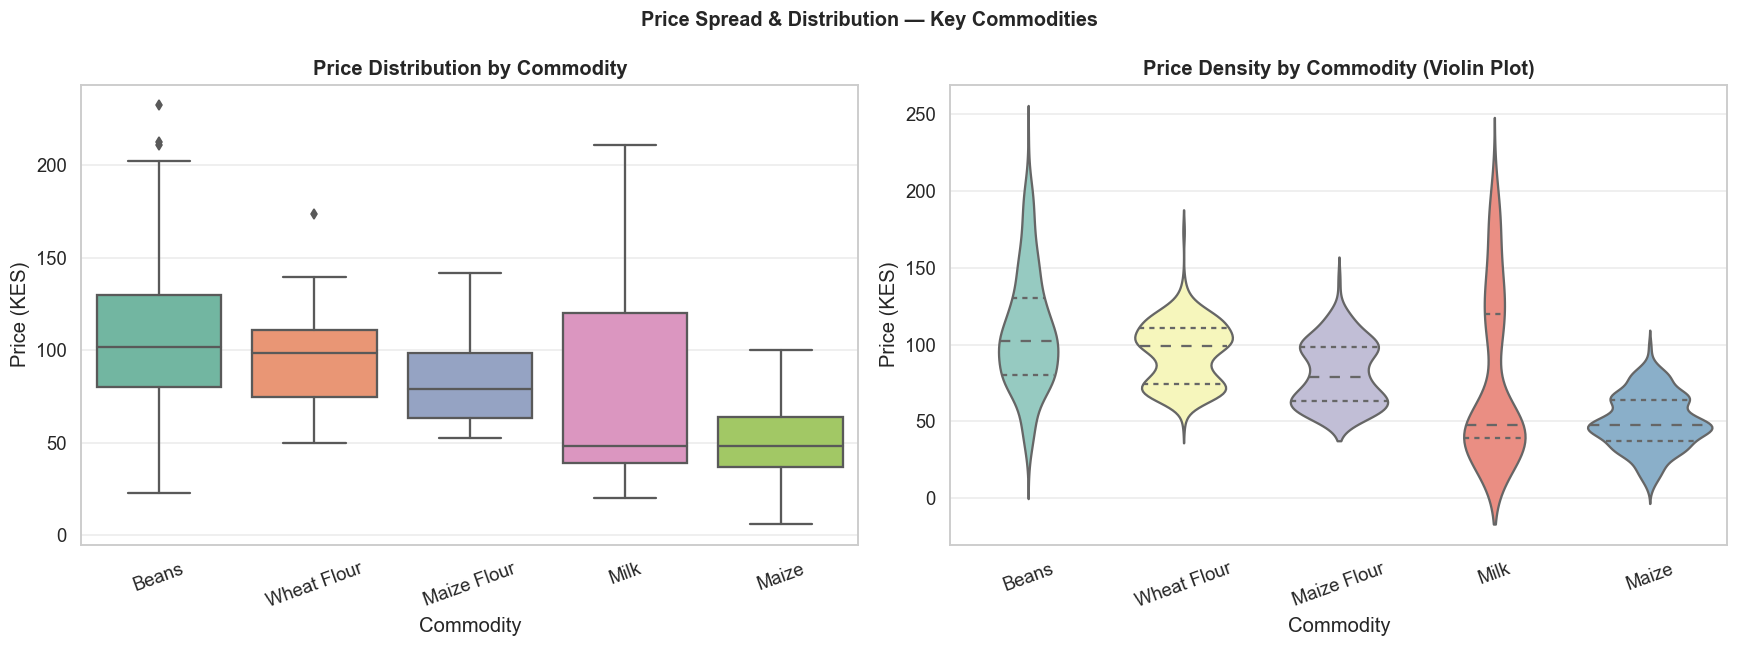


Descriptive Statistics — Key Commodities:
               N   Mean   Std   Min    Q1  Median     Q3    Max
commodity                                                      
Beans        404  108.4  38.5  23.0  80.0   102.0  130.0  232.3
Maize        799   49.7  17.8   6.0  37.0    48.0   64.0  100.0
Maize Flour  140   81.1  20.5  52.7  63.3    79.1   98.7  141.7
Milk         207   76.2  53.4  20.0  39.0    48.0  120.0  211.0
Wheat Flour  203   94.5  20.1  50.0  74.6    98.8  110.9  173.8


In [18]:
# Box plots + violin plots — price spread per commodity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
df_key = df[df['commodity'].isin(KEY_COMM_LIST)].copy()
comm_order = df_key.groupby('commodity')['price'].median().sort_values(ascending=False).index.tolist()

sns.boxplot(data=df_key, x='commodity', y='price', order=comm_order,
            palette='Set2', ax=axes[0])
axes[0].set_title('Price Distribution by Commodity', fontweight='bold')
axes[0].set_xlabel('Commodity')
axes[0].set_ylabel('Price (KES)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.4)

# Violin plot
sns.violinplot(data=df_key, x='commodity', y='price', order=comm_order,
               palette='Set3', ax=axes[1], inner='quartile')
axes[1].set_title('Price Density by Commodity (Violin Plot)', fontweight='bold')
axes[1].set_xlabel('Commodity')
axes[1].set_ylabel('Price (KES)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Price Spread & Distribution — Key Commodities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print('\nDescriptive Statistics — Key Commodities:')
print('=' * 70)
stats = df_key.groupby('commodity')['price'].agg(['count','mean','std','min',
         lambda x: x.quantile(0.25), 'median',
         lambda x: x.quantile(0.75), 'max'])
stats.columns = ['N','Mean','Std','Min','Q1','Median','Q3','Max']
print(stats.round(1).to_string())


## 5.3. Rainfall Mirror Effect — All Commodities

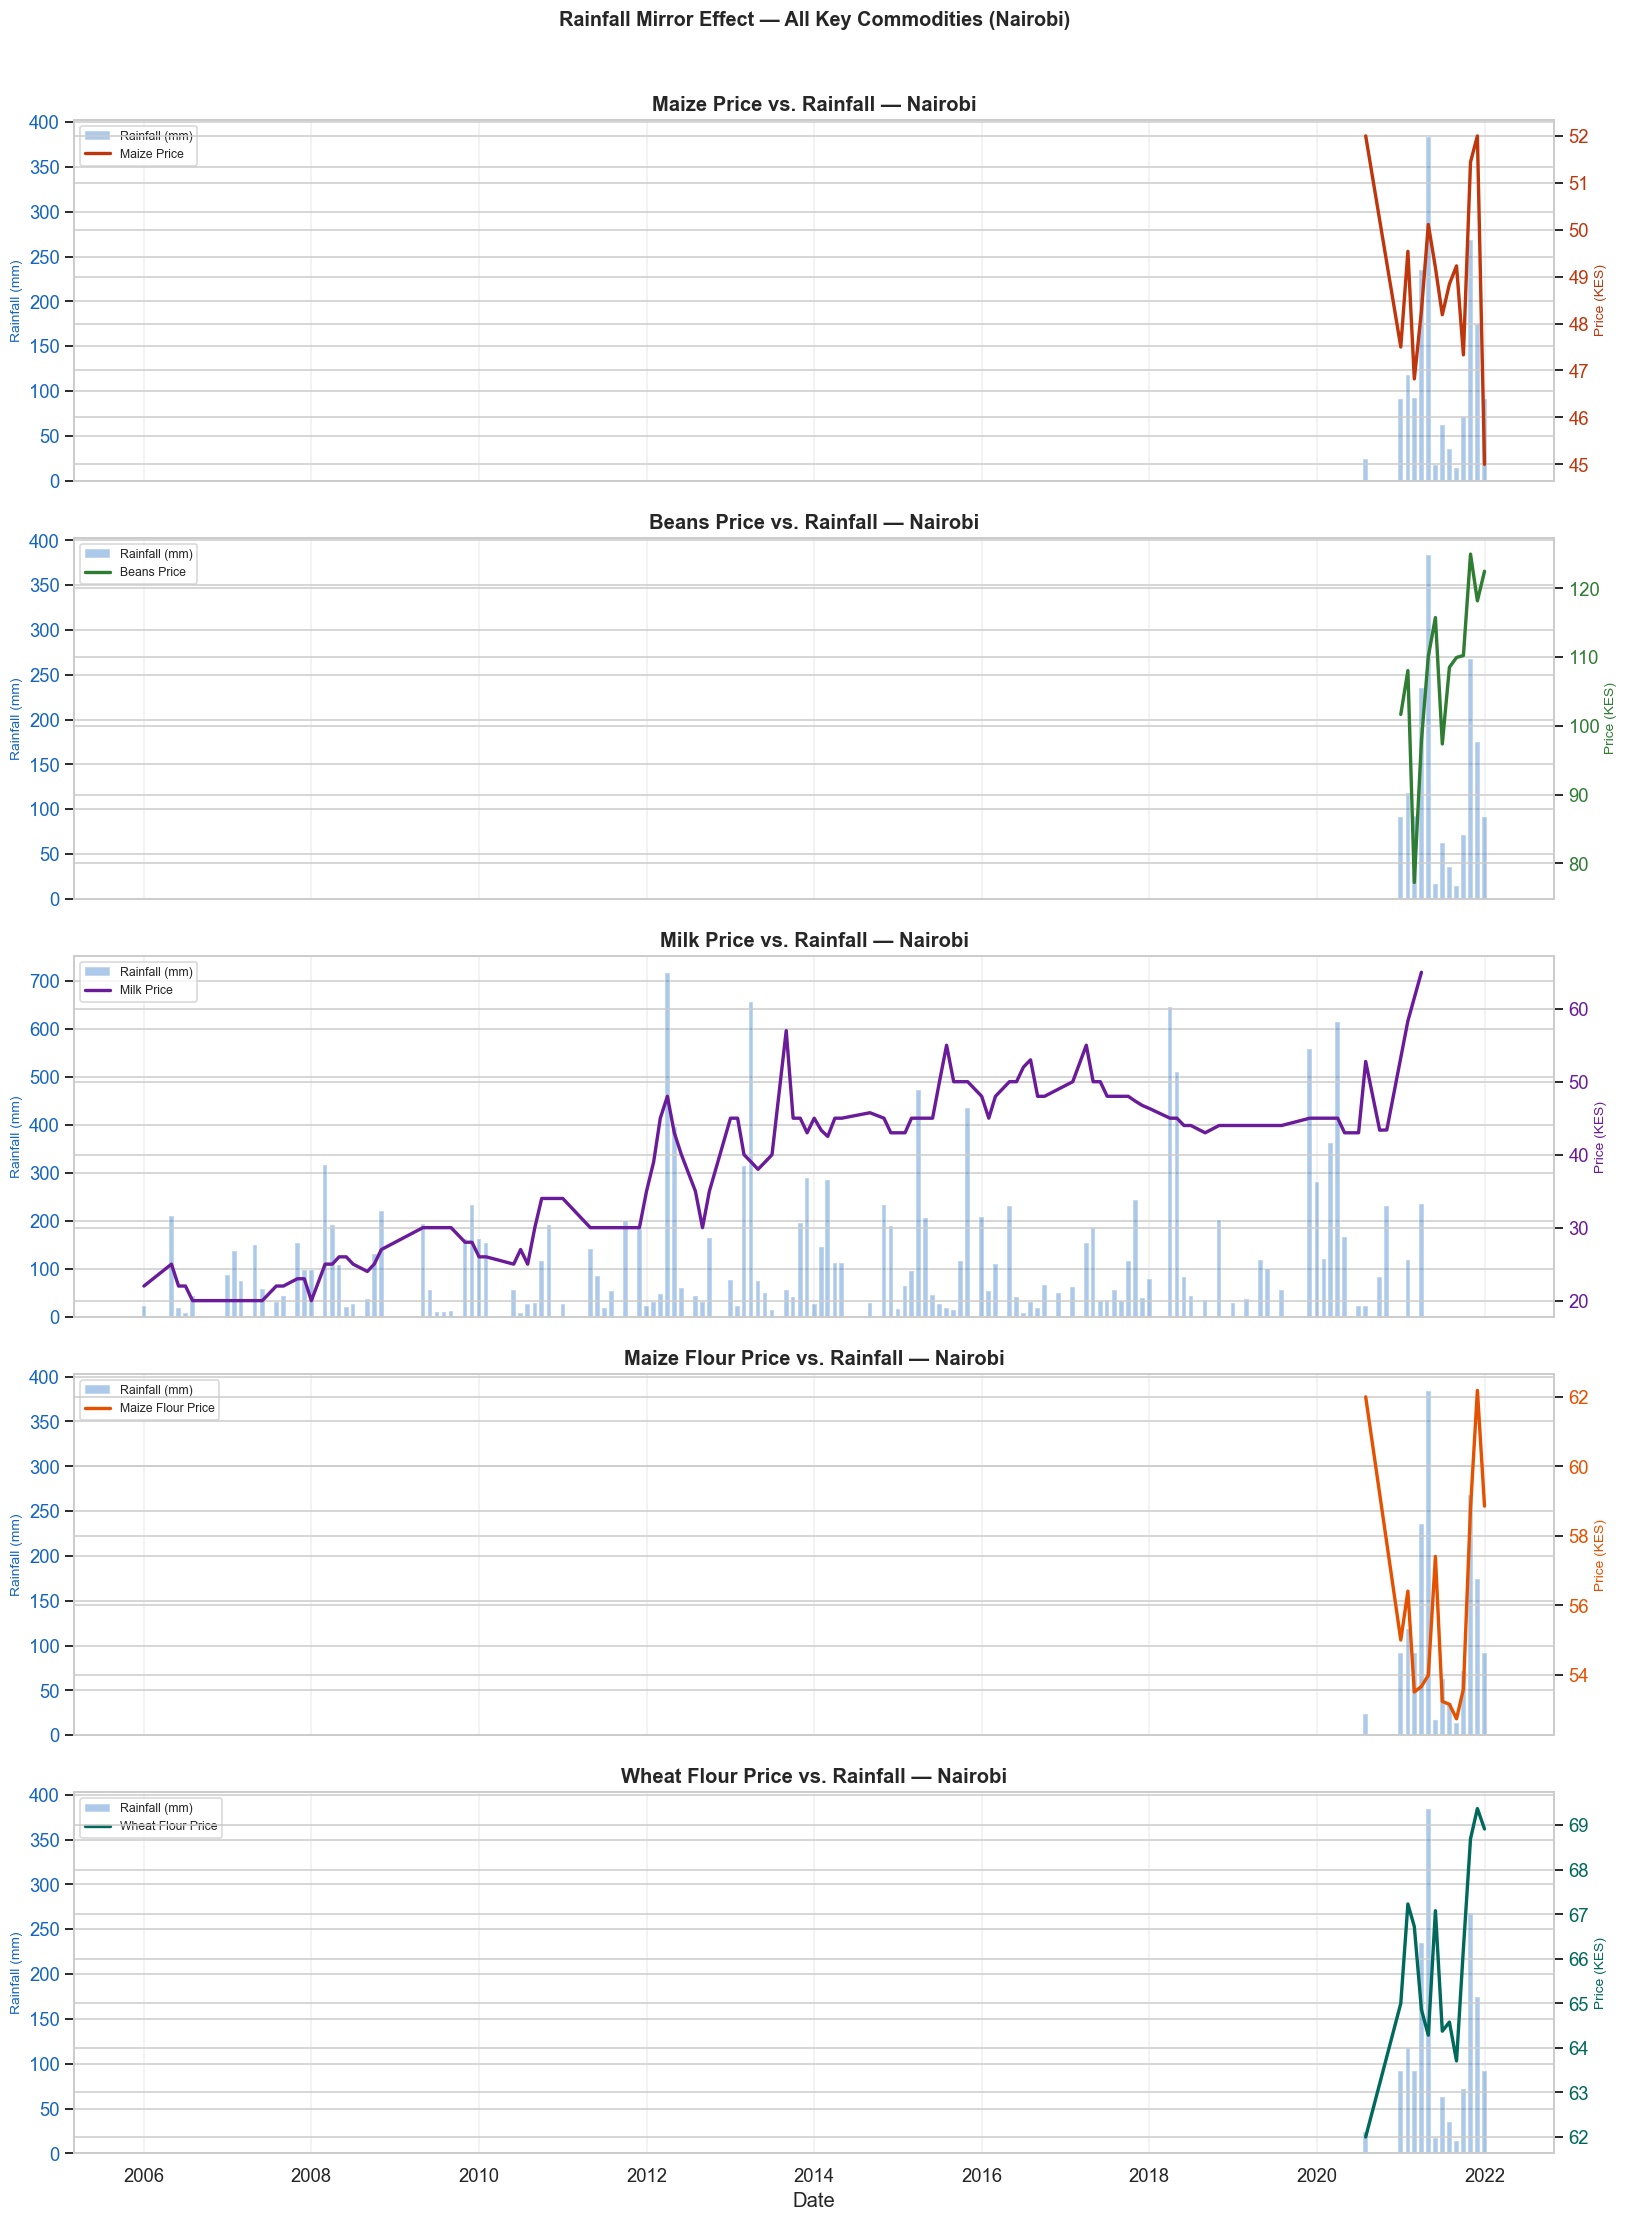

In [19]:
# Rainfall mirror effect for ALL key commodities — Nairobi
focus_county = 'Nairobi'
color_rain   = '#1565C0'
color_palette = ['#BF360C','#2E7D32','#6A1B9A','#E65100','#00695C']

n_c = len(KEY_COMM_LIST)
fig, axes = plt.subplots(n_c, 1, figsize=(15, 4 * n_c), sharex=True)
if n_c == 1:
    axes = [axes]

for ax, commodity, col in zip(axes, KEY_COMM_LIST, color_palette):
    subset = df[
        (df['county'] == focus_county) &
        (df['commodity'] == commodity)
    ].dropna(subset=['price', 'rainfall_mm'])

    if subset.empty:
        ax.set_title(f'{commodity} — No data for {focus_county}')
        continue

    ax_r = ax.twinx()
    ax.bar(subset['date_month'], subset['rainfall_mm'],
           color=color_rain, alpha=0.35, label='Rainfall (mm)', width=20)
    ax.set_ylabel('Rainfall (mm)', color=color_rain, fontsize=9)
    ax.tick_params(axis='y', labelcolor=color_rain)

    ax_r.plot(subset['date_month'], subset['price'],
              color=col, lw=2.2, label=f'{commodity} Price')
    ax_r.set_ylabel('Price (KES)', color=col, fontsize=9)
    ax_r.tick_params(axis='y', labelcolor=col)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_r.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    ax.set_title(f'{commodity} Price vs. Rainfall — {focus_county}', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.suptitle(f'Rainfall Mirror Effect — All Key Commodities ({focus_county})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5.4. Correlation Heatmap — All Commodities

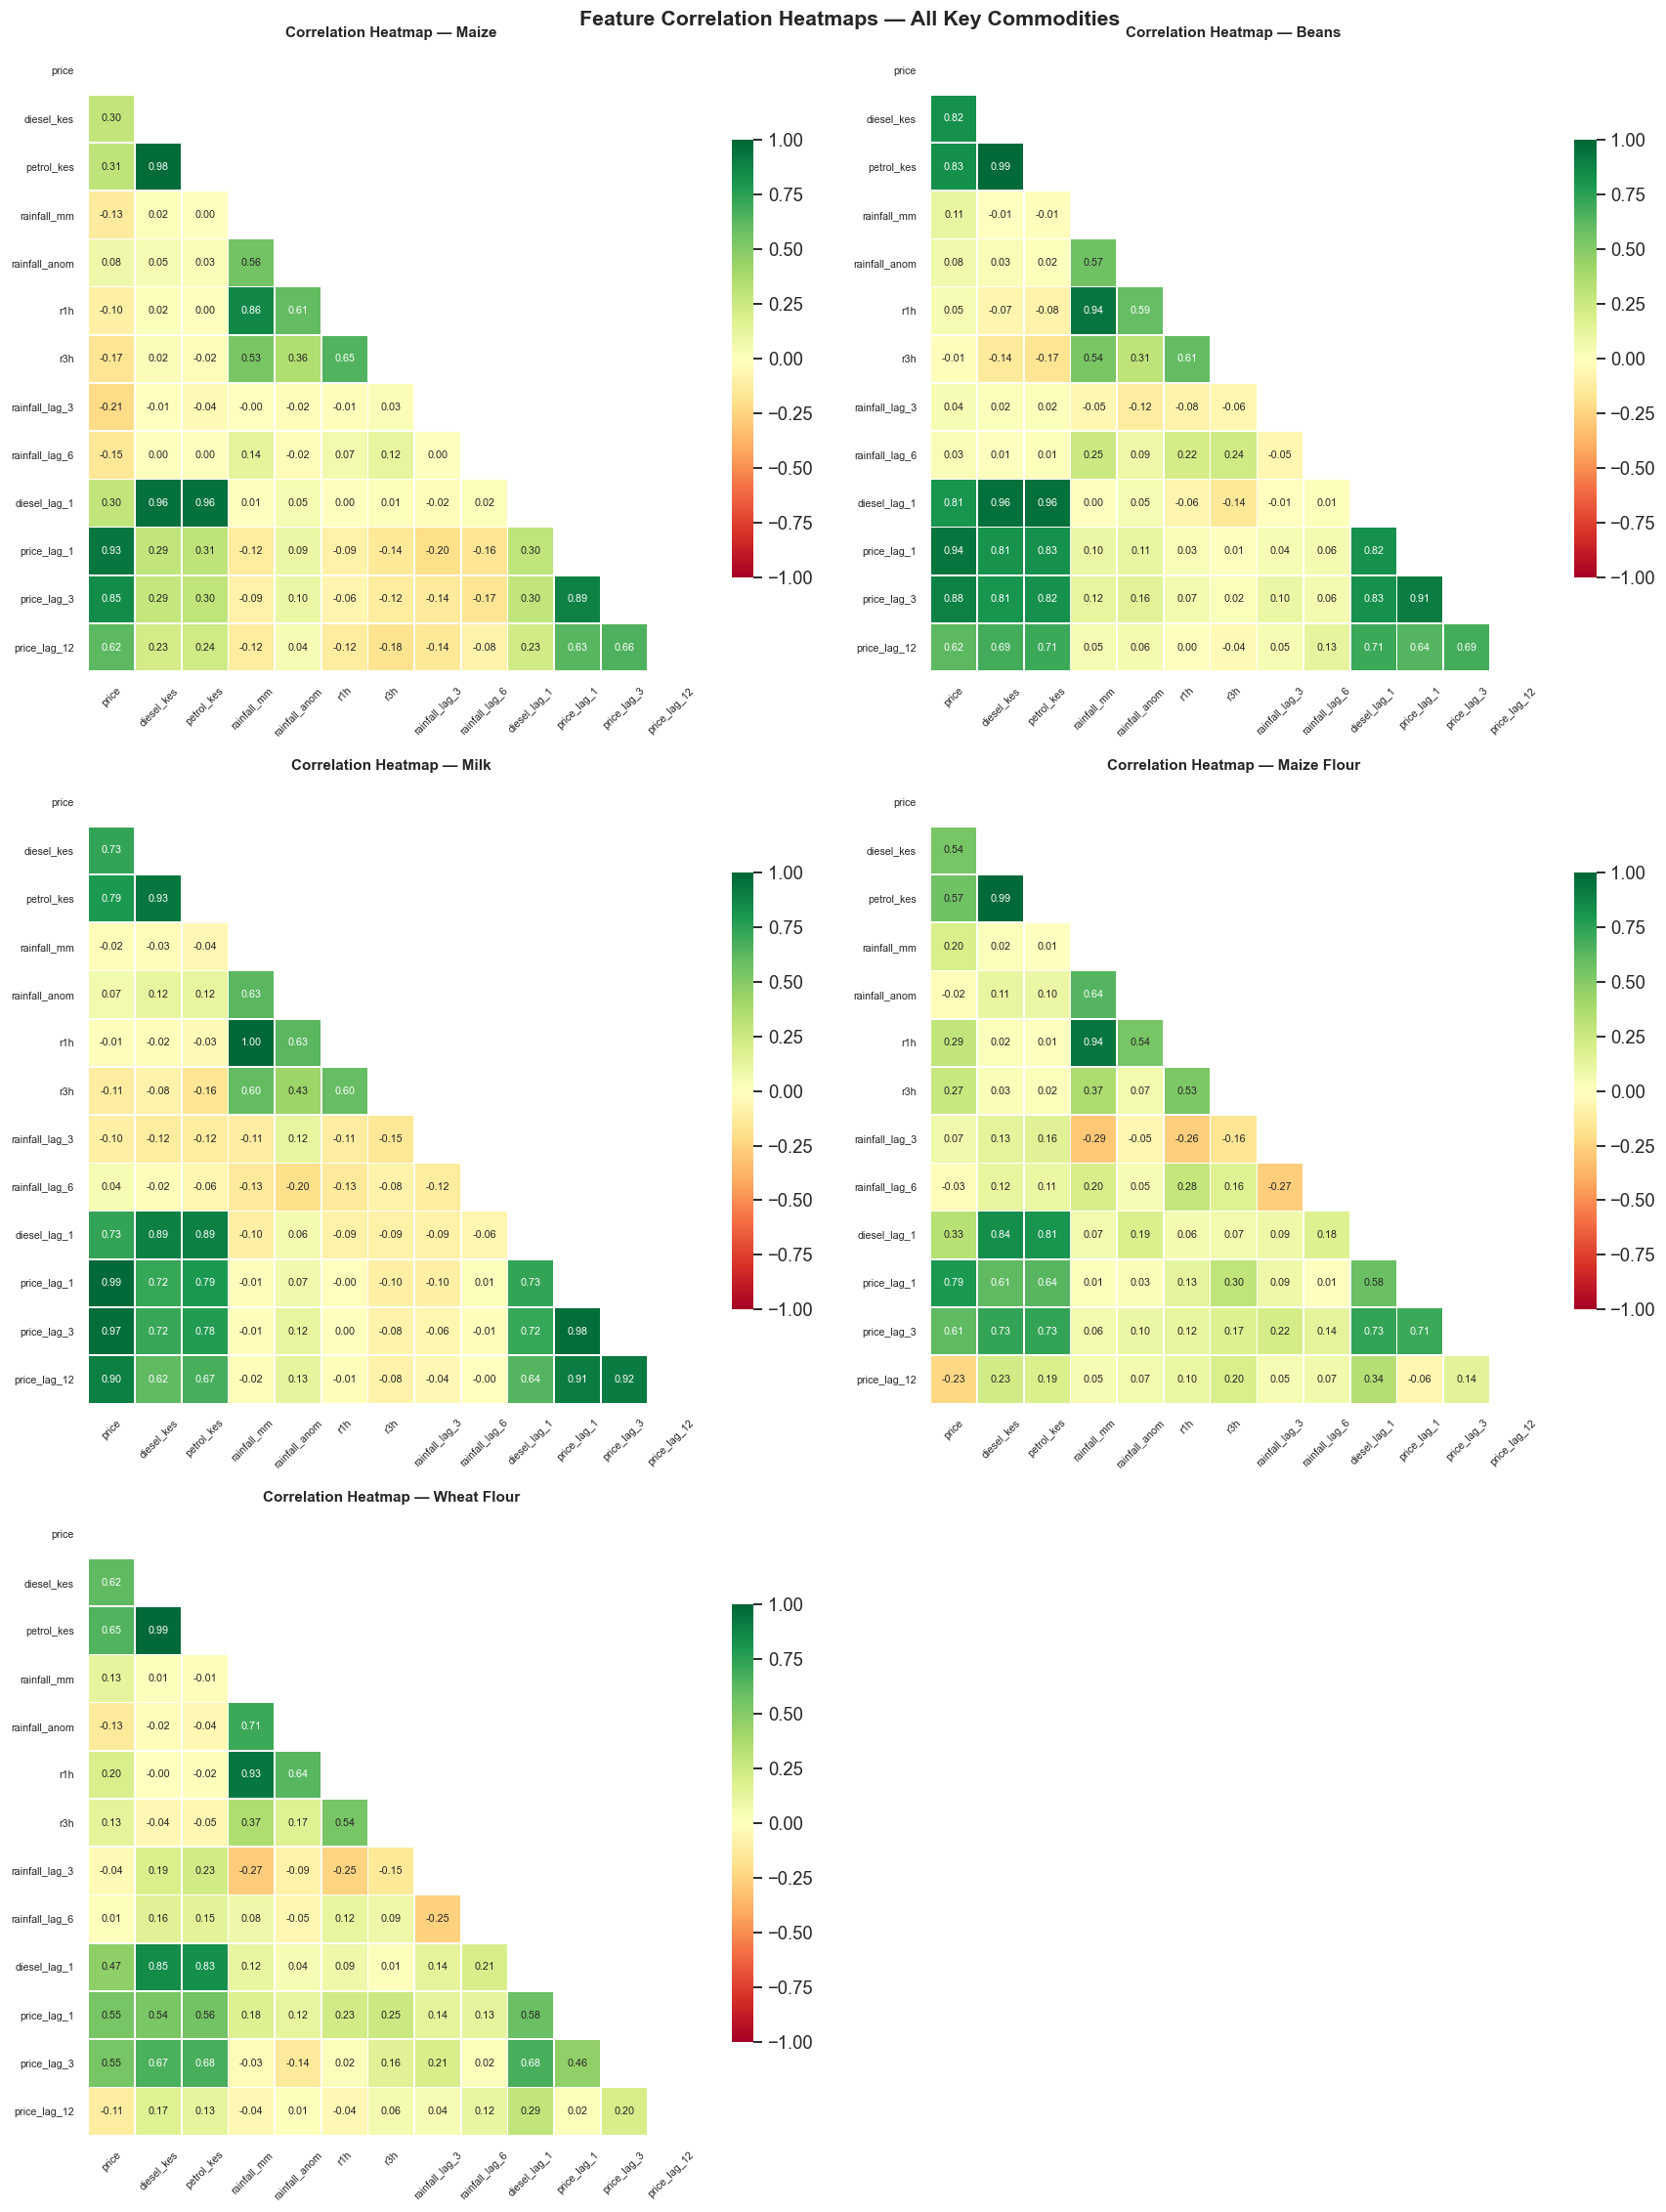


Top Feature Correlations with Price:

  Maize:
    price_lag_1               0.935
    price_lag_3               0.849
    price_lag_12              0.620
    petrol_kes                0.308

  Beans:
    price_lag_1               0.940
    price_lag_3               0.883
    petrol_kes                0.834
    diesel_kes                0.821

  Milk:
    price_lag_1               0.987
    price_lag_3               0.970
    price_lag_12              0.901
    petrol_kes                0.795

  Maize Flour:
    price_lag_1               0.794
    price_lag_3               0.611
    petrol_kes                0.570
    diesel_kes                0.541

  Wheat Flour:
    petrol_kes                0.649
    diesel_kes                0.615
    price_lag_1               0.546
    price_lag_3               0.545


In [20]:
# Correlation heatmaps for each key commodity
corr_cols = [
    'price', 'diesel_kes', 'petrol_kes',
    'rainfall_mm', 'rainfall_anom', 'r1h', 'r3h',
    'rainfall_lag_3', 'rainfall_lag_6',
    'diesel_lag_1', 'price_lag_1', 'price_lag_3', 'price_lag_12'
]

n_c = len(KEY_COMM_LIST)
cols_grid = 2
rows_grid = (n_c + 1) // 2
fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, 7 * rows_grid))
axes = axes.flatten()

for i, commodity in enumerate(KEY_COMM_LIST):
    sub = df[df['commodity'] == commodity][corr_cols].dropna()
    if sub.empty or len(sub) < 5:
        axes[i].set_title(f'{commodity} — Insufficient data')
        continue
    corr_m = sub.corr()
    mask   = np.triu(np.ones_like(corr_m, dtype=bool))
    sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, linewidths=0.4,
                ax=axes[i], annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
    axes[i].set_title(f'Correlation Heatmap — {commodity}', fontweight='bold', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

# Hide any unused subplot
for j in range(n_c, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Correlation Heatmaps — All Key Commodities',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with price for each commodity
print('\nTop Feature Correlations with Price:')
print('=' * 65)
for commodity in KEY_COMM_LIST:
    sub = df[df['commodity'] == commodity][corr_cols].dropna()
    if sub.empty:
        continue
    top_corr = sub.corr()['price'].drop('price').abs().sort_values(ascending=False).head(4)
    print(f'\n  {commodity}:')
    for feat, val in top_corr.items():
        print(f'    {feat:<25} {val:.3f}')


## 5.5. Seasonal Price Patterns — All Key Commodities

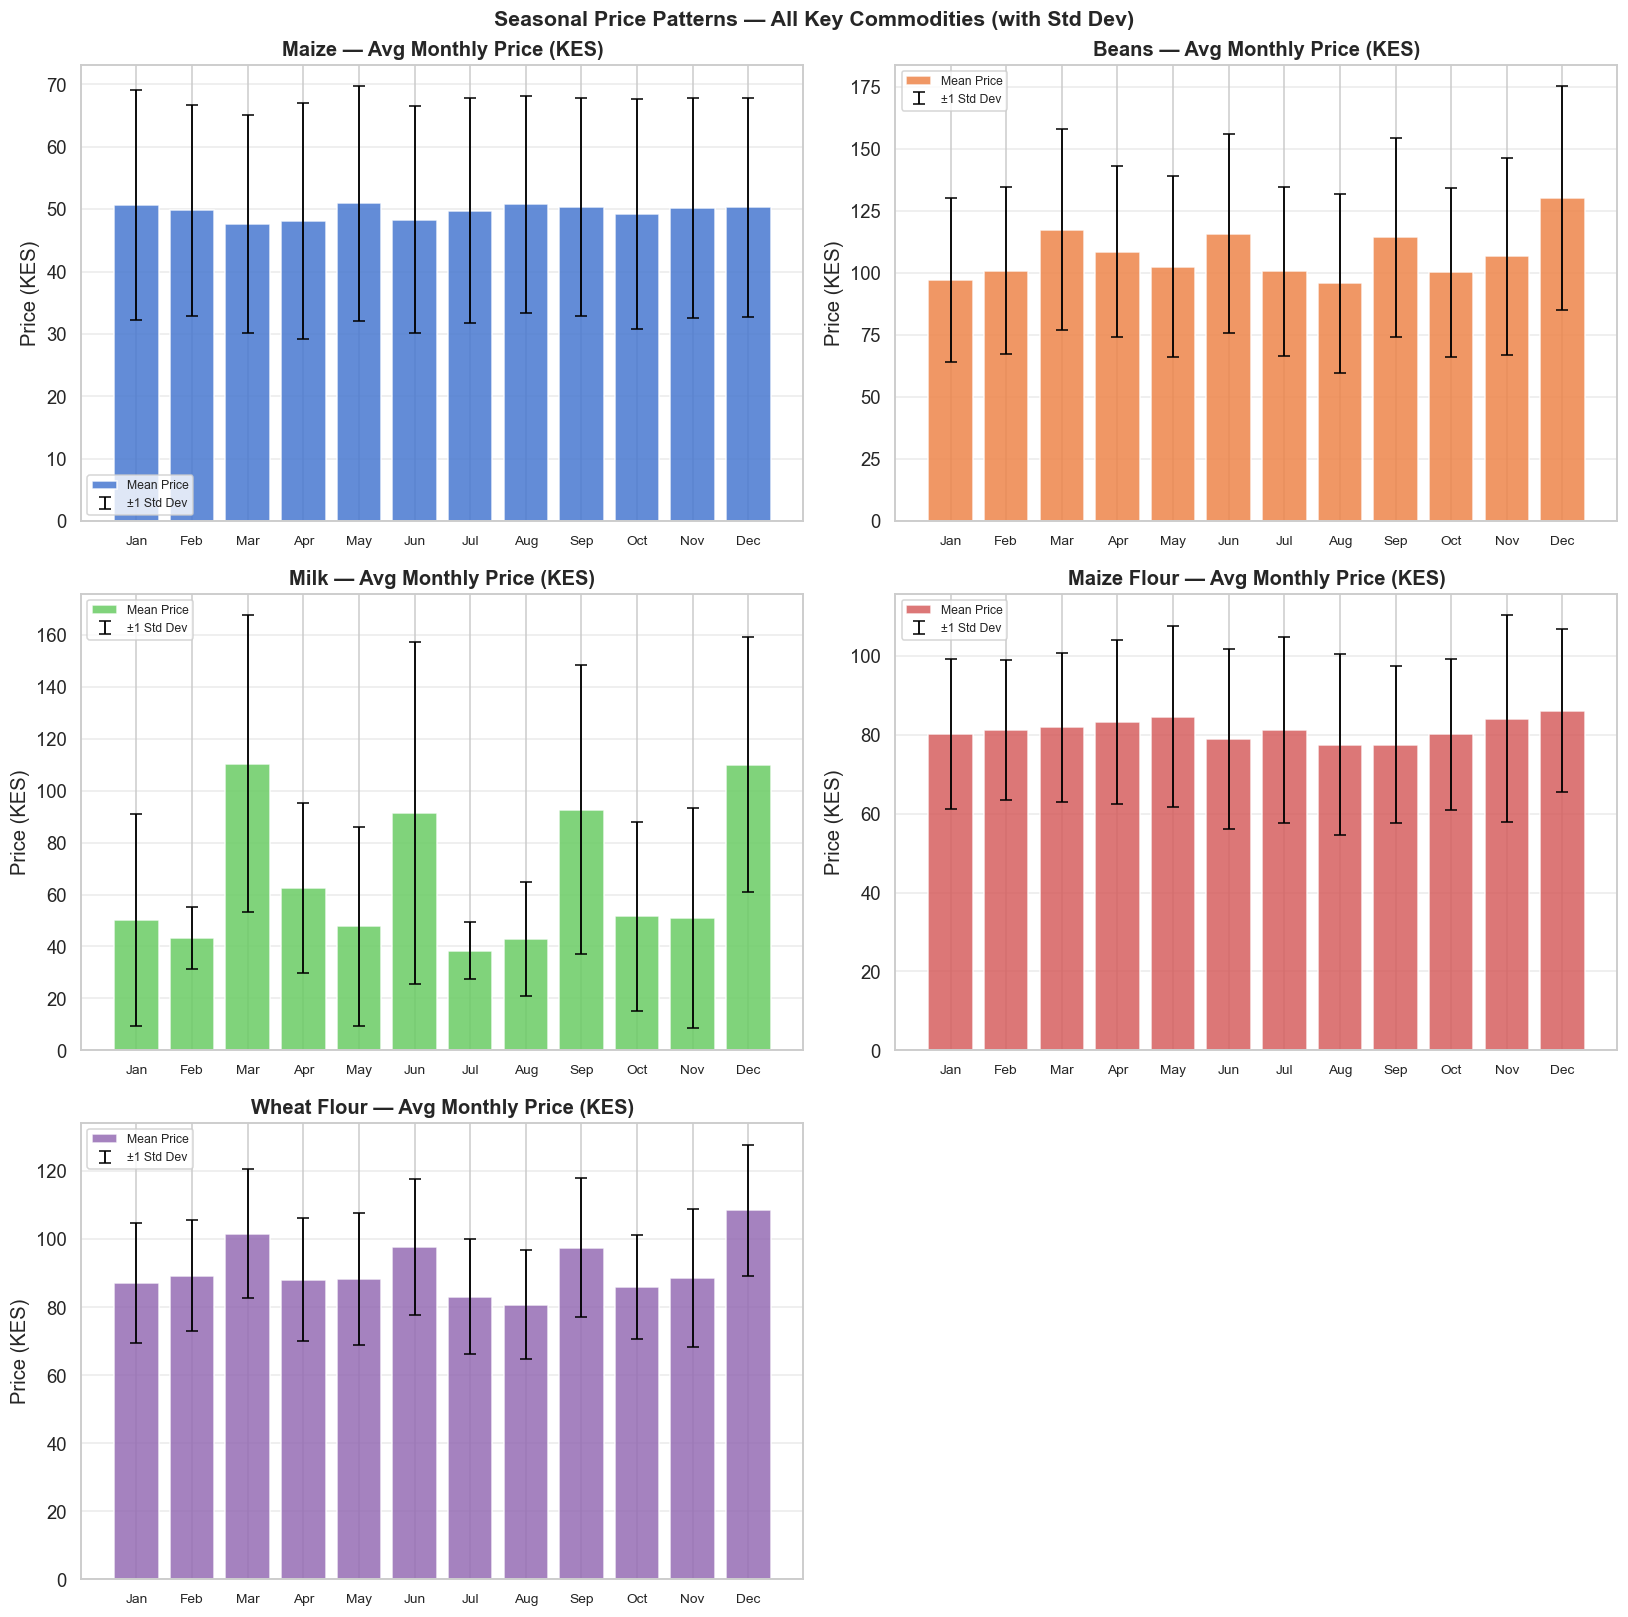

In [21]:
# Monthly seasonality for all key commodities
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

n_c  = len(KEY_COMM_LIST)
cols = 2
rows = (n_c + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

palette = sns.color_palette('muted', n_c)

for i, commodity in enumerate(KEY_COMM_LIST):
    sub = df[df['commodity'] == commodity].copy()
    if sub.empty:
        axes[i].set_title(f'{commodity} — No Data')
        continue
    seasonal = sub.groupby('month')['price'].agg(['mean','std']).reindex(range(1, 13))
    axes[i].bar(seasonal.index, seasonal['mean'],
                color=palette[i], edgecolor='white', alpha=0.85, label='Mean Price')
    axes[i].errorbar(seasonal.index, seasonal['mean'], yerr=seasonal['std'],
                     fmt='none', color='black', capsize=4, lw=1.2, label='±1 Std Dev')
    axes[i].set_title(f'{commodity} — Avg Monthly Price (KES)', fontweight='bold')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_labels, fontsize=9)
    axes[i].set_ylabel('Price (KES)')
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.4)

# Hide unused
for j in range(n_c, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Seasonal Price Patterns — All Key Commodities (with Std Dev)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5.6. County-Level Average Prices — Heatmap

In [22]:
# Pivot: commodity × county mean price
pivot_county = (
    df[df['commodity'].isin(KEY_COMM_LIST)]
    .groupby(['commodity', 'county'])['price']
    .mean()
    .unstack('county')
)

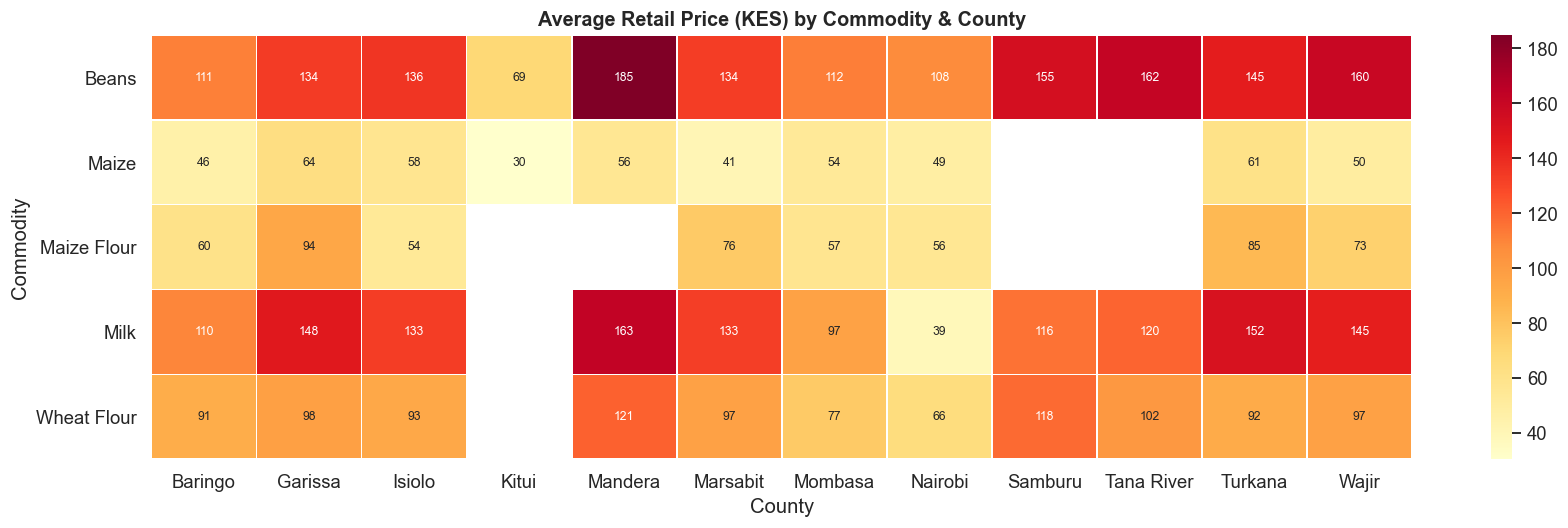

In [23]:
# Keep top 12 counties by data volume
top12 = df.groupby('county')['n_obs'].sum().nlargest(12).index
pivot_county = pivot_county[pivot_county.columns.intersection(top12)]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot_county, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Average Retail Price (KES) by Commodity & County',
             fontsize=13, fontweight='bold')
ax.set_xlabel('County')
ax.set_ylabel('Commodity')
plt.tight_layout()
plt.show()


## 5.7. Year-over-Year Price Change — All Commodities

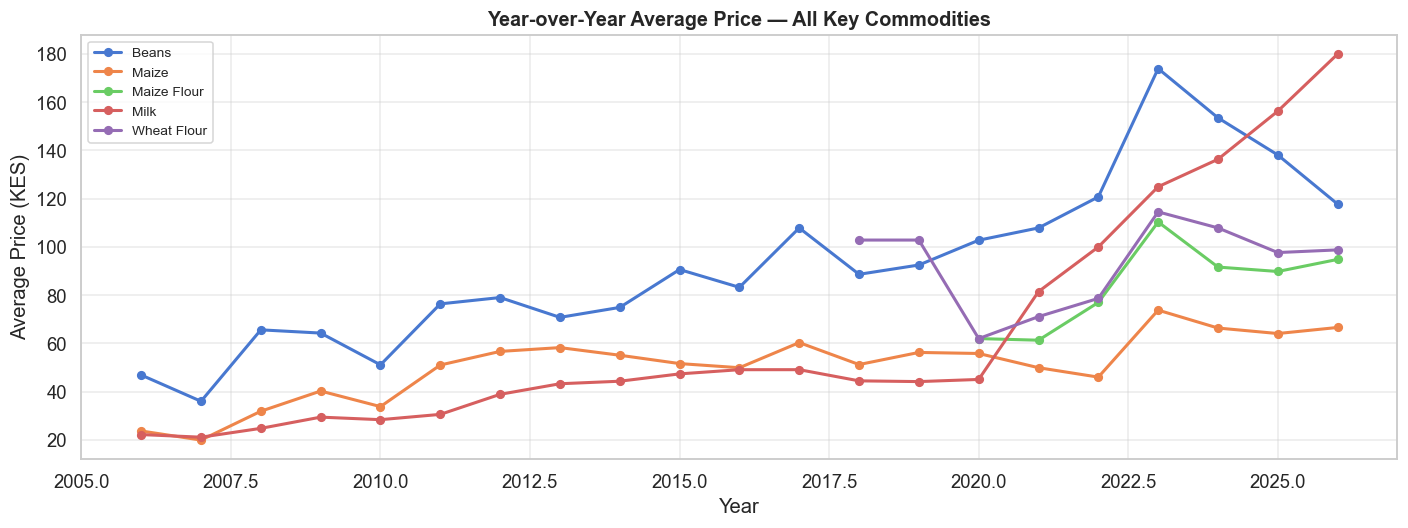

In [24]:
df_key2 = df[df['commodity'].isin(KEY_COMM_LIST)].copy()
yoy = (
    df_key2.groupby(['year', 'commodity'])['price']
    .mean()
    .reset_index()
)
yoy_pivot = yoy.pivot(index='year', columns='commodity', values='price')

fig, ax = plt.subplots(figsize=(13, 5))
for col in yoy_pivot.columns:
    ax.plot(yoy_pivot.index, yoy_pivot[col], marker='o', lw=2, ms=5, label=col)
ax.set_title('Year-over-Year Average Price — All Key Commodities',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Average Price (KES)')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [25]:
# YoY % change table
yoy_pct = yoy_pivot.pct_change() * 100
print('Year-over-Year Price Change (%):')
print(yoy_pct.round(1).to_string())


Year-over-Year Price Change (%):
commodity  Beans  Maize  Maize Flour  Milk  Wheat Flour
year                                                   
2006         NaN    NaN          NaN   NaN          NaN
2007       -23.2  -15.9          NaN  -4.9          NaN
2008        82.3   60.0          NaN  17.4          NaN
2009        -2.0   26.3          NaN  18.8          NaN
2010       -20.5  -16.1          NaN  -3.6          NaN
2011        49.5   51.0          NaN   7.7          NaN
2012         3.4   11.1          NaN  27.2          NaN
2013       -10.4    2.8          NaN  11.3          NaN
2014         5.8   -5.4          NaN   2.4          NaN
2015        21.0   -6.3          NaN   6.9          NaN
2016        -8.1   -3.3          NaN   3.7          NaN
2017        29.6   20.9          NaN   0.0          NaN
2018       -17.8  -15.1          NaN  -9.4          NaN
2019         4.3    9.8          NaN  -0.7          0.0
2020        11.1   -0.8          NaN   2.0        -39.7
2021         5.

## 5.8. Fuel Cost vs Price Scatter — All Commodities

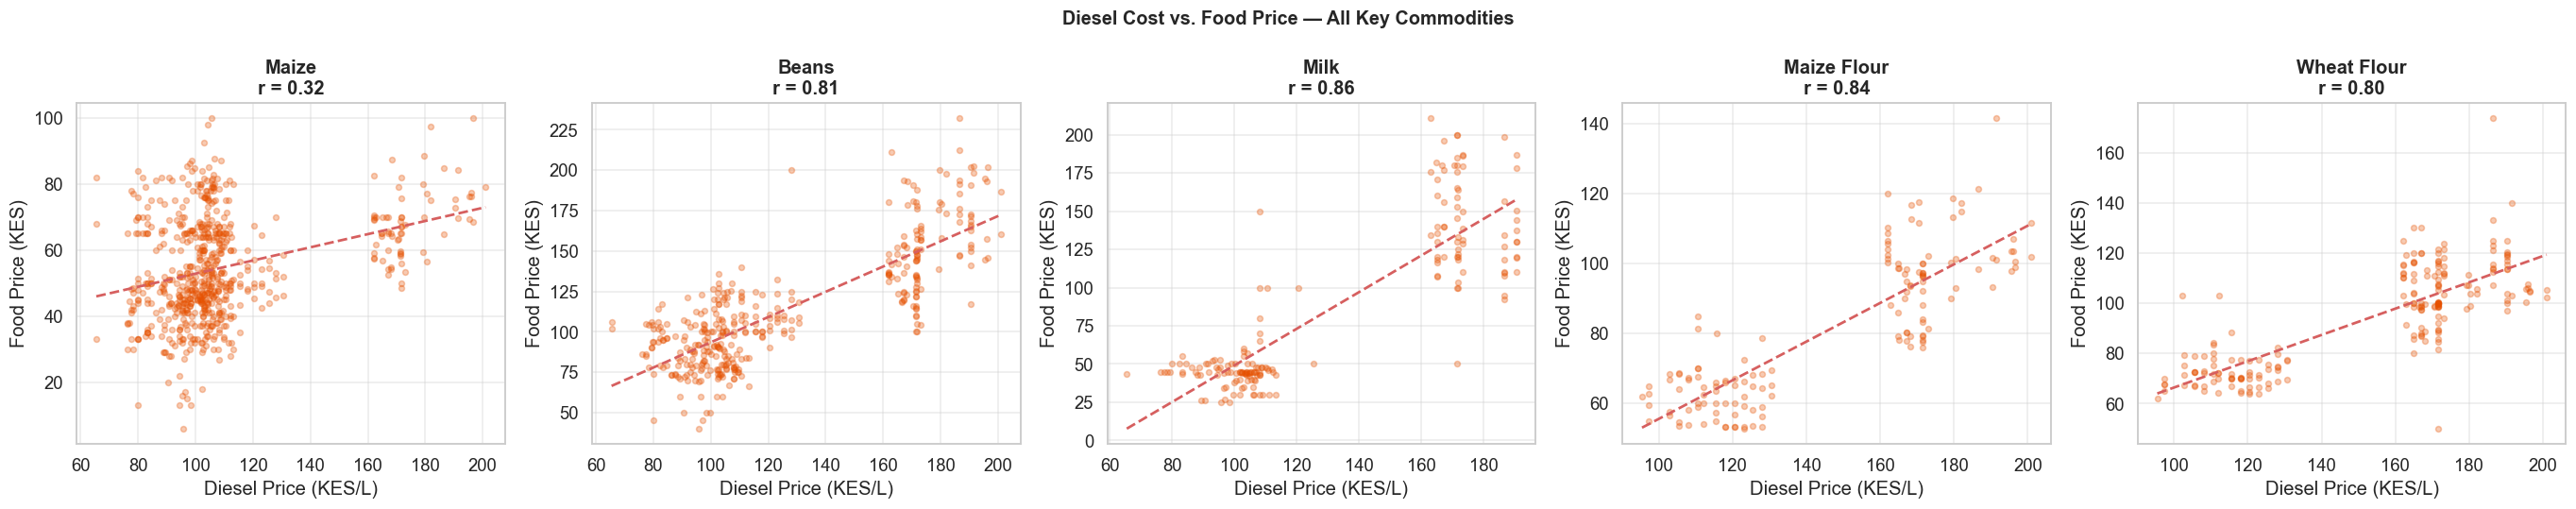

In [26]:
fig, axes = plt.subplots(1, len(KEY_COMM_LIST), figsize=(5 * len(KEY_COMM_LIST), 5))
if len(KEY_COMM_LIST) == 1:
    axes = [axes]

for ax, commodity in zip(axes, KEY_COMM_LIST):
    sub = df[df['commodity'] == commodity].dropna(subset=['diesel_kes', 'price'])
    if sub.empty:
        ax.set_title(f'{commodity}\nNo data')
        continue
    ax.scatter(sub['diesel_kes'], sub['price'], alpha=0.3, s=15, color='#E65100')
    # Trend line
    z = np.polyfit(sub['diesel_kes'], sub['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub['diesel_kes'].min(), sub['diesel_kes'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', lw=1.8)
    corr = sub[['diesel_kes', 'price']].corr().iloc[0, 1]
    ax.set_title(f'{commodity}\nr = {corr:.2f}', fontweight='bold')
    ax.set_xlabel('Diesel Price (KES/L)')
    ax.set_ylabel('Food Price (KES)')
    ax.grid(alpha=0.4)

plt.suptitle('Diesel Cost vs. Food Price — All Key Commodities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.9 Key Patterns Observed

In [27]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KEY EDA FINDINGS — ALL COMMODITIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Fuel-Driven Inflation  : All commodities show positive correlation with
                           diesel prices — transport costs affect every staple.
• Rainfall Mirror Effect : Price spikes follow dry periods (3–6 month lag)
                           most visibly in Maize and Beans.
• Seasonality            : Maize peaks Jan–Feb (pre-harvest lean season);
                           Milk is relatively stable year-round.
• County Variance        : Remote/arid counties (e.g. Turkana, Mandera)
                           consistently show higher prices than Nairobi.
• Autoregression         : price_lag_1 and price_lag_3 are the strongest
                           predictors across all commodities.
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KEY EDA FINDINGS — ALL COMMODITIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Fuel-Driven Inflation  : All commodities show positive correlation with
                           diesel prices — transport costs affect every staple.
• Rainfall Mirror Effect : Price spikes follow dry periods (3–6 month lag)
                           most visibly in Maize and Beans.
• Seasonality            : Maize peaks Jan–Feb (pre-harvest lean season);
                           Milk is relatively stable year-round.
• County Variance        : Remote/arid counties (e.g. Turkana, Mandera)
                           consistently show higher prices than Nairobi.
• Autoregression         : price_lag_1 and price_lag_3 are the strongest
                           predictors across all commodities.



---
## 6. Modelling

### 6.1. Model Data Preparation

In [28]:
# Feature list for modelling
# Base numeric features (no categorical columns yet — OHE adds them below)
NUMERIC_FEATURE_COLS = [
    # Time features
    'year', 'month_sin', 'month_cos',
    # Rainfall features (lagged — delay in impact)
    'rainfall_lag_1', 'rainfall_lag_3', 'rainfall_lag_6',
    'rainfall_anom_lag_1', 'rainfall_anom_lag_3',
    # Fuel features (lagged)
    'diesel_lag_1', 'diesel_lag_2',
    # Autoregressive price features
    'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12',
    'price_rolling_3',
]

TARGET = 'price'

# ── One-Hot Encode categoricals ──────────────────────────────────────────────
ohe_county    = OneHotEncoder(sparse=False, handle_unknown='ignore')
ohe_commodity = OneHotEncoder(sparse=False, handle_unknown='ignore')

# Drop rows with NaN in target or key lag features first
df_model = df.dropna(subset=[TARGET, 'price_lag_1', 'price_lag_3', 'diesel_lag_1']).copy()

# Fit and transform county
county_encoded    = ohe_county.fit_transform(df_model[['county']])
county_cols       = [f'county_{c}' for c in ohe_county.categories_[0]]

# Fit and transform commodity
commodity_encoded = ohe_commodity.fit_transform(df_model[['commodity']])
commodity_cols    = [f'commodity_{c}' for c in ohe_commodity.categories_[0]]

# Build combined feature DataFrame
X_numeric = df_model[NUMERIC_FEATURE_COLS].copy()
X_county_df    = pd.DataFrame(county_encoded,    columns=county_cols,    index=df_model.index)
X_commodity_df = pd.DataFrame(commodity_encoded, columns=commodity_cols, index=df_model.index)

X_full = pd.concat([X_numeric, X_county_df, X_commodity_df], axis=1)
display(X_full.head(10))

# Final FEATURE_COLS list (used downstream for feature importance labels)
FEATURE_COLS = list(X_full.columns)

y = df_model[TARGET]

# Impute any remaining NaNs with column median (numeric cols only; OHE cols are complete)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_full)

print(f'Modelling dataset: {X_imp.shape[0]:,} rows × {X_imp.shape[1]} features')
print(f'  — Numeric features : {len(NUMERIC_FEATURE_COLS)}')
print(f'  — County OHE cols  : {len(county_cols)}')
print(f'  — Commodity OHE cols: {len(commodity_cols)}')
print(f'Target: price — mean={y.mean():.1f} KES, std={y.std():.1f} KES')


,year,month_sin,month_cos,rainfall_lag_1,rainfall_lag_3,rainfall_lag_6,rainfall_anom_lag_1,rainfall_anom_lag_3,diesel_lag_1,diesel_lag_2,...,county_Nairobi,county_Samburu,county_Tana River,county_Turkana,county_Wajir,commodity_Beans,commodity_Maize,commodity_Maize Flour,commodity_Milk,commodity_Wheat Flour
3,2015,-1.000000e+00,-1.836970e-16,162.689712,355.388512,NaN,68.364258,130.023144,84.56,79.34,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2015,-8.660254e-01,5.000000e-01,84.582010,231.050622,NaN,74.142230,86.049173,79.99,84.56,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,2015,-5.000000e-01,8.660254e-01,162.073538,162.689712,NaN,97.505043,68.364258,82.43,79.99,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,2016,8.660254e-01,5.000000e-01,237.050959,84.582010,355.388512,136.334862,74.142230,98.90,82.43,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,2016,5.000000e-01,-8.660254e-01,29.445742,162.073538,231.050622,66.414904,97.505043,87.50,98.90,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,2016,1.224647e-16,-1.000000e+00,395.303629,237.050959,162.689712,134.997315,136.334862,90.80,87.50,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,2016,-5.000000e-01,-8.660254e-01,169.198997,29.445742,84.582010,96.210349,66.414904,91.50,90.80,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10,2016,-5.000000e-01,8.660254e-01,260.742925,395.303629,162.073538,106.320991,134.997315,92.80,91.50,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
11,2017,1.000000e+00,6.123234e-17,125.489716,169.198997,237.050959,77.750223,96.210349,96.70,92.80,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12,2017,8.660254e-01,-5.000000e-01,66.291196,260.742925,29.445742,49.686126,106.320991,101.20,96.70,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Modelling dataset: 1,353 rows × 35 features
  — Numeric features : 15
  — County OHE cols  : 15
  — Commodity OHE cols: 5
Target: price — mean=78.1 KES, std=36.6 KES


Temporal train/test split

In [29]:
# train/test split
# Use data before 2024 for training, 2024+ for testing
split_date = pd.Timestamp('2024-01-01')
train_mask = df_model['date_month'] < split_date
test_mask  = df_model['date_month'] >= split_date

X_train, X_test = X_imp[train_mask], X_imp[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'Training set:  {X_train.shape[0]:,} rows  ({df_model[train_mask]["date_month"].min().date()} → {df_model[train_mask]["date_month"].max().date()})')
print(f'Test set:      {X_test.shape[0]:,} rows  ({df_model[test_mask]["date_month"].min().date()} → {df_model[test_mask]["date_month"].max().date()})')

Training set:  1,059 rows  (2010-02-01 → 2023-12-01)
Test set:      294 rows  (2024-01-01 → 2026-03-01)


### 6.2. Baseline — Linear Regression

In [30]:
#  Baseline: Linear Regression 
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('━' * 45)
print(' BASELINE: Linear Regression')
print('━' * 45)
print(f'  MAE  : {mae_lr:.2f} KES')
print(f'  RMSE : {rmse_lr:.2f} KES')
print(f'  R²   : {r2_lr:.4f}')
print('━' * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 BASELINE: Linear Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 12.81 KES
  RMSE : 18.31 KES
  R²   : 0.7459
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 6.3. Random Forest Regressor

In [31]:
# Random Forest 
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('━' * 45)
print(' Random Forest Regressor')
print('━' * 45)
print(f'  MAE  : {mae_rf:.2f} KES')
print(f'  RMSE : {rmse_rf:.2f} KES')
print(f'  R²   : {r2_rf:.4f}')
print('━' * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Random Forest Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 17.72 KES
  RMSE : 25.18 KES
  R²   : 0.5196
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 6.4. Gradient Boosting Regressor (XGBoost-equivalent)

In [32]:
# Gradient Boosting (mirrors XGBoost logic) 
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=5,
    min_samples_leaf=4,
    subsample=0.85,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)

print('━' * 45)
print('🚀 Gradient Boosting Regressor')
print('━' * 45)
print(f'  MAE  : {mae_gbr:.2f} KES')
print(f'  RMSE : {rmse_gbr:.2f} KES')
print(f'  R²   : {r2_gbr:.4f}')
print('━' * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚀 Gradient Boosting Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 19.11 KES
  RMSE : 26.39 KES
  R²   : 0.4723
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
#  7. Models Evaluation

## 7.1 . Model Comparison Summary

In [33]:
# Side-by-side comparison 
results = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'Random Forest', 'Gradient Boosting'],
    'MAE (KES)':  [mae_lr,  mae_rf,  mae_gbr],
    'RMSE (KES)': [rmse_lr, rmse_rf, rmse_gbr],
    'R²':         [r2_lr,   r2_rf,   r2_gbr]
})

print(' MODEL PERFORMANCE SUMMARY')
print('=' * 60)
print(results.to_string(index=False, float_format='{:.2f}'.format))
print('=' * 60)

best_model = results.loc[results['MAE (KES)'].idxmin(), 'Model']
print(f' Best Model (lowest MAE): {best_model}')

 MODEL PERFORMANCE SUMMARY
                        Model  MAE (KES)  RMSE (KES)   R²
 Linear Regression (Baseline)      12.81       18.31 0.75
                Random Forest      17.72       25.18 0.52
            Gradient Boosting      19.11       26.39 0.47
 Best Model (lowest MAE): Linear Regression (Baseline)


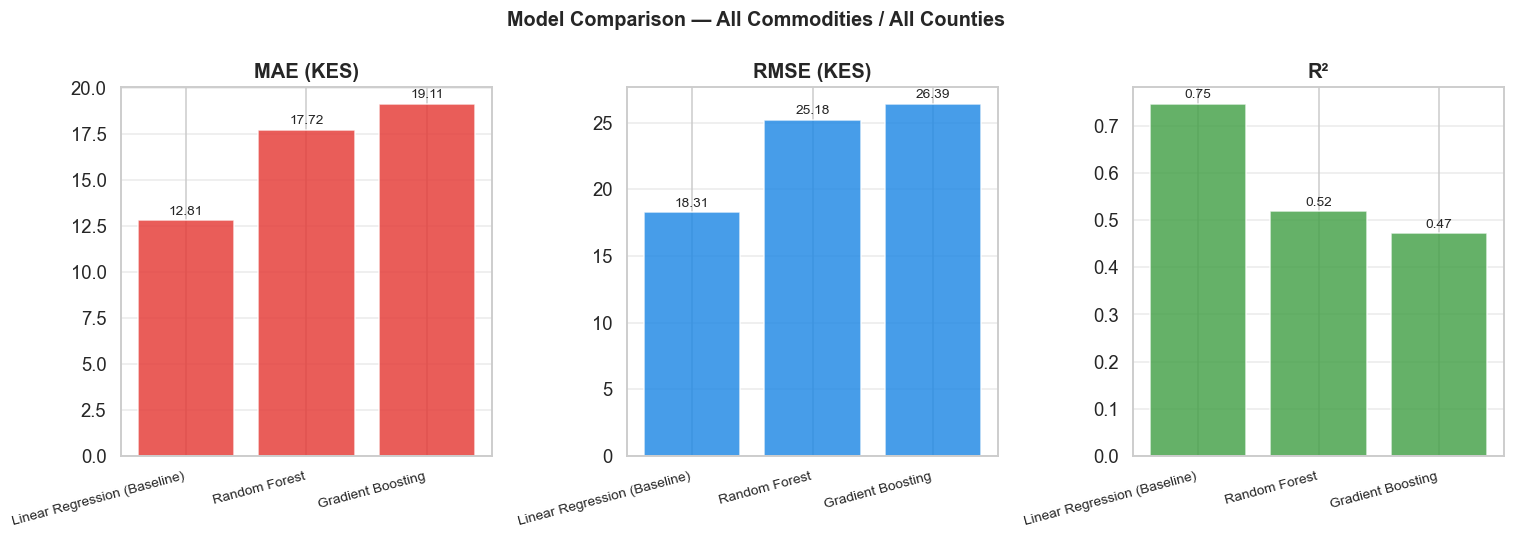

In [34]:
# Bar chart comparison 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE (KES)', 'RMSE (KES)', 'R²']
colors  = ['#E53935', '#1E88E5', '#43A047']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results['Model'], results[metric], color=color, alpha=0.82, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticklabels(results['Model'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Model Comparison — All Commodities / All Counties', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7.2. K-Fold Cross-Validation (Best Model)

In [35]:
# K-Fold CV on best model (GBR) 
kf = KFold(n_splits=5, shuffle=False)   # No shuffle — time-series ordering preserved

cv_mae  = -cross_val_score(gbr, X_imp, y, cv=kf, scoring='neg_mean_absolute_error')
cv_rmse = np.sqrt(-cross_val_score(gbr, X_imp, y, cv=kf, scoring='neg_mean_squared_error'))

print('━' * 50)
print('7-Fold Cross-Validation — Gradient Boosting')
print('━' * 50)
for i, (mae_i, rmse_i) in enumerate(zip(cv_mae, cv_rmse), 1):
    print(f'  Fold {i}:  MAE = {mae_i:7.2f} KES  |  RMSE = {rmse_i:7.2f} KES')
print('━' * 50)
print(f'  Mean:   MAE = {cv_mae.mean():7.2f} KES  |  RMSE = {cv_rmse.mean():7.2f} KES')
print(f'  Std:    MAE = {cv_mae.std():7.2f} KES  |  RMSE = {cv_rmse.std():7.2f} KES')
print('━' * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
7-Fold Cross-Validation — Gradient Boosting
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Fold 1:  MAE =    8.31 KES  |  RMSE =   14.14 KES
  Fold 2:  MAE =    6.78 KES  |  RMSE =   10.22 KES
  Fold 3:  MAE =    5.60 KES  |  RMSE =    9.26 KES
  Fold 4:  MAE =    8.13 KES  |  RMSE =   11.13 KES
  Fold 5:  MAE =    7.35 KES  |  RMSE =   11.51 KES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean:   MAE =    7.23 KES  |  RMSE =   11.25 KES
  Std:    MAE =    0.98 KES  |  RMSE =    1.64 KES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 7.3. Feature Importance

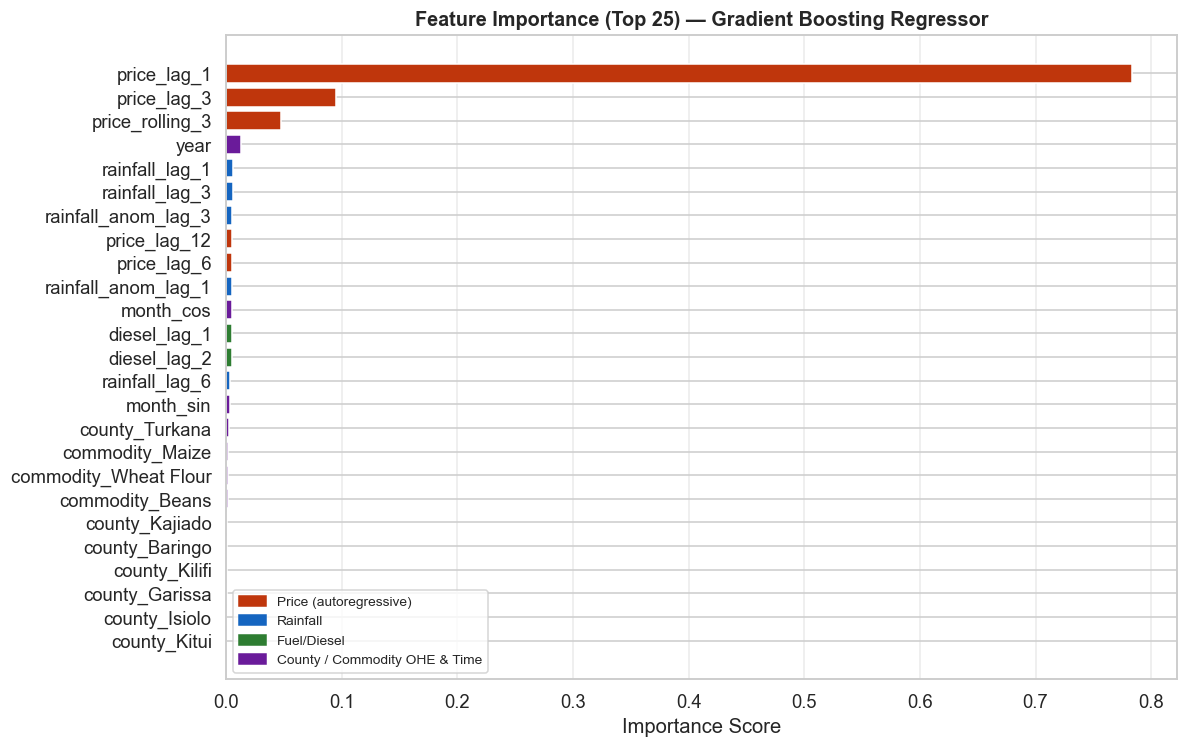

In [36]:
# Feature importance from GBR
feat_imp = pd.Series(gbr.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

# Show top 25 features for readability (OHE can create many columns)
top_n = 25
feat_imp_top = feat_imp.head(top_n)

def get_color(f):
    if 'price' in f:    return '#BF360C'
    if 'rainfall' in f: return '#1565C0'
    if 'diesel' in f:   return '#2E7D32'
    return '#6A1B9A'   # county / commodity OHE cols & time features

colors_fi = [get_color(f) for f in feat_imp_top.index]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(feat_imp_top.index[::-1], feat_imp_top.values[::-1],
        color=colors_fi[::-1], edgecolor='white')
ax.set_title(f'Feature Importance (Top {top_n}) — Gradient Boosting Regressor',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

from matplotlib.patches import Patch
legend = [
    Patch(color='#BF360C', label='Price (autoregressive)'),
    Patch(color='#1565C0', label='Rainfall'),
    Patch(color='#2E7D32', label='Fuel/Diesel'),
    Patch(color='#6A1B9A', label='County / Commodity OHE & Time'),
]
ax.legend(handles=legend, fontsize=9)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()


## 7.4. Predicted vs. Actual — Visual Check

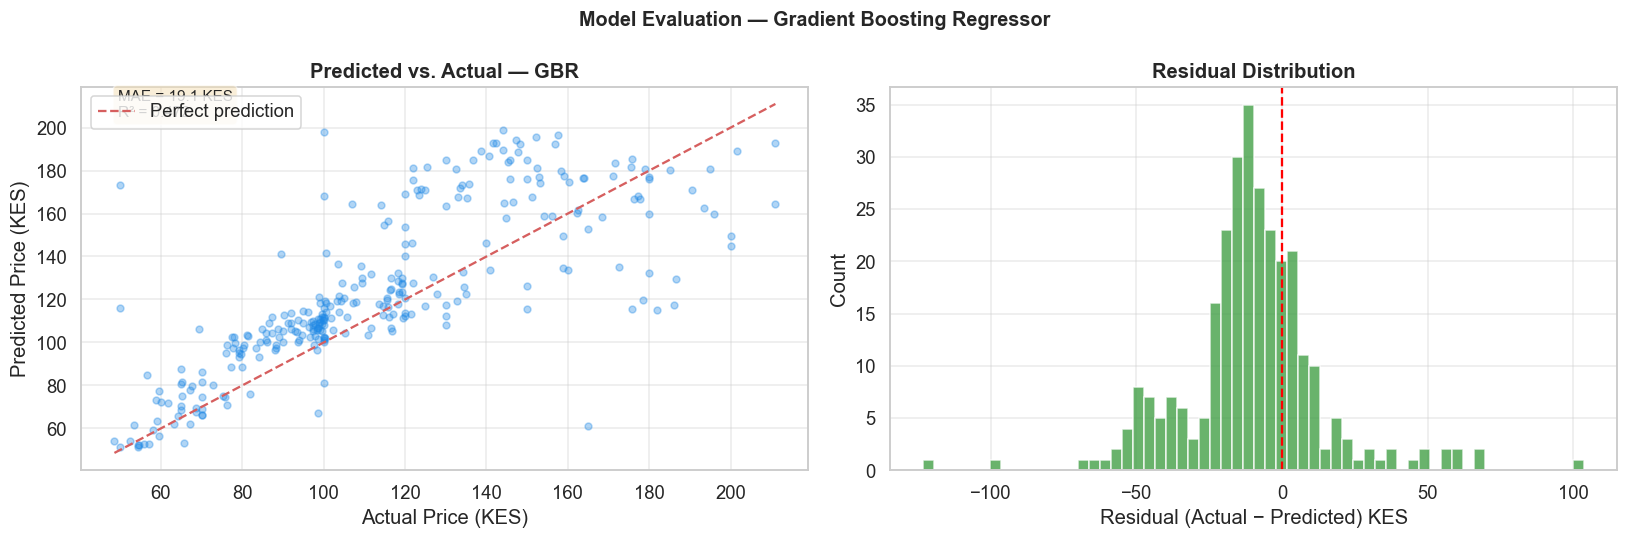

In [37]:
# Predicted vs Actual scatter & time-series 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter
axes[0].scatter(y_test, y_pred_gbr, alpha=0.35, s=20, color='#1E88E5')
lims = [min(y_test.min(), y_pred_gbr.min()), max(y_test.max(), y_pred_gbr.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (KES)')
axes[0].set_ylabel('Predicted Price (KES)')
axes[0].set_title('Predicted vs. Actual — GBR', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.4)
axes[0].text(0.05, 0.92, f'MAE = {mae_gbr:.1f} KES\nR² = {r2_gbr:.3f}',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Residuals
residuals = y_test.values - y_pred_gbr
axes[1].hist(residuals, bins=60, color='#43A047', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, ls='--')
axes[1].set_xlabel('Residual (Actual − Predicted) KES')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].grid(alpha=0.4)

plt.suptitle('Model Evaluation — Gradient Boosting Regressor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

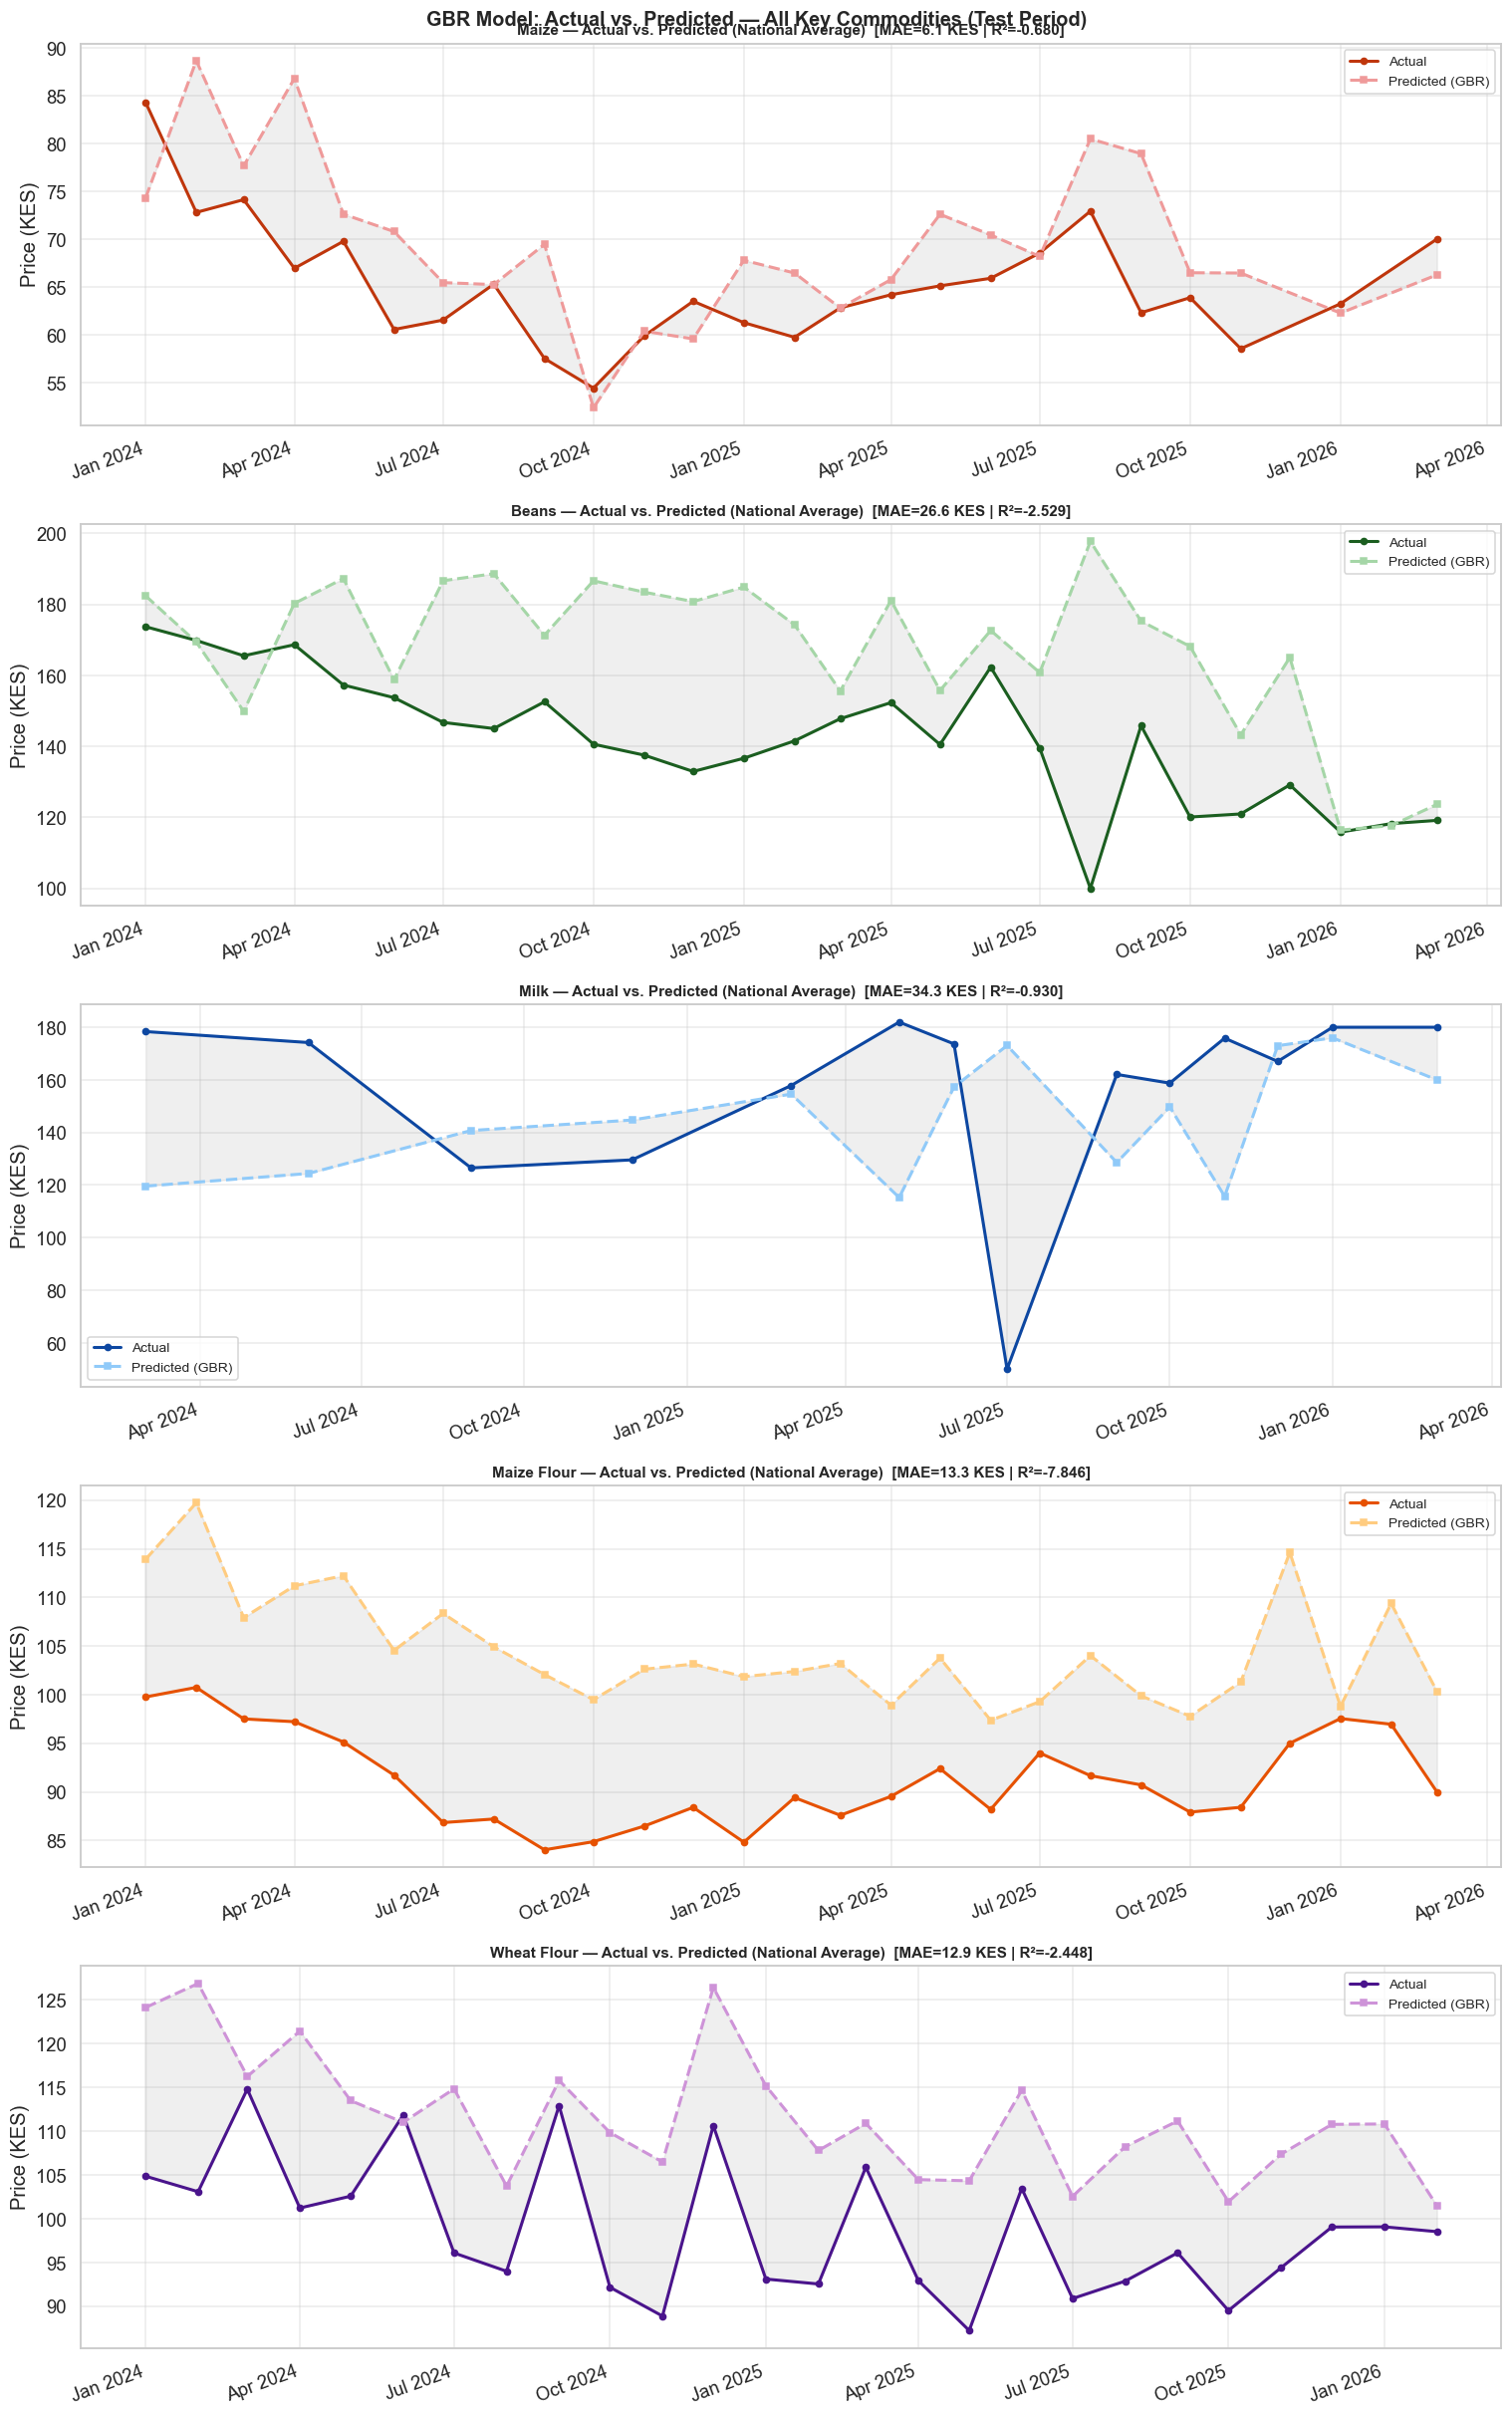

In [38]:
# Actual vs Predicted time-series for ALL key commodities — Nairobi
test_df = df_model[test_mask].copy()
test_df['predicted'] = y_pred_gbr

commodities_in_test = [c for c in KEY_COMM_LIST if c in test_df['commodity'].unique()]
n_c    = len(commodities_in_test)
colors_act  = ['#BF360C','#1B5E20','#0D47A1','#E65100','#4A148C']
colors_pred = ['#EF9A9A','#A5D6A7','#90CAF9','#FFCC80','#CE93D8']

fig, axes = plt.subplots(n_c, 1, figsize=(14, 4.5 * n_c), sharex=False)
if n_c == 1:
    axes = [axes]

for i, (ax, commodity) in enumerate(zip(axes, commodities_in_test)):
    sub = test_df[
        (test_df['commodity'] == commodity) &
        (test_df['county'] == 'Nairobi')
    ].sort_values('date_month')

    if sub.empty:
        # Fall back to national average for that commodity
        sub = test_df[test_df['commodity'] == commodity]                 .groupby('date_month')[['price','predicted']].mean().reset_index()
        title_suffix = '(National Average)'
    else:
        title_suffix = '(Nairobi)'

    ax.plot(sub['date_month'], sub['price'],
            'o-', lw=2, ms=4, color=colors_act[i],  label='Actual')
    ax.plot(sub['date_month'], sub['predicted'],
            's--', lw=2, ms=4, color=colors_pred[i], label='Predicted (GBR)')
    ax.fill_between(sub['date_month'], sub['price'], sub['predicted'],
                    alpha=0.12, color='grey')

    mae_c = mean_absolute_error(sub['price'], sub['predicted'])
    r2_c  = r2_score(sub['price'], sub['predicted']) if len(sub) > 2 else float('nan')
    ax.set_title(f'{commodity} — Actual vs. Predicted {title_suffix}  '
                 f'[MAE={mae_c:.1f} KES | R²={r2_c:.3f}]',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Price (KES)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('GBR Model: Actual vs. Predicted — All Key Commodities (Test Period)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7.5. Commodity Error Breakdown
MAE broken down by commodity

Per-Commodity Model Performance — Gradient Boosting Regressor
   commodity  MAE (KES)  RMSE (KES)    R²  N (test rows)  Mean Price (KES)  MAE % of Price
       Beans      27.81       33.74 -1.15          74.00            146.54           19.00
       Maize       8.21       11.29 -0.44          46.00             65.34           12.60
 Maize Flour      13.57       15.04 -2.01          49.00             91.03           14.90
        Milk      31.51       41.81 -0.57          43.00            150.41           21.00
 Wheat Flour      14.20       18.60 -1.15          82.00            102.94           13.80



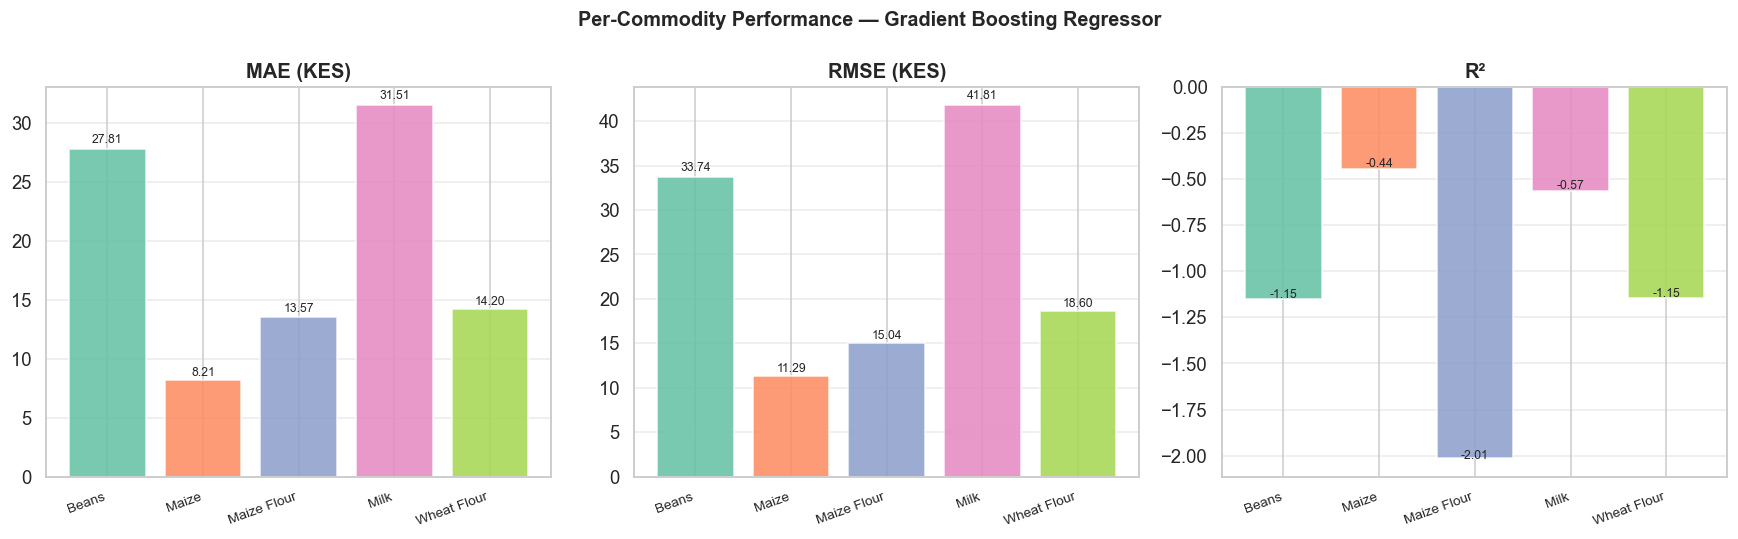

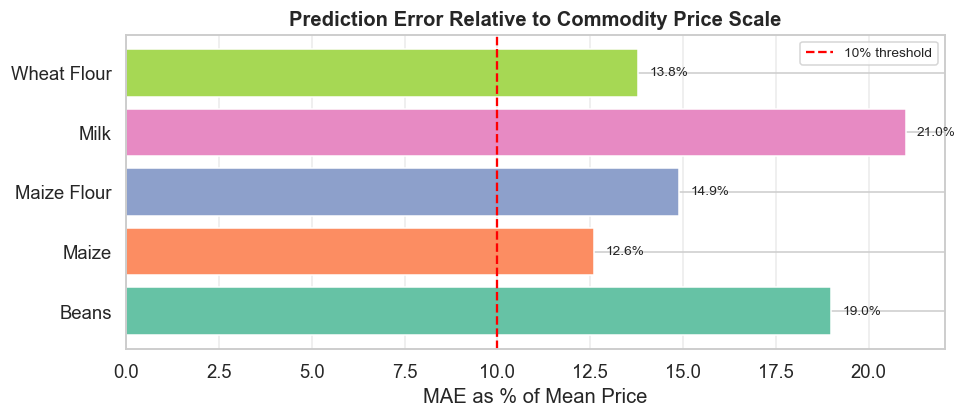

In [39]:
# Comprehensive per-commodity model performance breakdown
test_df['abs_error'] = (test_df['price'] - test_df['predicted']).abs()

commodity_metrics = (
    test_df.groupby('commodity')
    .apply(lambda g: pd.Series({
        'MAE (KES)':       mean_absolute_error(g['price'], g['predicted']),
        'RMSE (KES)':      np.sqrt(mean_squared_error(g['price'], g['predicted'])),
        'R²':              r2_score(g['price'], g['predicted']) if len(g) > 2 else np.nan,
        'N (test rows)':   len(g),
        'Mean Price (KES)': g['price'].mean()
    }))
    .reset_index()
)
commodity_metrics['MAE % of Price'] = (
    commodity_metrics['MAE (KES)'] / commodity_metrics['Mean Price (KES)'] * 100
).round(1)

print('Per-Commodity Model Performance — Gradient Boosting Regressor')
print('=' * 80)
print(commodity_metrics.to_string(index=False, float_format='{:.2f}'.format))
print()

# Filter to key commodities for chart
cm_key = commodity_metrics[commodity_metrics['commodity'].isin(KEY_COMM_LIST)].copy()

# Visual bar chart — MAE, RMSE, R² side by side for each commodity
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = range(len(cm_key))
bar_colors = sns.color_palette('Set2', len(cm_key))

for ax, metric in zip(axes, ['MAE (KES)', 'RMSE (KES)', 'R²']):
    bars = ax.bar(x, cm_key[metric], color=bar_colors, edgecolor='white', alpha=0.88)
    ax.set_xticks(list(x))
    ax.set_xticklabels(cm_key['commodity'], rotation=20, ha='right', fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, cm_key[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Per-Commodity Performance — Gradient Boosting Regressor',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# MAE % of Price — how accurate are we relative to commodity price scale?
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(cm_key['commodity'], cm_key['MAE % of Price'],
               color=bar_colors, edgecolor='white')
ax.axvline(10, color='red', ls='--', lw=1.5, label='10% threshold')
ax.set_xlabel('MAE as % of Mean Price')
ax.set_title('Prediction Error Relative to Commodity Price Scale',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, cm_key['MAE % of Price']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


---
# 8. In-Depth Per-Commodity Modelling

For each key commodity (**Maize, Beans, Milk, Maize Flour, Wheat Flour**) we:
1. Prepare a commodity-specific feature matrix  
2. Train Linear Regression, Random Forest & Gradient Boosting  
3. Evaluate with MAE / RMSE / R²  
4. Run 5-Fold Cross-Validation on the best model  
5. Plot Feature Importance  
6. Plot Actual vs. Predicted time-series  
7. Produce a final consolidated leaderboard across all commodities  


## 8.1. Shared Modelling Helper
Train & evaluate three models for one commodity 

In [40]:
# Shared helper: train & evaluate three models for one commodity 
from sklearn.model_selection import KFold, cross_val_score

def model_commodity(commodity_name, df_full, split_date=pd.Timestamp('2024-01-01')):
    """
    Trains LR, RF, GBR on data for a single commodity.
    Returns a results dict with models, predictions, metrics, feature names.
    """
    NUMERIC_COLS = [
        'year', 'month_sin', 'month_cos',
        'rainfall_lag_1', 'rainfall_lag_3', 'rainfall_lag_6',
        'rainfall_anom_lag_1', 'rainfall_anom_lag_3',
        'diesel_lag_1', 'diesel_lag_2',
        'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12',
        'price_rolling_3',
    ]
    TARGET = 'price'

    # Filter to this commodity only
    df_c = df_full[df_full['commodity'] == commodity_name].copy()
    df_c = df_c.dropna(subset=[TARGET, 'price_lag_1', 'price_lag_3', 'diesel_lag_1'])

    if len(df_c) < 50:
        print(f'  ⚠  {commodity_name}: only {len(df_c)} rows — skipping.')
        return None

    # OHE county only (commodity is fixed here)
    ohe_c = OneHotEncoder(sparse=False, handle_unknown='ignore')
    county_enc  = ohe_c.fit_transform(df_c[['county']])
    county_cols = [f'county_{v}' for v in ohe_c.categories_[0]]

    X_num  = df_c[NUMERIC_COLS].copy()
    X_county = pd.DataFrame(county_enc, columns=county_cols, index=df_c.index)
    X_all  = pd.concat([X_num, X_county], axis=1)
    feat_names = list(X_all.columns)

    y_c = df_c[TARGET]

    imputer_c = SimpleImputer(strategy='median')
    X_imp_c   = imputer_c.fit_transform(X_all)

    # Temporal split
    tr_mask = df_c['date_month'] < split_date
    te_mask = df_c['date_month'] >= split_date

    if tr_mask.sum() < 30 or te_mask.sum() < 5:
        print(f'  ⚠  {commodity_name}: insufficient train/test split — skipping.')
        return None

    X_tr, X_te = X_imp_c[tr_mask], X_imp_c[te_mask]
    y_tr, y_te = y_c[tr_mask],     y_c[te_mask]

    # ── Models ──
    lr_c  = LinearRegression()
    rf_c  = RandomForestRegressor(n_estimators=200, max_depth=15,
                                   min_samples_leaf=3, n_jobs=-1, random_state=42)
    gbr_c = GradientBoostingRegressor(n_estimators=300, learning_rate=0.08,
                                       max_depth=5, min_samples_leaf=4,
                                       subsample=0.85, random_state=42)

    lr_c.fit(X_tr, y_tr);  y_lr  = lr_c.predict(X_te)
    rf_c.fit(X_tr, y_tr);  y_rf  = rf_c.predict(X_te)
    gbr_c.fit(X_tr, y_tr); y_gbr = gbr_c.predict(X_te)

    def metrics(y_true, y_pred):
        return {
            'MAE':  mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R2':   r2_score(y_true, y_pred)
        }

    return {
        'commodity':   commodity_name,
        'df_c':        df_c,
        'te_mask':     te_mask,
        'feat_names':  feat_names,
        'X_imp':       X_imp_c,
        'y':           y_c,
        'X_te':        X_te,
        'y_te':        y_te,
        'models':      {'LR': lr_c, 'RF': rf_c, 'GBR': gbr_c},
        'preds':       {'LR': y_lr, 'RF': y_rf, 'GBR': y_gbr},
        'metrics':     {'LR': metrics(y_te, y_lr),
                        'RF': metrics(y_te, y_rf),
                        'GBR': metrics(y_te, y_gbr)},
    }

print('Helper function defined ✓')


Helper function defined ✓


## 8.2. Train Models for Every Key Commodity

In [41]:
# Train all three models for each key commodity
comm_results = {}

for commodity in KEY_COMM_LIST:
    print(f'\n━━━  {commodity}  ━━━')
    res = model_commodity(commodity, df)
    if res is not None:
        comm_results[commodity] = res
        m = res['metrics']
        for model_name, met in m.items():
            print(f'  {model_name:<4}  MAE={met["MAE"]:7.2f}  RMSE={met["RMSE"]:7.2f}  R²={met["R2"]:.4f}')

print(f'\n✓ Modelled {len(comm_results)} commodities: {list(comm_results.keys())}')



━━━  Maize  ━━━
  LR    MAE=   5.78  RMSE=   8.16  R²=0.2462
  RF    MAE=   5.97  RMSE=   7.81  R²=0.3094
  GBR   MAE=   5.84  RMSE=   7.36  R²=0.3858

━━━  Beans  ━━━
  LR    MAE=  21.30  RMSE=  26.39  R²=-0.3145
  RF    MAE=  28.19  RMSE=  32.21  R²=-0.9582
  GBR   MAE=  27.74  RMSE=  32.57  R²=-1.0023

━━━  Milk  ━━━
  LR    MAE=  37.50  RMSE=  48.30  R²=-1.0911
  RF    MAE=  64.89  RMSE=  71.65  R²=-3.6020
  GBR   MAE=  41.11  RMSE=  50.92  R²=-1.3242

━━━  Maize Flour  ━━━
  LR    MAE=  36.27  RMSE=  38.68  R²=-18.9239
  RF    MAE=  14.33  RMSE=  16.14  R²=-2.4696
  GBR   MAE=  14.16  RMSE=  16.40  R²=-2.5806

━━━  Wheat Flour  ━━━
  LR    MAE=  48.81  RMSE=  52.96  R²=-16.3980
  RF    MAE=  14.24  RMSE=  17.19  R²=-0.8330
  GBR   MAE=  15.58  RMSE=  18.93  R²=-1.2238

✓ Modelled 5 commodities: ['Maize', 'Beans', 'Milk', 'Maize Flour', 'Wheat Flour']


## 8.3. Per-Commodity Model Comparison Table

In [42]:
# Build consolidated metrics table for all commodities × models
rows = []
for comm, res in comm_results.items():
    for model_name, met in res['metrics'].items():
        rows.append({
            'Commodity': comm,
            'Model':     model_name,
            'MAE (KES)': round(met['MAE'], 2),
            'RMSE (KES)':round(met['RMSE'], 2),
            'R²':        round(met['R2'], 4),
        })

metrics_df = pd.DataFrame(rows)
print('=' * 65)
print(metrics_df.to_string(index=False))
print('=' * 65)

# Best model per commodity
best = metrics_df.loc[metrics_df.groupby('Commodity')['MAE (KES)'].idxmin()]
print('\nBest model per commodity (lowest MAE):')
print(best[['Commodity','Model','MAE (KES)','R²']].to_string(index=False))


   Commodity Model  MAE (KES)  RMSE (KES)       R²
       Maize    LR       5.78        8.16   0.2462
       Maize    RF       5.97        7.81   0.3094
       Maize   GBR       5.84        7.36   0.3858
       Beans    LR      21.30       26.39  -0.3145
       Beans    RF      28.19       32.21  -0.9582
       Beans   GBR      27.74       32.57  -1.0023
        Milk    LR      37.50       48.30  -1.0911
        Milk    RF      64.89       71.65  -3.6020
        Milk   GBR      41.11       50.92  -1.3242
 Maize Flour    LR      36.27       38.68 -18.9239
 Maize Flour    RF      14.33       16.14  -2.4696
 Maize Flour   GBR      14.16       16.40  -2.5806
 Wheat Flour    LR      48.81       52.96 -16.3980
 Wheat Flour    RF      14.24       17.19  -0.8330
 Wheat Flour   GBR      15.58       18.93  -1.2238

Best model per commodity (lowest MAE):
   Commodity Model  MAE (KES)      R²
       Beans    LR      21.30 -0.3145
       Maize    LR       5.78  0.2462
 Maize Flour   GBR      14.16 

## 8.4. Visual Model Comparison — MAE & R² per Commodity

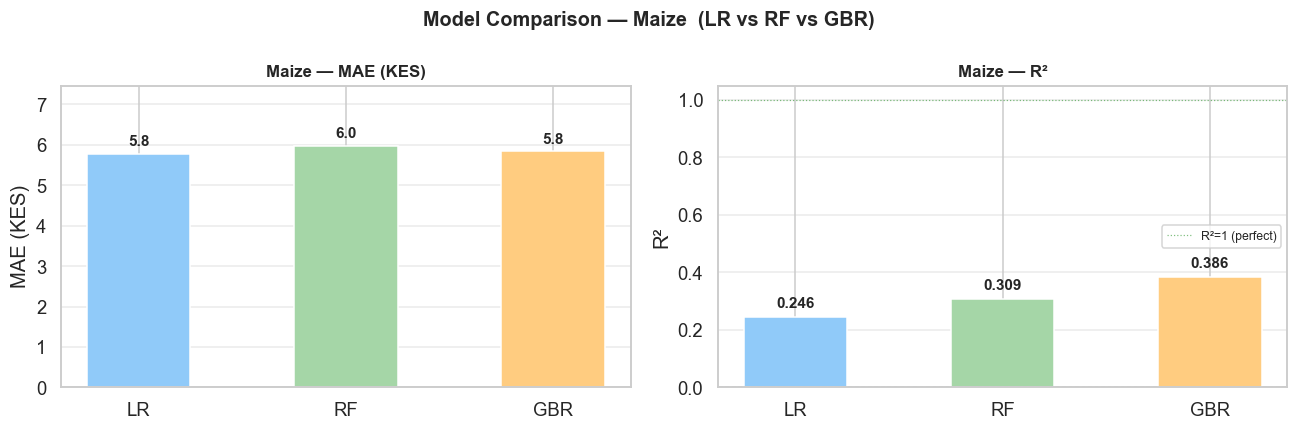

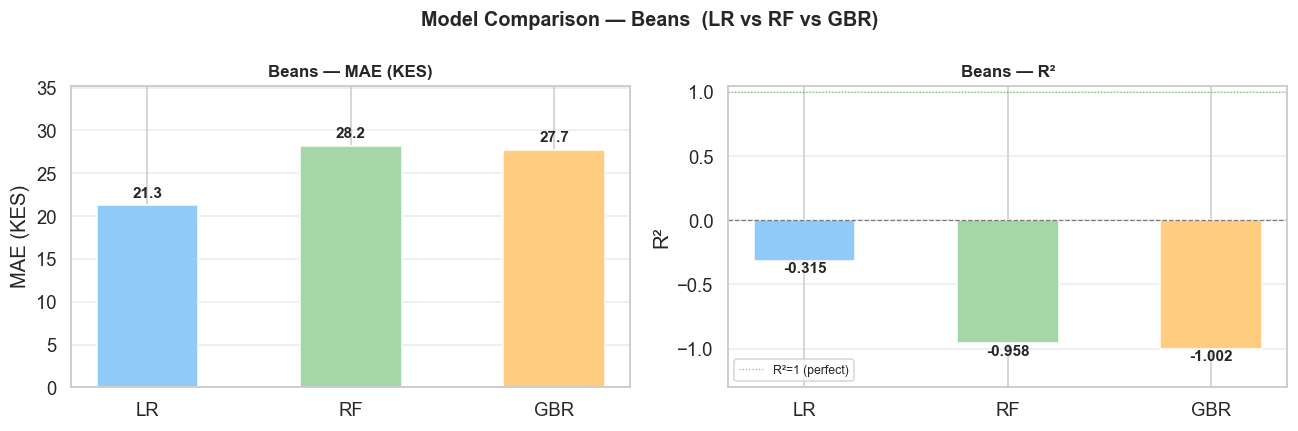

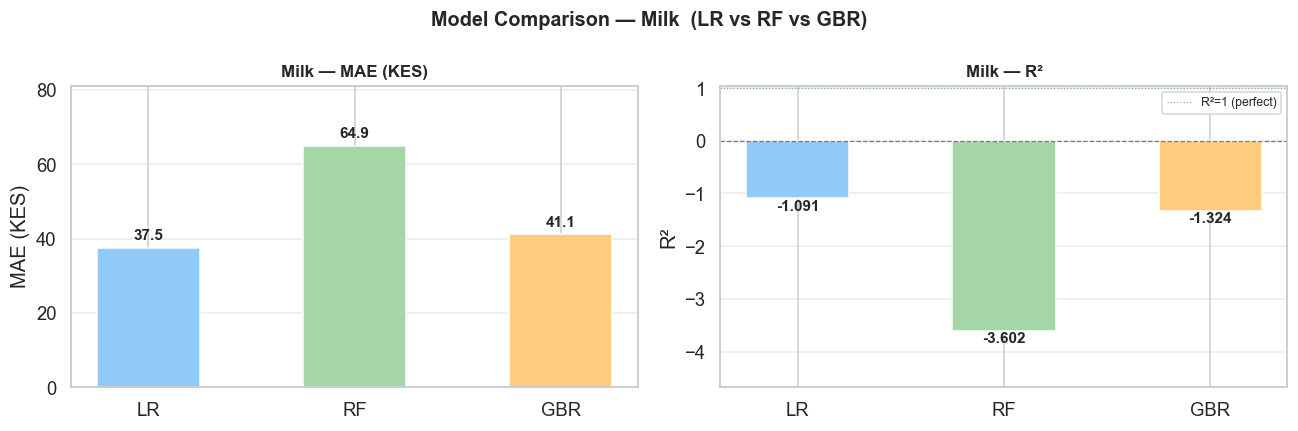

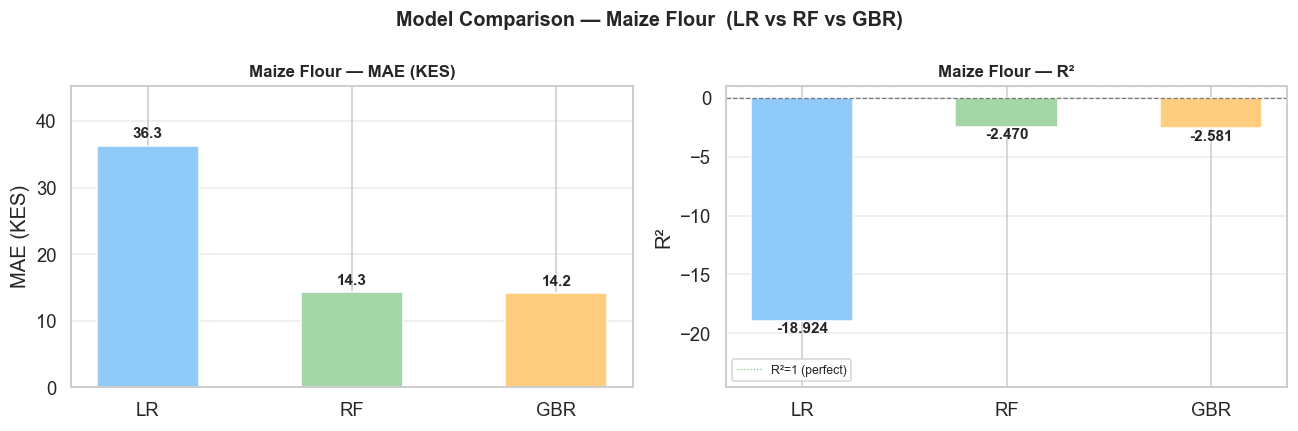

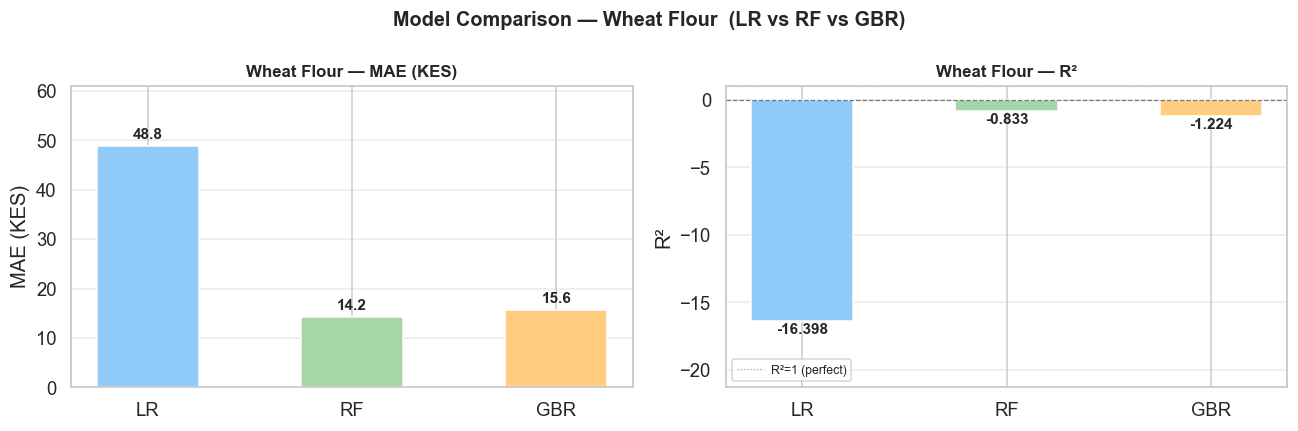

In [43]:
# Grid of bar charts: MAE and R² for LR / RF / GBR per commodity
commodities_done = list(comm_results.keys())
n_c  = len(commodities_done)

model_colors = {'LR': '#90CAF9', 'RF': '#A5D6A7', 'GBR': '#FFCC80'}

# One figure per commodity (avoids axes reshape bugs & diagonal artifact) 
for i, comm in enumerate(commodities_done):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    res  = comm_results[comm]
    mets = res['metrics']
    models_list = list(mets.keys())
    maes  = [mets[m]['MAE']  for m in models_list]
    r2s   = [mets[m]['R2']   for m in models_list]
    cols  = [model_colors[m] for m in models_list]

    # MAE panel
    bars = axes[0].bar(models_list, maes, color=cols, edgecolor='white', width=0.5)
    axes[0].set_title(f'{comm} — MAE (KES)', fontweight='bold', fontsize=11)
    axes[0].set_ylabel('MAE (KES)')
    axes[0].set_ylim(0, max(maes) * 1.25)
    axes[0].grid(axis='y', alpha=0.4)
    for bar, v in zip(bars, maes):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(maes)*0.02,
                     f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # R² panel — handle negative values gracefully 
    r2_floor = min(0, min(r2s)) * 1.3   # extend below 0 if negative
    r2_ceil  = max(1.05, max(r2s) * 1.25)

    bars2 = axes[1].bar(models_list, r2s, color=cols, edgecolor='white', width=0.5)
    axes[1].set_title(f'{comm} — R²', fontweight='bold', fontsize=11)
    axes[1].set_ylabel('R²')
    axes[1].set_ylim(r2_floor, r2_ceil)
    axes[1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)   # zero line
    axes[1].axhline(1, color='green', lw=0.8, ls=':', alpha=0.5, label='R²=1 (perfect)')
    axes[1].grid(axis='y', alpha=0.4)
    axes[1].legend(fontsize=8)

    for bar, v in zip(bars2, r2s):
        label_y = bar.get_height() + (r2_ceil - r2_floor) * 0.02 if v >= 0                   else bar.get_height() - (r2_ceil - r2_floor) * 0.05
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     label_y,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.suptitle(f'Model Comparison — {comm}  (LR vs RF vs GBR)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8.5. K-Fold Cross-Validation — GBR per Commodity

In [44]:
# 5-Fold CV for GBR on each commodity
kf = KFold(n_splits=5, shuffle=False)

cv_summary = []
print('5-Fold Cross-Validation — Gradient Boosting Regressor')
print('=' * 60)

for comm in commodities_done:
    res  = comm_results[comm]
    gbr_c = res['models']['GBR']
    X_c   = res['X_imp']
    y_c   = res['y']

    cv_mae  = -cross_val_score(gbr_c, X_c, y_c, cv=kf,
                                scoring='neg_mean_absolute_error')
    cv_rmse = np.sqrt(-cross_val_score(gbr_c, X_c, y_c, cv=kf,
                                        scoring='neg_mean_squared_error'))
    cv_r2   = cross_val_score(gbr_c, X_c, y_c, cv=kf, scoring='r2')

    print(f'\n  {comm}')
    for fold_i, (m, r, r2) in enumerate(zip(cv_mae, cv_rmse, cv_r2), 1):
        print(f'    Fold {fold_i}: MAE={m:7.2f}  RMSE={r:7.2f}  R²={r2:.4f}')
    print(f'    ── Mean: MAE={cv_mae.mean():7.2f} ± {cv_mae.std():.2f}  '
          f'RMSE={cv_rmse.mean():7.2f}  R²={cv_r2.mean():.4f}')

    cv_summary.append({
        'Commodity':  comm,
        'CV MAE Mean':  round(cv_mae.mean(), 2),
        'CV MAE Std':   round(cv_mae.std(), 2),
        'CV RMSE Mean': round(cv_rmse.mean(), 2),
        'CV R² Mean':   round(cv_r2.mean(), 4),
    })

print('\n' + '=' * 60)
cv_df = pd.DataFrame(cv_summary)
print(cv_df.to_string(index=False))


5-Fold Cross-Validation — Gradient Boosting Regressor

  Maize
    Fold 1: MAE=   4.97  RMSE=   7.01  R²=0.7059
    Fold 2: MAE=   4.76  RMSE=   7.05  R²=0.5927
    Fold 3: MAE=   3.58  RMSE=   4.75  R²=0.9069
    Fold 4: MAE=   3.48  RMSE=   4.38  R²=0.5783
    Fold 5: MAE=   5.49  RMSE=   7.63  R²=0.6634
    ── Mean: MAE=   4.46 ± 0.79  RMSE=   6.16  R²=0.6894

  Beans
    Fold 1: MAE=  12.55  RMSE=  17.07  R²=0.6230
    Fold 2: MAE=   8.98  RMSE=  11.97  R²=0.7328
    Fold 3: MAE=   8.16  RMSE=  12.35  R²=0.6057
    Fold 4: MAE=   8.67  RMSE=  11.83  R²=0.8638
    Fold 5: MAE=  13.00  RMSE=  16.88  R²=0.6732
    ── Mean: MAE=  10.27 ± 2.06  RMSE=  14.02  R²=0.6997

  Milk
    Fold 1: MAE=  30.95  RMSE=  39.06  R²=0.4944
    Fold 2: MAE=   4.37  RMSE=   5.71  R²=0.3069
    Fold 3: MAE=   2.64  RMSE=   3.37  R²=-0.0048
    Fold 4: MAE=   1.59  RMSE=   2.19  R²=0.3358
    Fold 5: MAE=  21.97  RMSE=  32.00  R²=0.6441
    ── Mean: MAE=  12.30 ± 11.93  RMSE=  16.47  R²=0.3553

  Maize Flo

## 8.6. Feature Importance
Feature Importance — LR (coefficients), RF & GBR per commodity 

For each commodity: one figure with 3 panels (one per model)

LR uses absolute coefficients; RF & GBR use built-in feature_importances_


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Maize
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  county_Mandera                 0.1548  County (location)
  county_Kitui                   0.1400  County (location)
  county_Turkana                 0.1255  County (location)
  county_Garissa                 0.1029  County (location)
  county_Nairobi                 0.0848  County (location)
  county_Wajir                   0.0770  County (location)
  month_cos                      0.0517  Time (year / month)
  county_Kilifi                  0.0485  County (location)
  price_lag_1                    0.0431  Price lags (autoregressive)
  county_Marsabit                0.0370  County (location)

  RF — Top 10 Features:
  Feature                         Score  Group
  -----------------------------------------------------

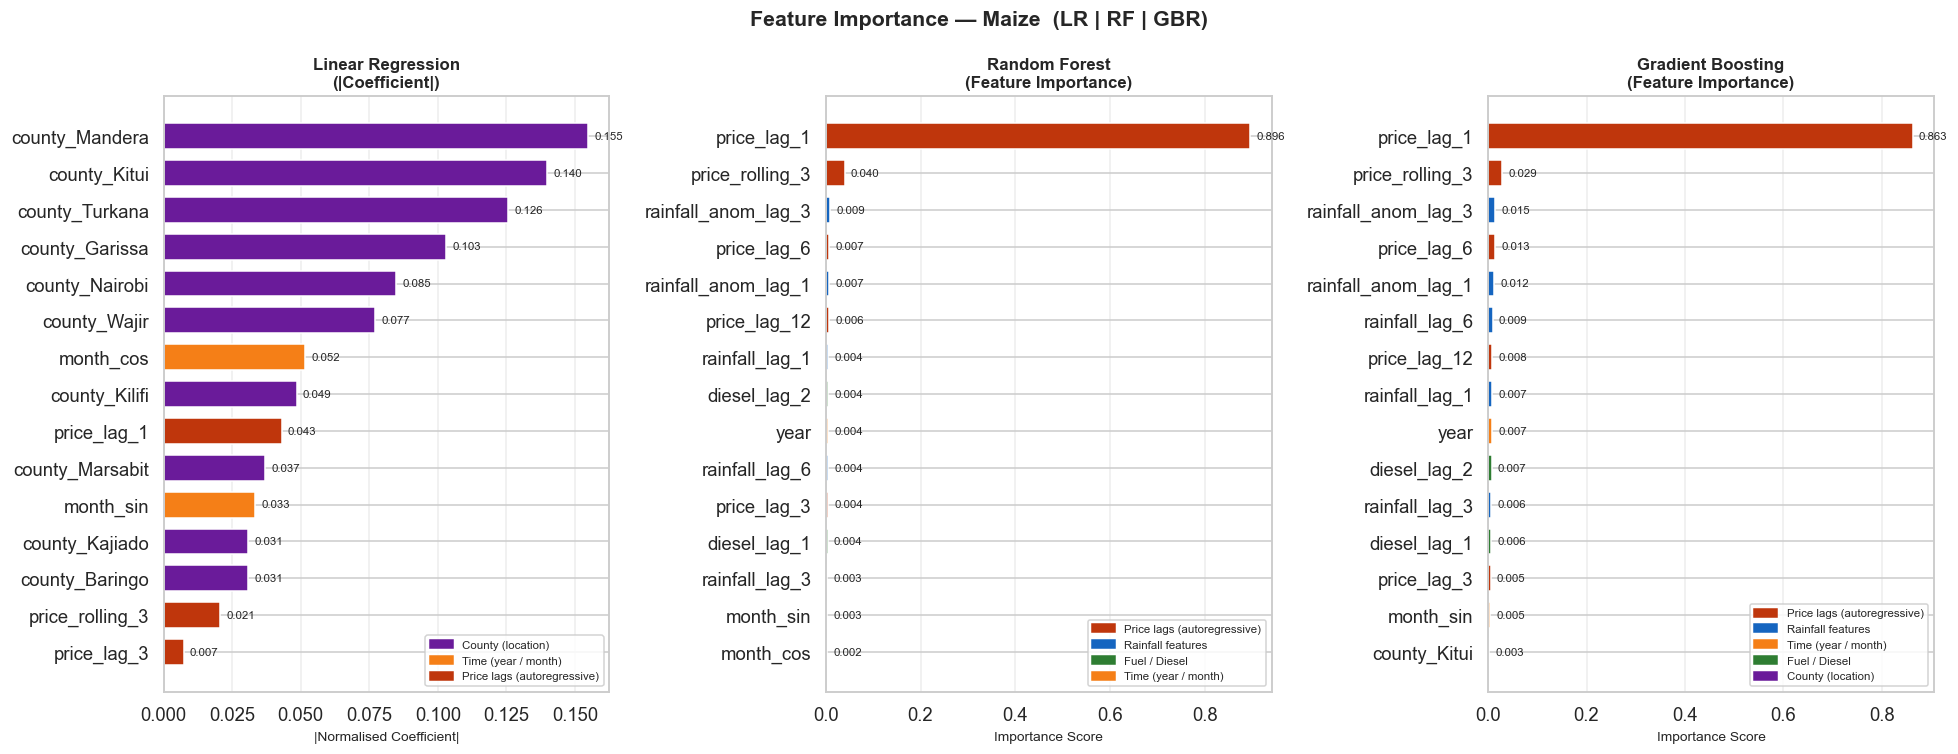

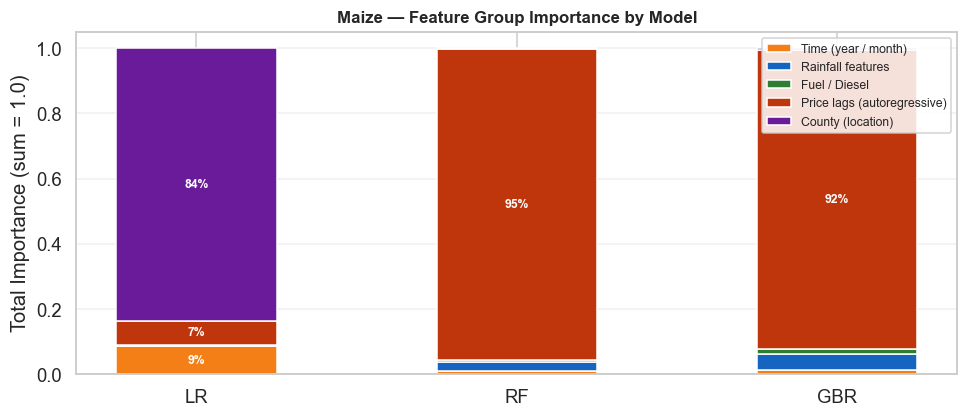


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Beans
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  county_Isiolo                  0.4496  County (location)
  county_Marsabit                0.1162  County (location)
  county_Kitui                   0.1130  County (location)
  county_Garissa                 0.0643  County (location)
  county_Nairobi                 0.0632  County (location)
  county_Turkana                 0.0432  County (location)
  county_Kajiado                 0.0243  County (location)
  month_cos                      0.0240  Time (year / month)
  county_Mombasa                 0.0234  County (location)
  county_Kilifi                  0.0201  County (location)

  RF — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  year 

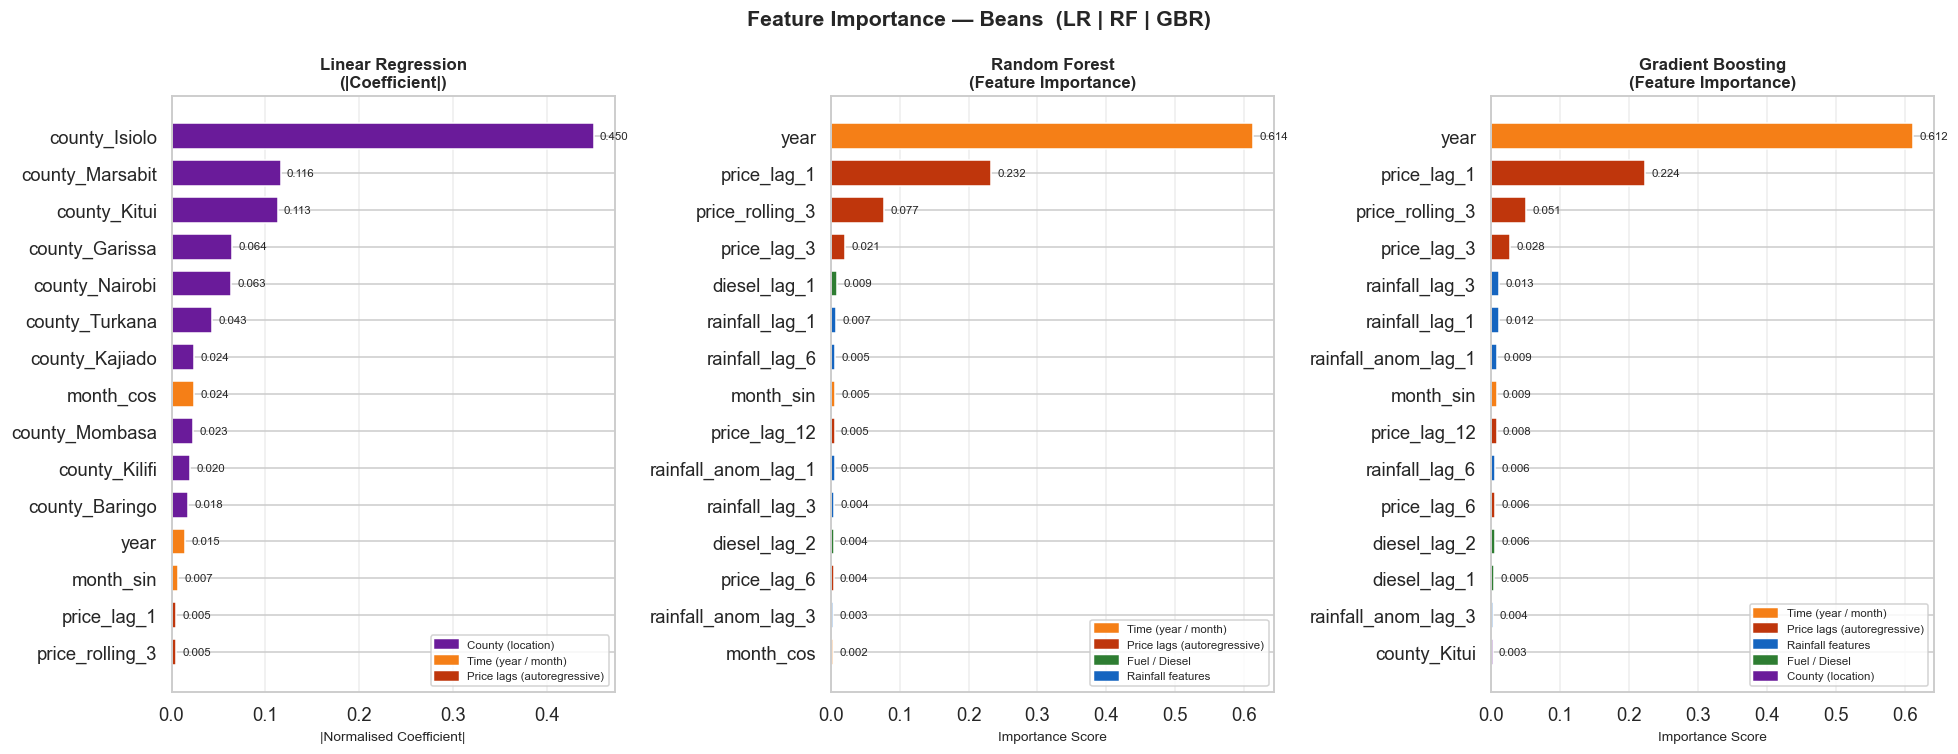

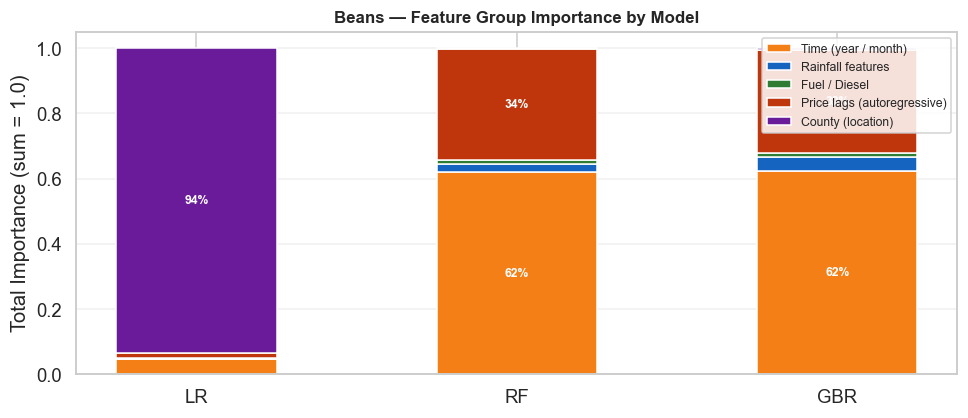


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Milk
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  county_Turkana                 0.4837  County (location)
  county_Nairobi                 0.4837  County (location)
  month_sin                      0.0119  Time (year / month)
  price_lag_1                    0.0062  Price lags (autoregressive)
  month_cos                      0.0049  Time (year / month)
  year                           0.0020  Time (year / month)
  price_rolling_3                0.0020  Price lags (autoregressive)
  diesel_lag_2                   0.0019  Fuel / Diesel
  diesel_lag_1                   0.0012  Fuel / Diesel
  price_lag_6                    0.0010  Price lags (autoregressive)

  RF — Top 10 Features:
  Feature                         Score  Group
  --------------------------------------

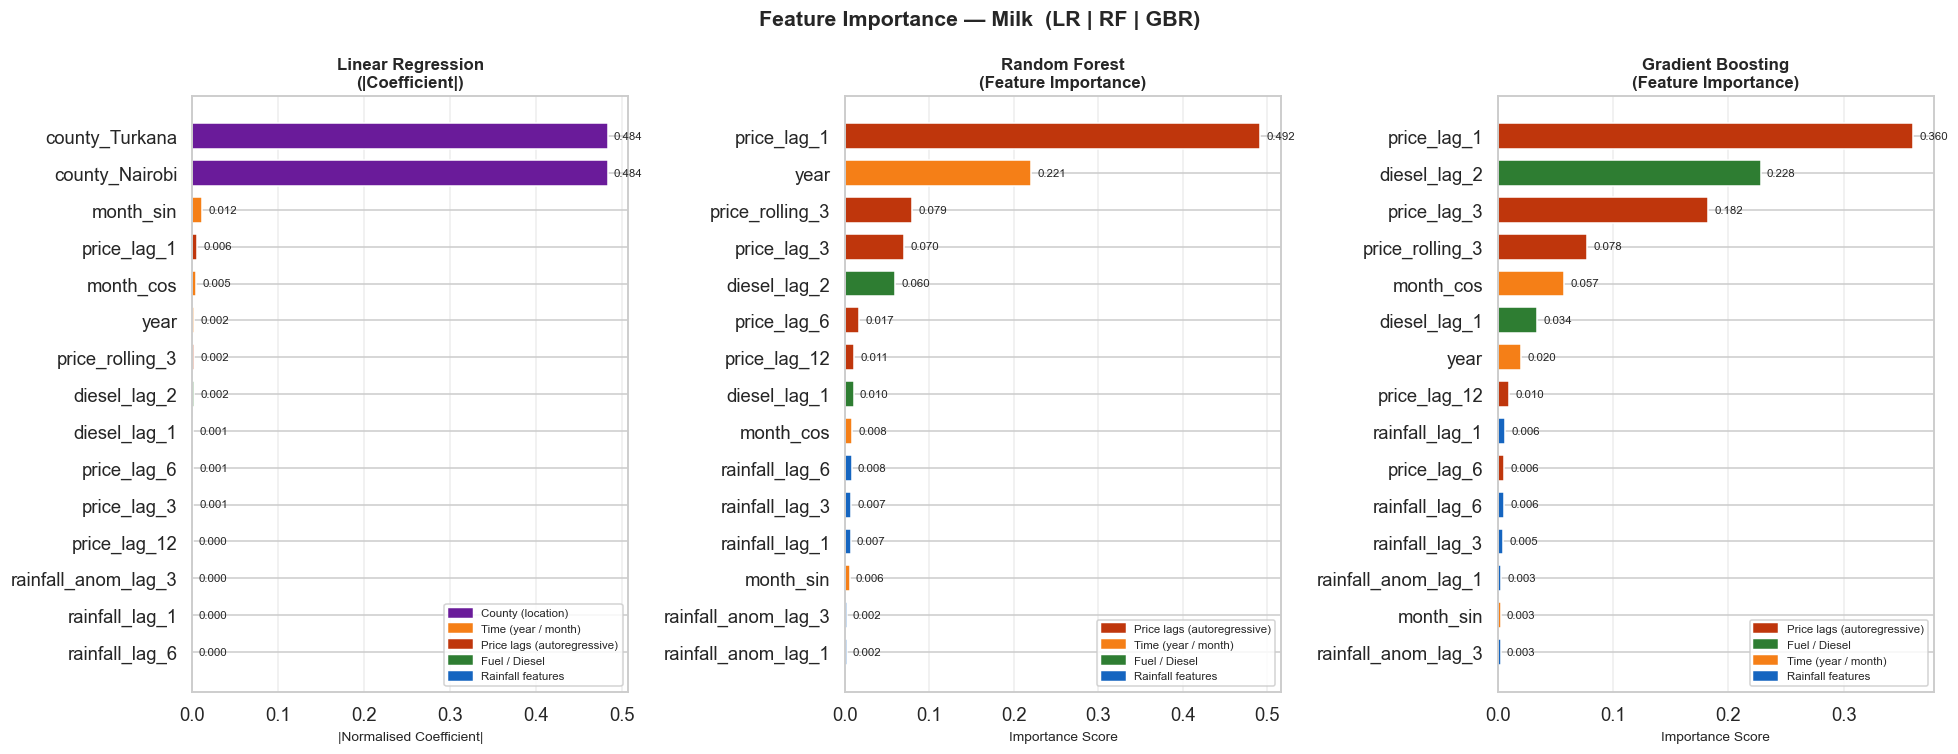

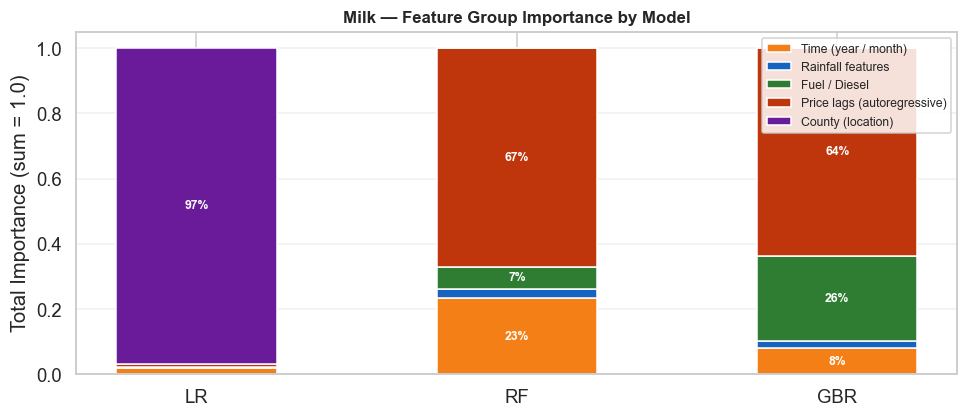


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Maize Flour
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  year                           0.2665  Time (year / month)
  county_Wajir                   0.1894  County (location)
  county_Baringo                 0.1338  County (location)
  county_Garissa                 0.0843  County (location)
  month_sin                      0.0774  Time (year / month)
  county_Isiolo                  0.0502  County (location)
  county_Mombasa                 0.0499  County (location)
  county_Marsabit                0.0384  County (location)
  county_Nairobi                 0.0353  County (location)
  county_Turkana                 0.0337  County (location)

  RF — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------

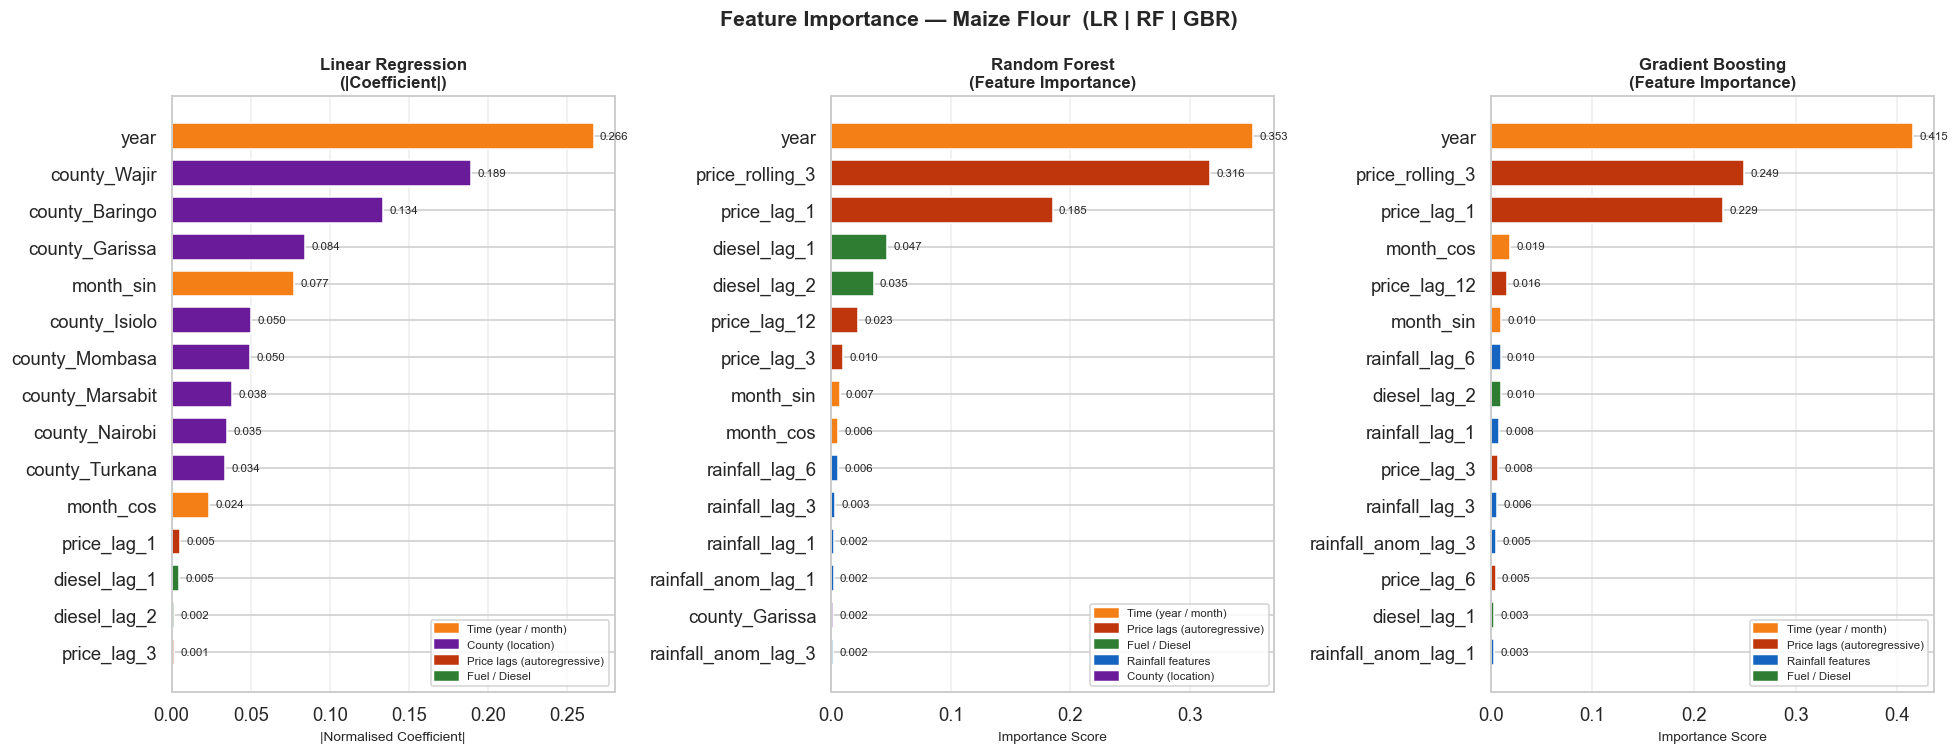

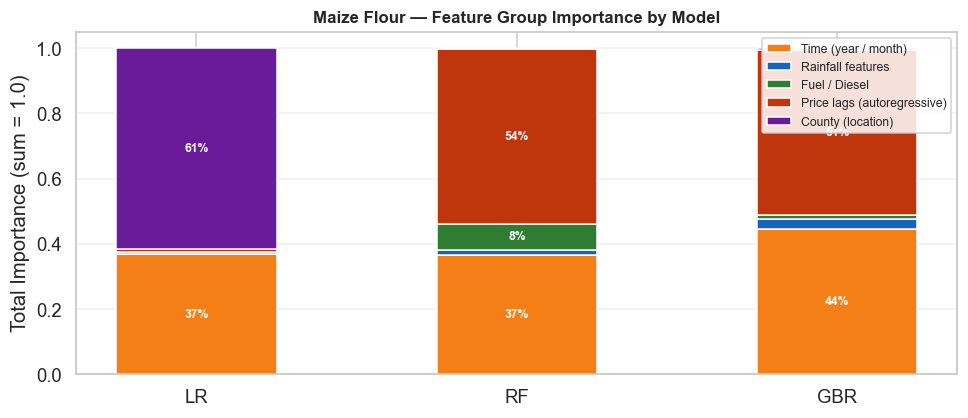


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Wheat Flour
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  year                           0.3858  Time (year / month)
  county_Marsabit                0.1765  County (location)
  county_Wajir                   0.1654  County (location)
  month_cos                      0.0505  Time (year / month)
  county_Garissa                 0.0418  County (location)
  county_Isiolo                  0.0408  County (location)
  county_Mombasa                 0.0337  County (location)
  county_Baringo                 0.0300  County (location)
  county_Nairobi                 0.0286  County (location)
  county_Turkana                 0.0209  County (location)

  RF — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------

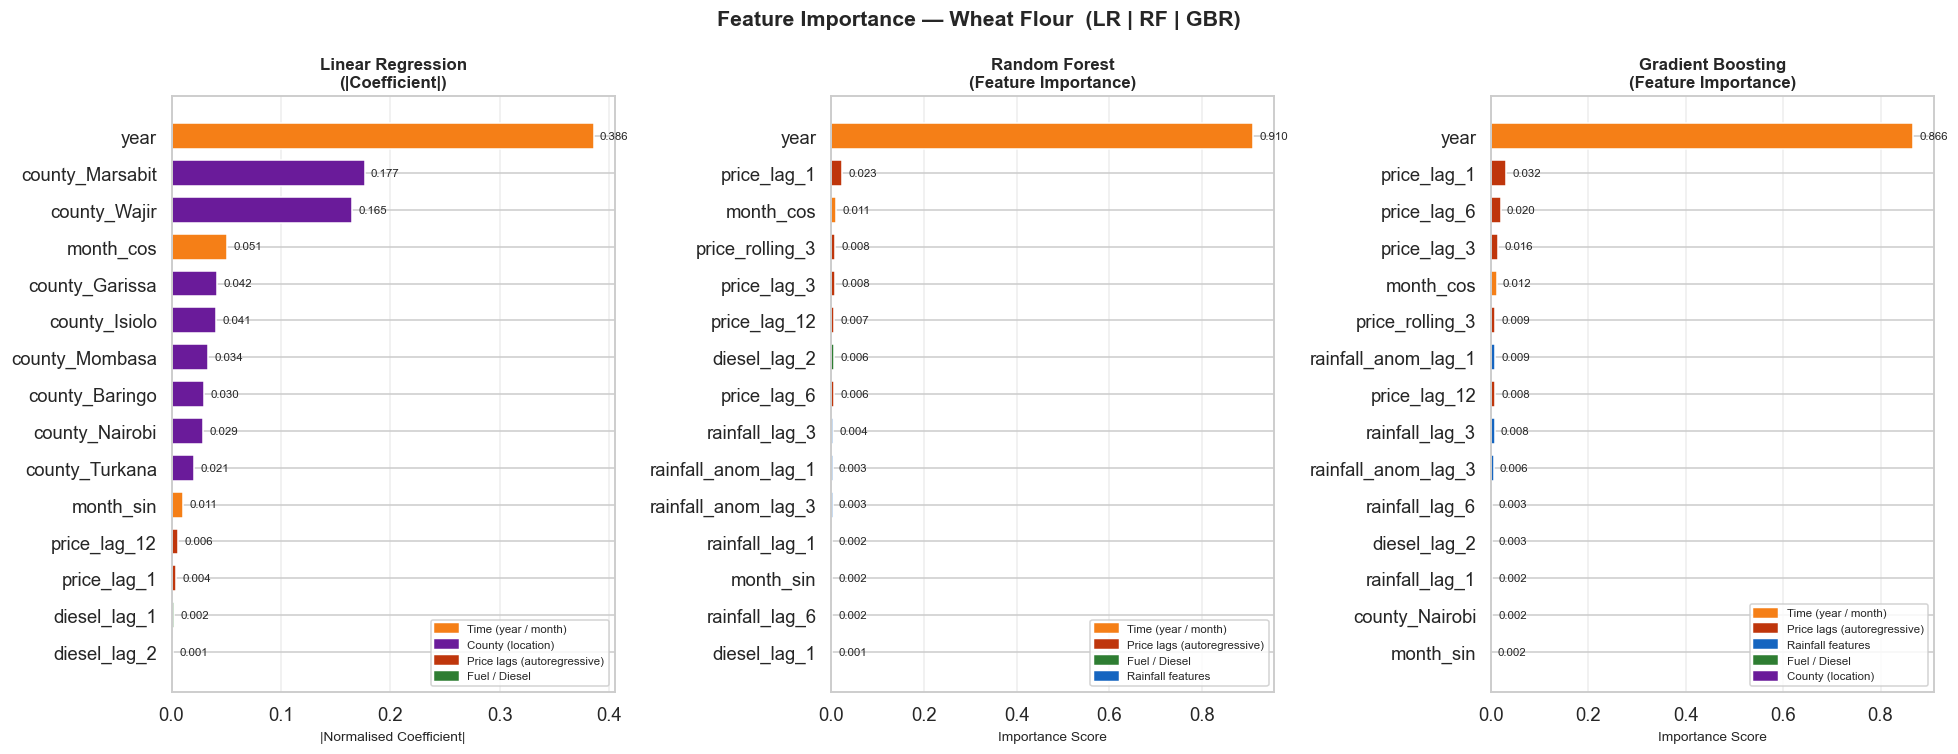

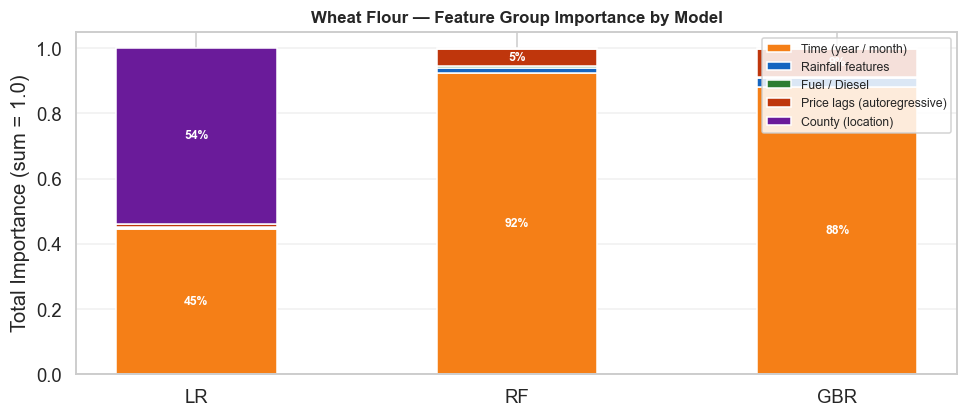

In [45]:
# Feature importance heatmap + individual bar charts
# n_c   = len(commodities_done)
# top_n = 15

# fig, axes = plt.subplots(1, n_c, figsize=(6 * n_c, 8))
# if n_c == 1:
#    axes = [axes]

# /def fi_color(f):
#    if 'price'    in f: return '#BF360C'
#    if 'rainfall' in f: return '#1565C0'
#    if 'diesel'   in f: return '#2E7D32'
#    return '#6A1B9A'

#for ax, comm in zip(axes, commodities_done):
#    res      = comm_results[comm]
#    gbr_c    = res['models']['GBR']
#    feat_names = res['feat_names']

#    fi = pd.Series(gbr_c.feature_importances_, index=feat_names)            .sort_values(ascending=False).head(top_n)
#    colors_fi = [fi_color(f) for f in fi.index]

#    ax.barh(fi.index[::-1], fi.values[::-1],
#            color=colors_fi[::-1], edgecolor='white')
#    ax.set_title(f'{comm}\n(Top {top_n} Features)', fontweight='bold', fontsize=10)
#    ax.set_xlabel('Importance')
#   ax.grid(axis='x', alpha=0.4)

#from matplotlib.patches import Patch
#legend_handles = [
#    Patch(color='#BF360C', label='Price lags'),
#    Patch(color='#1565C0', label='Rainfall'),
#    Patch(color='#2E7D32', label='Fuel/Diesel'),
#    Patch(color='#6A1B9A', label='County OHE & Time'),]
#fig.legend(handles=legend_handles, loc='lower center',
#           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
#plt.suptitle('GBR Feature Importance — All Key Commodities',
#             fontsize=14, fontweight='bold')
#plt.tight_layout()
#plt.show()

# Feature Importance — GBR per commodity 
# Each commodity gets its own figure: top-15 bar chart + grouped summary donut

from matplotlib.patches import Patch
import numpy as np

top_n = 15

def fi_color(f):
    if f.startswith('price_lag') or f == 'price_rolling_3': return '#BF360C'  # red
    if 'rainfall' in f:                                      return '#1565C0'  # blue
    if 'diesel'   in f:                                      return '#2E7D32'  # green
    if f in ('year', 'month_sin', 'month_cos'):              return '#F57F17'  # amber
    if f.startswith('county_'):                              return '#6A1B9A'  # purple
    return '#455A64'

GROUP_LABELS = {
    '#BF360C': 'Price lags (autoregressive)',
    '#1565C0': 'Rainfall features',
    '#2E7D32': 'Fuel / Diesel',
    '#F57F17': 'Time (year / month)',
    '#6A1B9A': 'County (location)',
    '#455A64': 'Other',
}

MODEL_TITLES = {
    'LR':  'Linear Regression\n(|Coefficient|)',
    'RF':  'Random Forest\n(Feature Importance)',
    'GBR': 'Gradient Boosting\n(Feature Importance)',
}
MODEL_COLORS = {
    'LR':  '#90CAF9',   # light blue tint for LR bars
    'RF':  '#A5D6A7',   # light green tint for RF bars
    'GBR': '#FFCC80',   # light amber tint for GBR bars
}

def get_importances(model, model_name, feat_names):
    """Extract normalised importances for any model type."""
    if model_name == 'LR':
        raw = np.abs(model.coef_)
        total = raw.sum()
        return pd.Series(raw / total if total > 0 else raw, index=feat_names)
    else:
        return pd.Series(model.feature_importances_, index=feat_names)

for comm in commodities_done:
    res        = comm_results[comm]
    feat_names = res['feat_names']

    print(f'\n{"━"*65}')
    print(f'  {comm}')
    print(f'{"━"*65}')

    # ── One figure per commodity: 3 columns (LR | RF | GBR) ─────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    for ax, model_name in zip(axes, ['LR', 'RF', 'GBR']):
        model      = res['models'][model_name]
        fi_full    = get_importances(model, model_name, feat_names)
        fi_top     = fi_full.sort_values(ascending=False).head(top_n)
        colors_bar = [fi_color(f) for f in fi_top.index]

        # Horizontal bar chart
        bars = ax.barh(fi_top.index[::-1], fi_top.values[::-1],
                       color=colors_bar[::-1], edgecolor='white', height=0.7)

        ax.set_title(MODEL_TITLES[model_name], fontweight='bold', fontsize=11)
        xlabel = '|Normalised Coefficient|' if model_name == 'LR' else 'Importance Score'
        ax.set_xlabel(xlabel, fontsize=9)
        ax.grid(axis='x', alpha=0.35)

        # Value labels on each bar
        x_pad = fi_top.max() * 0.015
        for bar, val in zip(bars, fi_top.values[::-1]):
            ax.text(bar.get_width() + x_pad,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=7.5)

        # Per-panel legend (only groups actually present)
        present_colors = list(dict.fromkeys(colors_bar))
        legend_handles = [Patch(color=c, label=GROUP_LABELS.get(c, 'Other'))
                          for c in present_colors]
        ax.legend(handles=legend_handles, fontsize=7.5,
                  loc='lower right', framealpha=0.85)

        # Print top-10 table for this model
        print(f'\n  {model_name} — Top 10 Features:')
        print(f'  {"Feature":<28} {"Score":>8}  Group')
        print('  ' + '-'*55)
        for feat, imp in fi_full.sort_values(ascending=False).head(10).items():
            grp = GROUP_LABELS.get(fi_color(feat), 'Other')
            print(f'  {feat:<28} {imp:>8.4f}  {grp}')

    plt.suptitle(f'Feature Importance — {comm}  (LR | RF | GBR)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Grouped importance comparison — stacked bar across models ────────────
    group_data = {}
    for model_name in ['LR', 'RF', 'GBR']:
        model   = res['models'][model_name]
        fi_full = get_importances(model, model_name, feat_names)
        grp_imp = {}
        for feat, imp in fi_full.items():
            lbl = GROUP_LABELS.get(fi_color(feat), 'Other')
            grp_imp[lbl] = grp_imp.get(lbl, 0) + imp
        group_data[model_name] = grp_imp

    grp_df = pd.DataFrame(group_data).fillna(0)
    grp_colors = {
        'Price lags (autoregressive)': '#BF360C',
        'Rainfall features':           '#1565C0',
        'Fuel / Diesel':               '#2E7D32',
        'Time (year / month)':         '#F57F17',
        'County (location)':           '#6A1B9A',
        'Other':                       '#455A64',
    }

    fig2, ax2 = plt.subplots(figsize=(9, 4))
    bottom = np.zeros(3)
    model_names = ['LR', 'RF', 'GBR']
    for grp_label, row in grp_df.iterrows():
        vals   = [row.get(m, 0) for m in model_names]
        color  = grp_colors.get(grp_label, '#455A64')
        bars2  = ax2.bar(model_names, vals, bottom=bottom,
                         color=color, edgecolor='white',
                         width=0.5, label=grp_label)
        # Label segments > 5%
        for rect, val, bot in zip(bars2, vals, bottom):
            if val > 0.05:
                ax2.text(rect.get_x() + rect.get_width()/2,
                         bot + val/2,
                         f'{val*100:.0f}%',
                         ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
        bottom += np.array(vals)

    ax2.set_title(f'{comm} — Feature Group Importance by Model',
                  fontweight='bold', fontsize=11)
    ax2.set_ylabel('Total Importance (sum = 1.0)')
    ax2.set_ylim(0, 1.05)
    ax2.legend(loc='upper right', fontsize=8, framealpha=0.85)
    ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 8.7. Predicted vs. Actual Scatter — All Commodities

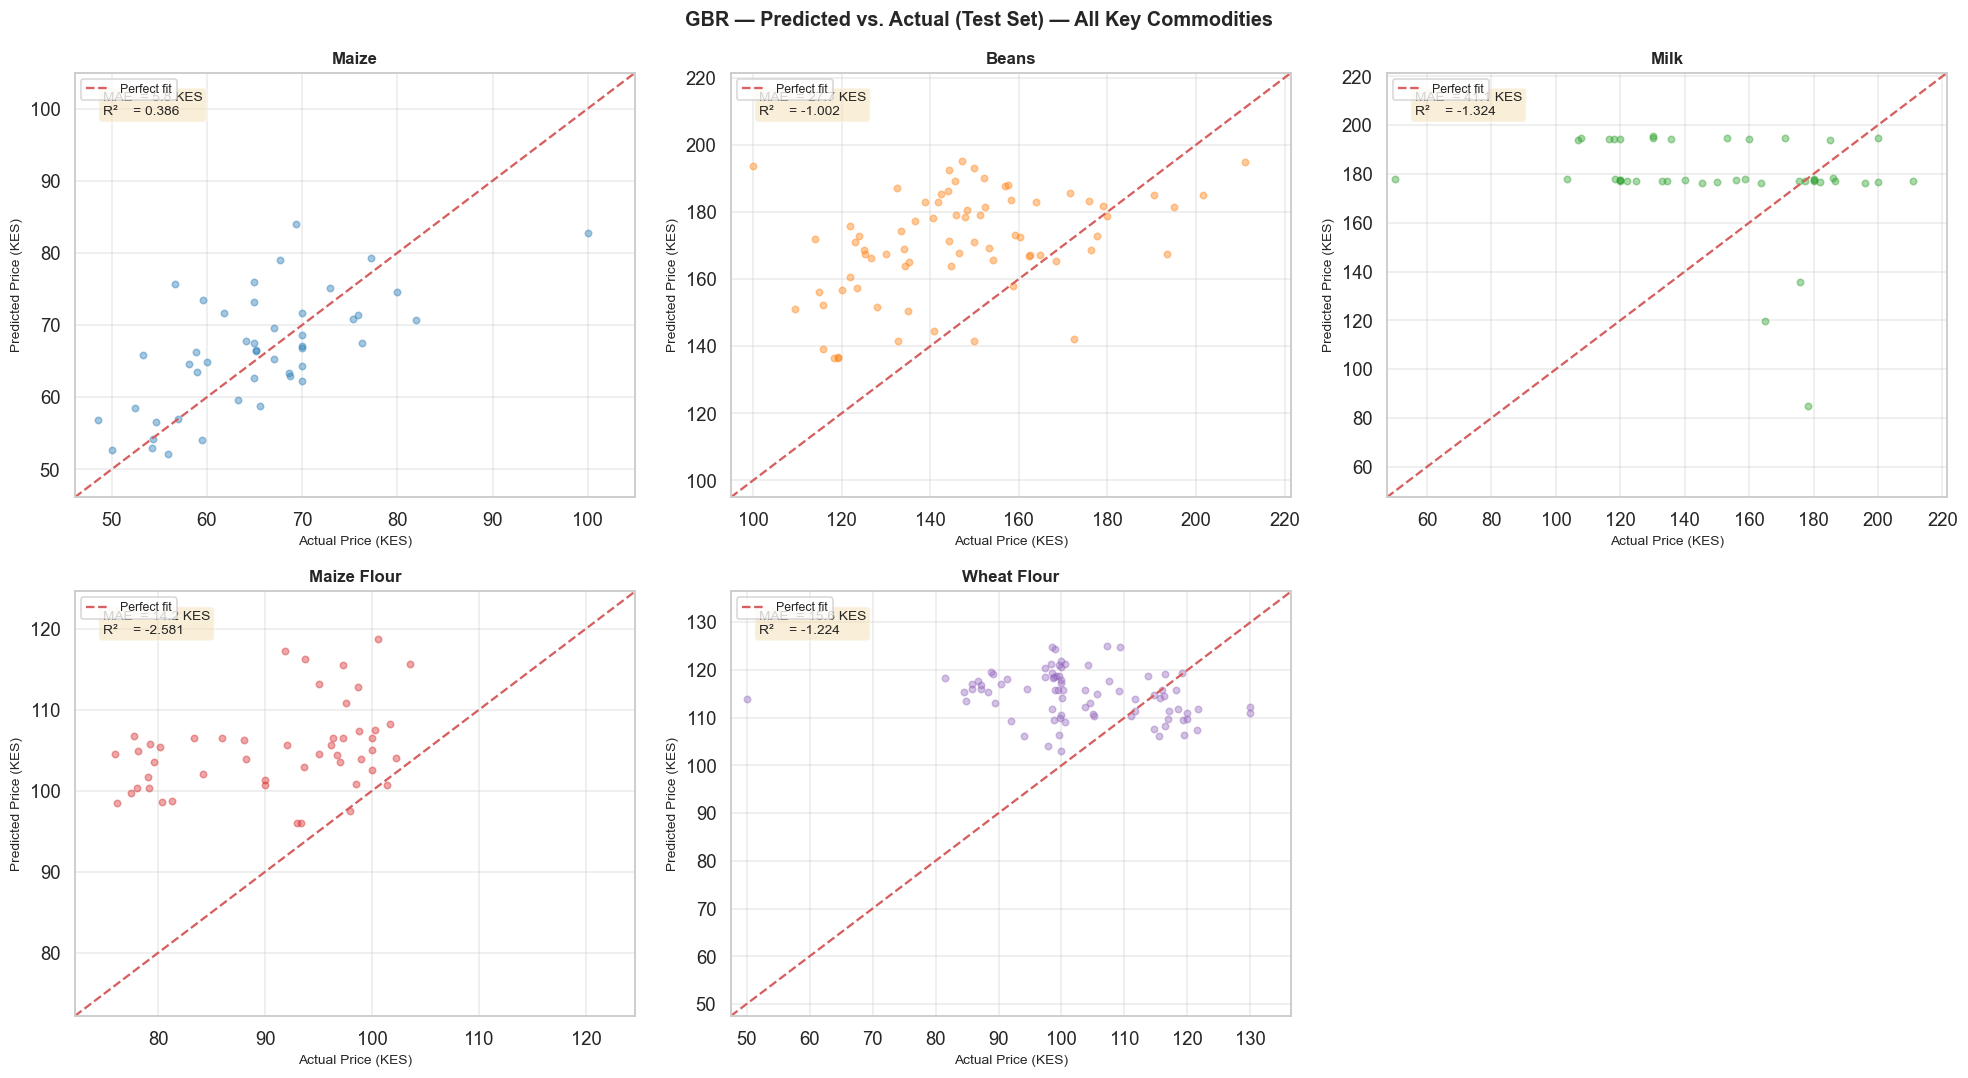

In [46]:
# Predicted vs Actual scatter — one panel per commodity, GBR model
n_c   = len(commodities_done)
cols  = min(n_c, 3)
rows  = (n_c + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.array(axes).flatten() if n_c > 1 else [axes]

scatter_palette = sns.color_palette('tab10', n_c)

for i, comm in enumerate(commodities_done):
    ax   = axes[i]
    res  = comm_results[comm]
    y_te = res['y_te']
    y_pr = res['preds']['GBR']
    mae  = res['metrics']['GBR']['MAE']
    r2   = res['metrics']['GBR']['R2']

    ax.scatter(y_te, y_pr, alpha=0.4, s=18, color=scatter_palette[i])
    lims = [min(y_te.min(), y_pr.min()) * 0.95,
            max(y_te.max(), y_pr.max()) * 1.05]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Price (KES)', fontsize=9)
    ax.set_ylabel('Predicted Price (KES)', fontsize=9)
    ax.set_title(f'{comm}', fontweight='bold', fontsize=11)
    ax.text(0.05, 0.90,
            f'MAE  = {mae:.1f} KES\nR²    = {r2:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.grid(alpha=0.4)
    ax.legend(fontsize=8)

for j in range(n_c, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('GBR — Predicted vs. Actual (Test Set) — All Key Commodities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8.8. Residual Distribution — All Commodities

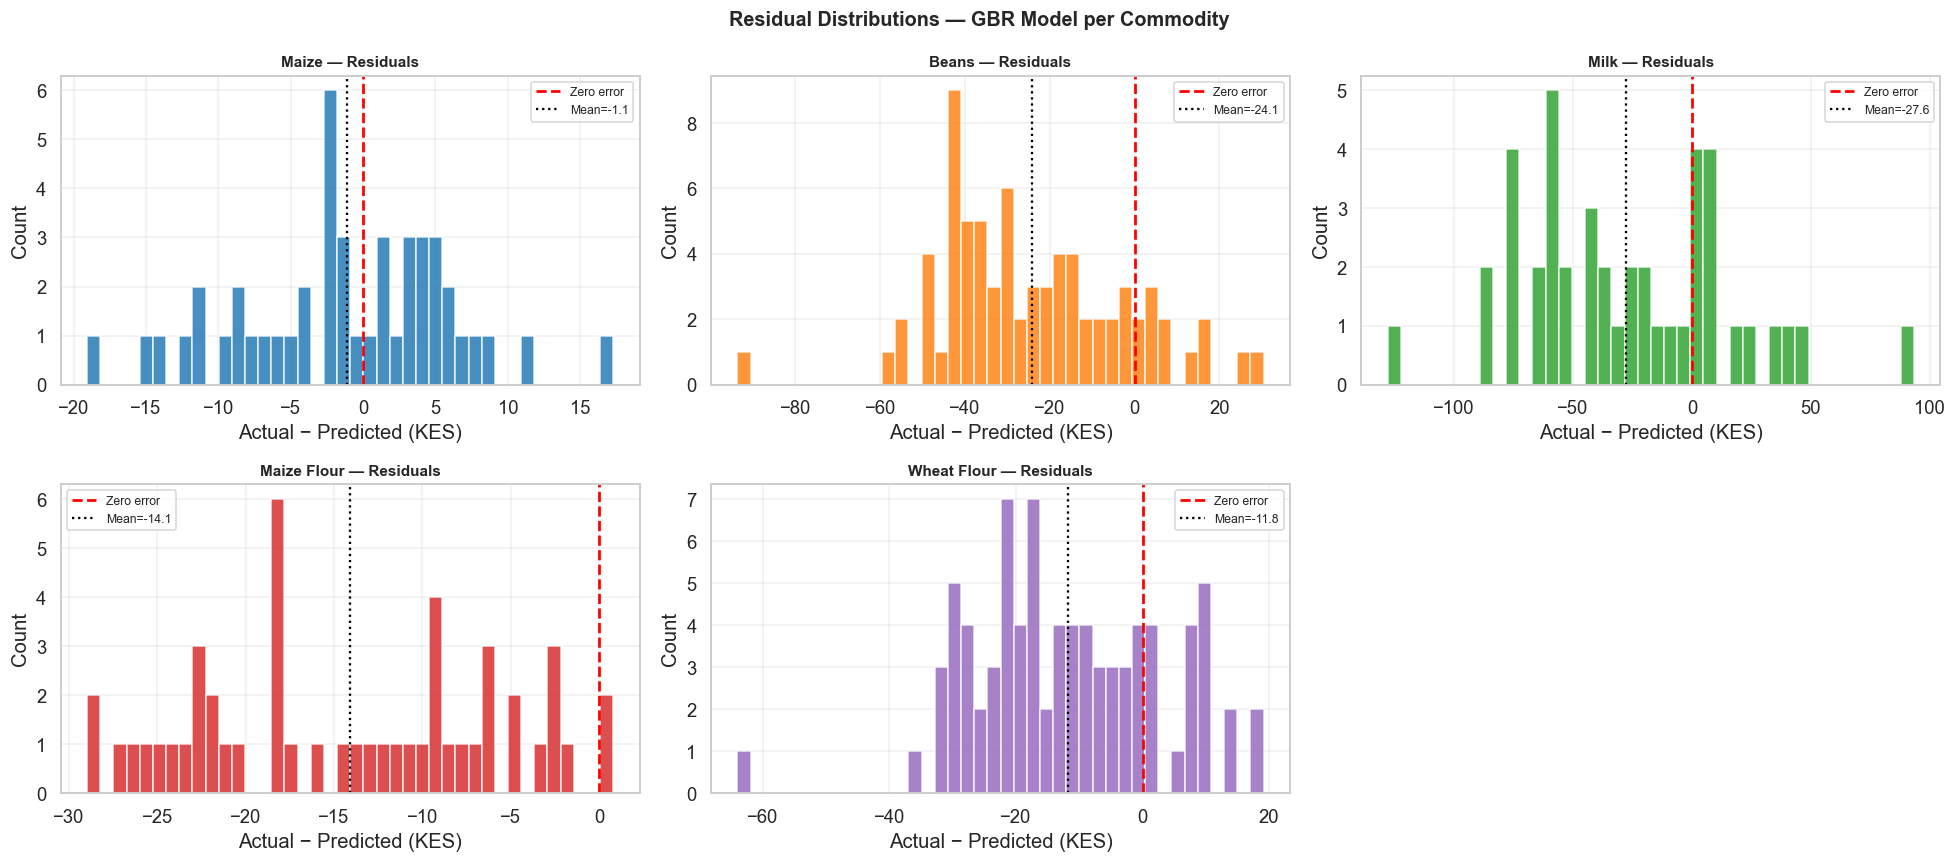

In [47]:
# Residual histograms for GBR — one per commodity
n_c  = len(commodities_done)
cols = min(n_c, 3)
rows = (n_c + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = np.array(axes).flatten() if n_c > 1 else [axes]

for i, comm in enumerate(commodities_done):
    ax  = axes[i]
    res = comm_results[comm]
    residuals = res['y_te'].values - res['preds']['GBR']

    ax.hist(residuals, bins=40, color=scatter_palette[i],
            edgecolor='white', alpha=0.82)
    ax.axvline(0,   color='red',  lw=1.8, ls='--', label='Zero error')
    ax.axvline(residuals.mean(), color='black', lw=1.5,
               ls=':', label=f'Mean={residuals.mean():.1f}')
    ax.set_title(f'{comm} — Residuals', fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual − Predicted (KES)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for j in range(n_c, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Residual Distributions — GBR Model per Commodity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8.9. Actual vs. Predicted Time-Series — All Commodities & Top Counties

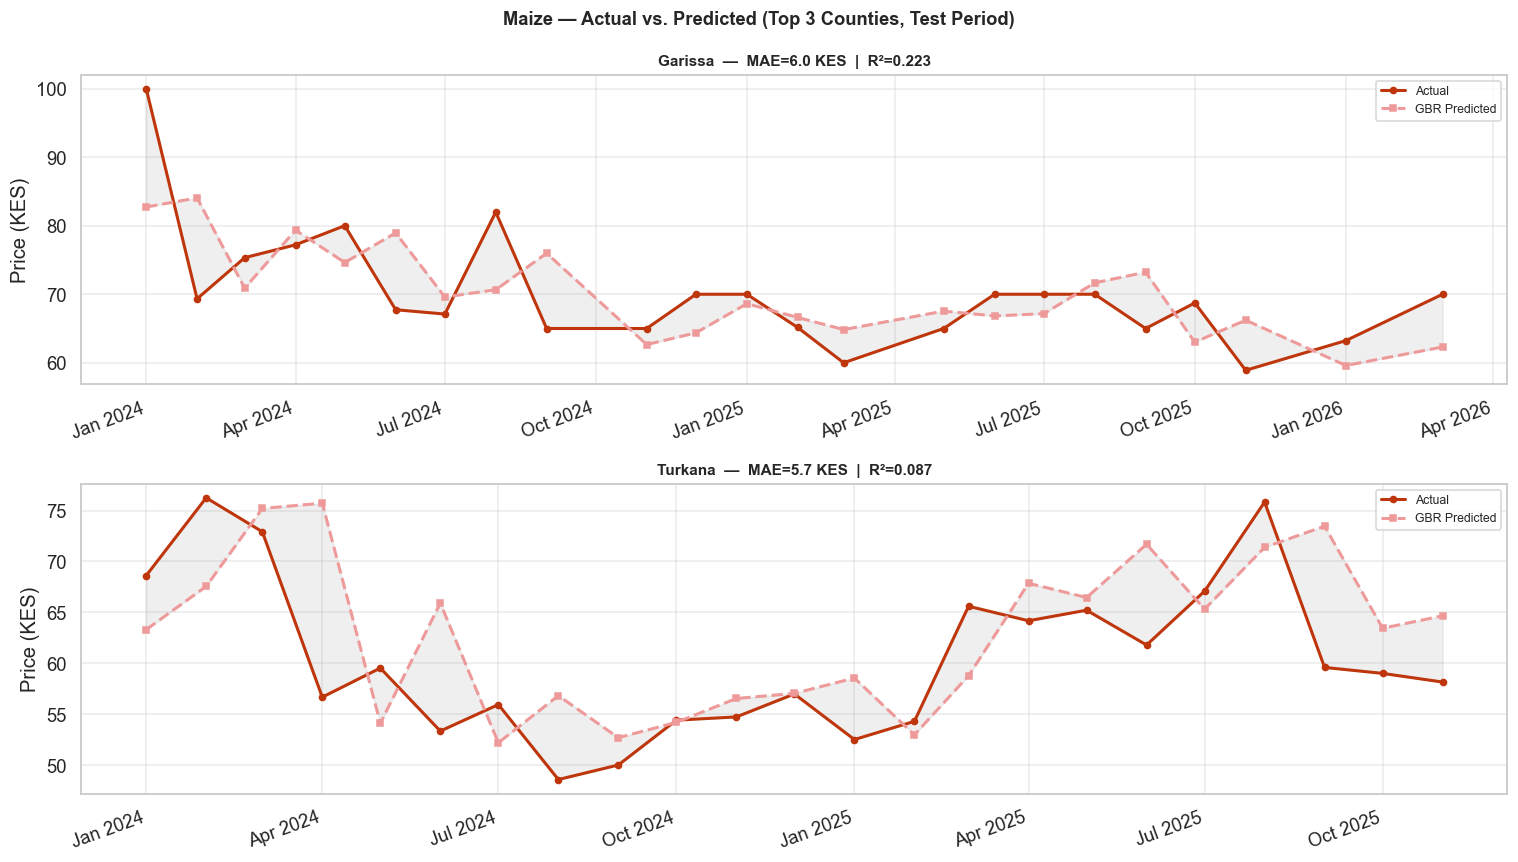

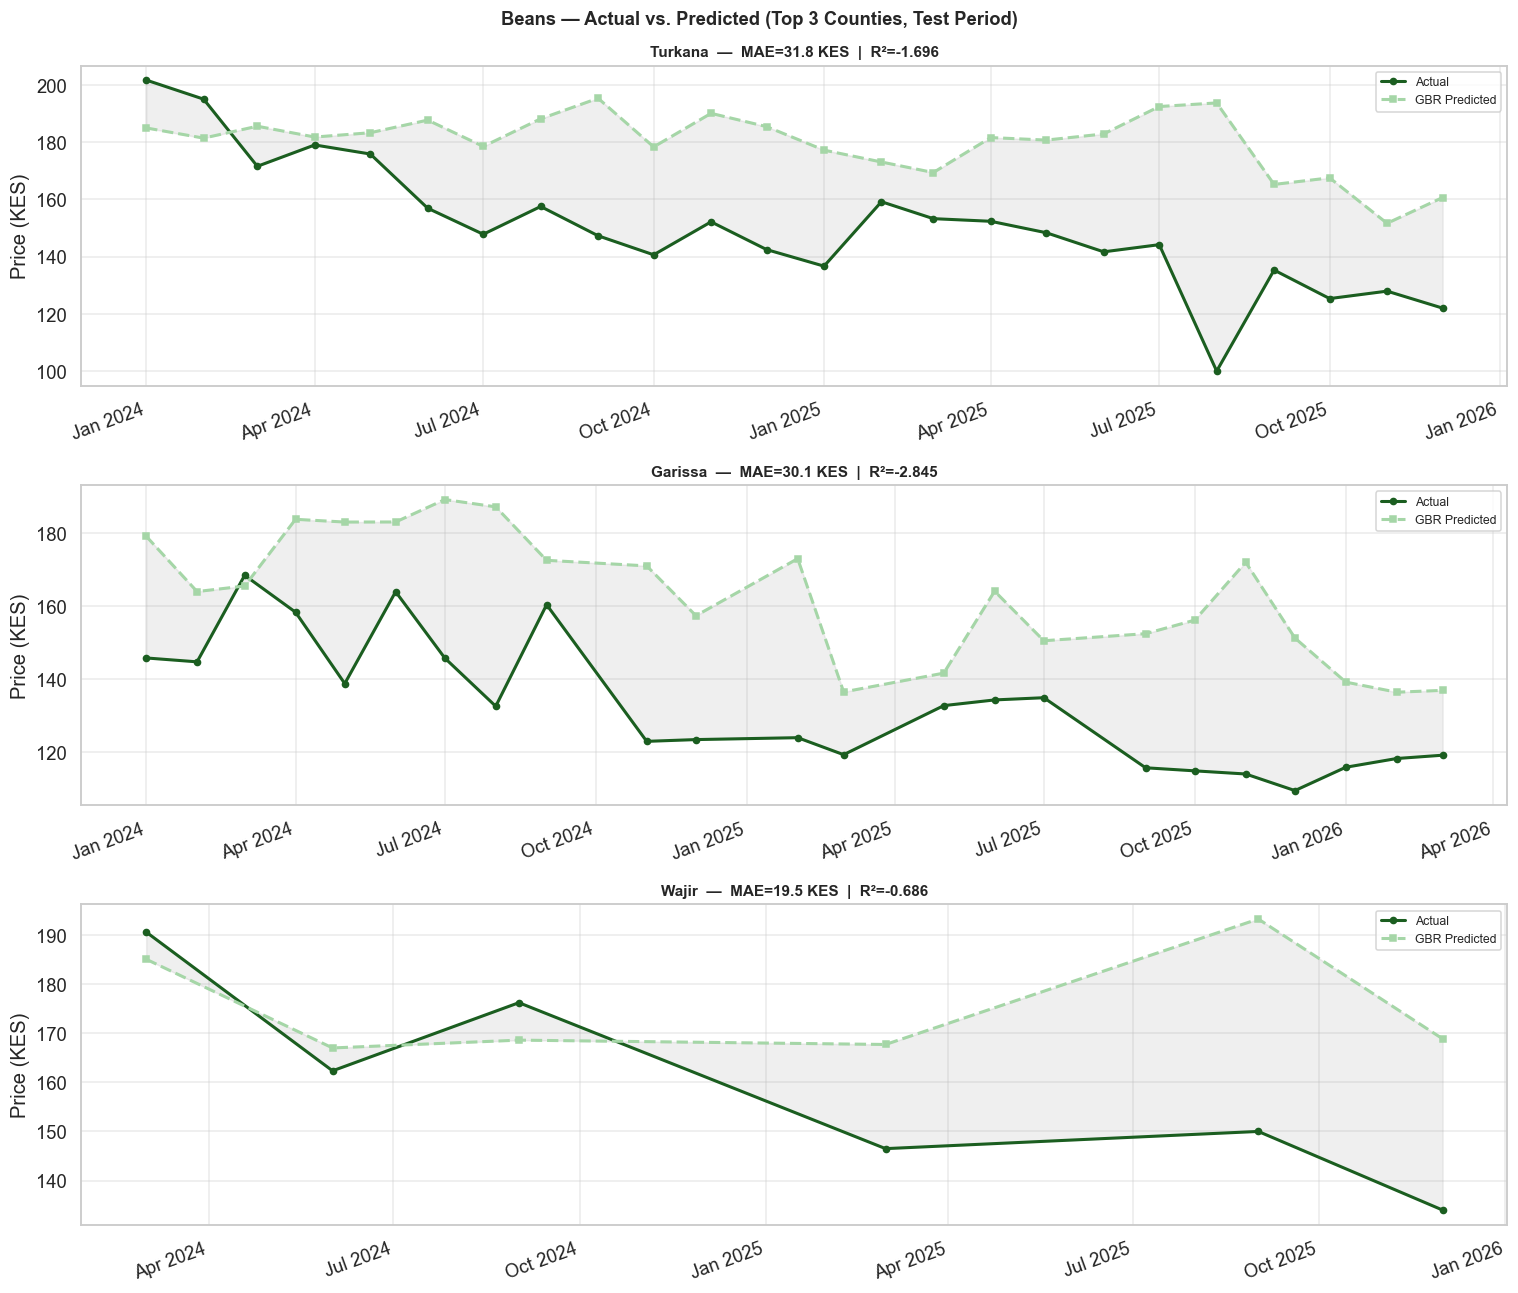

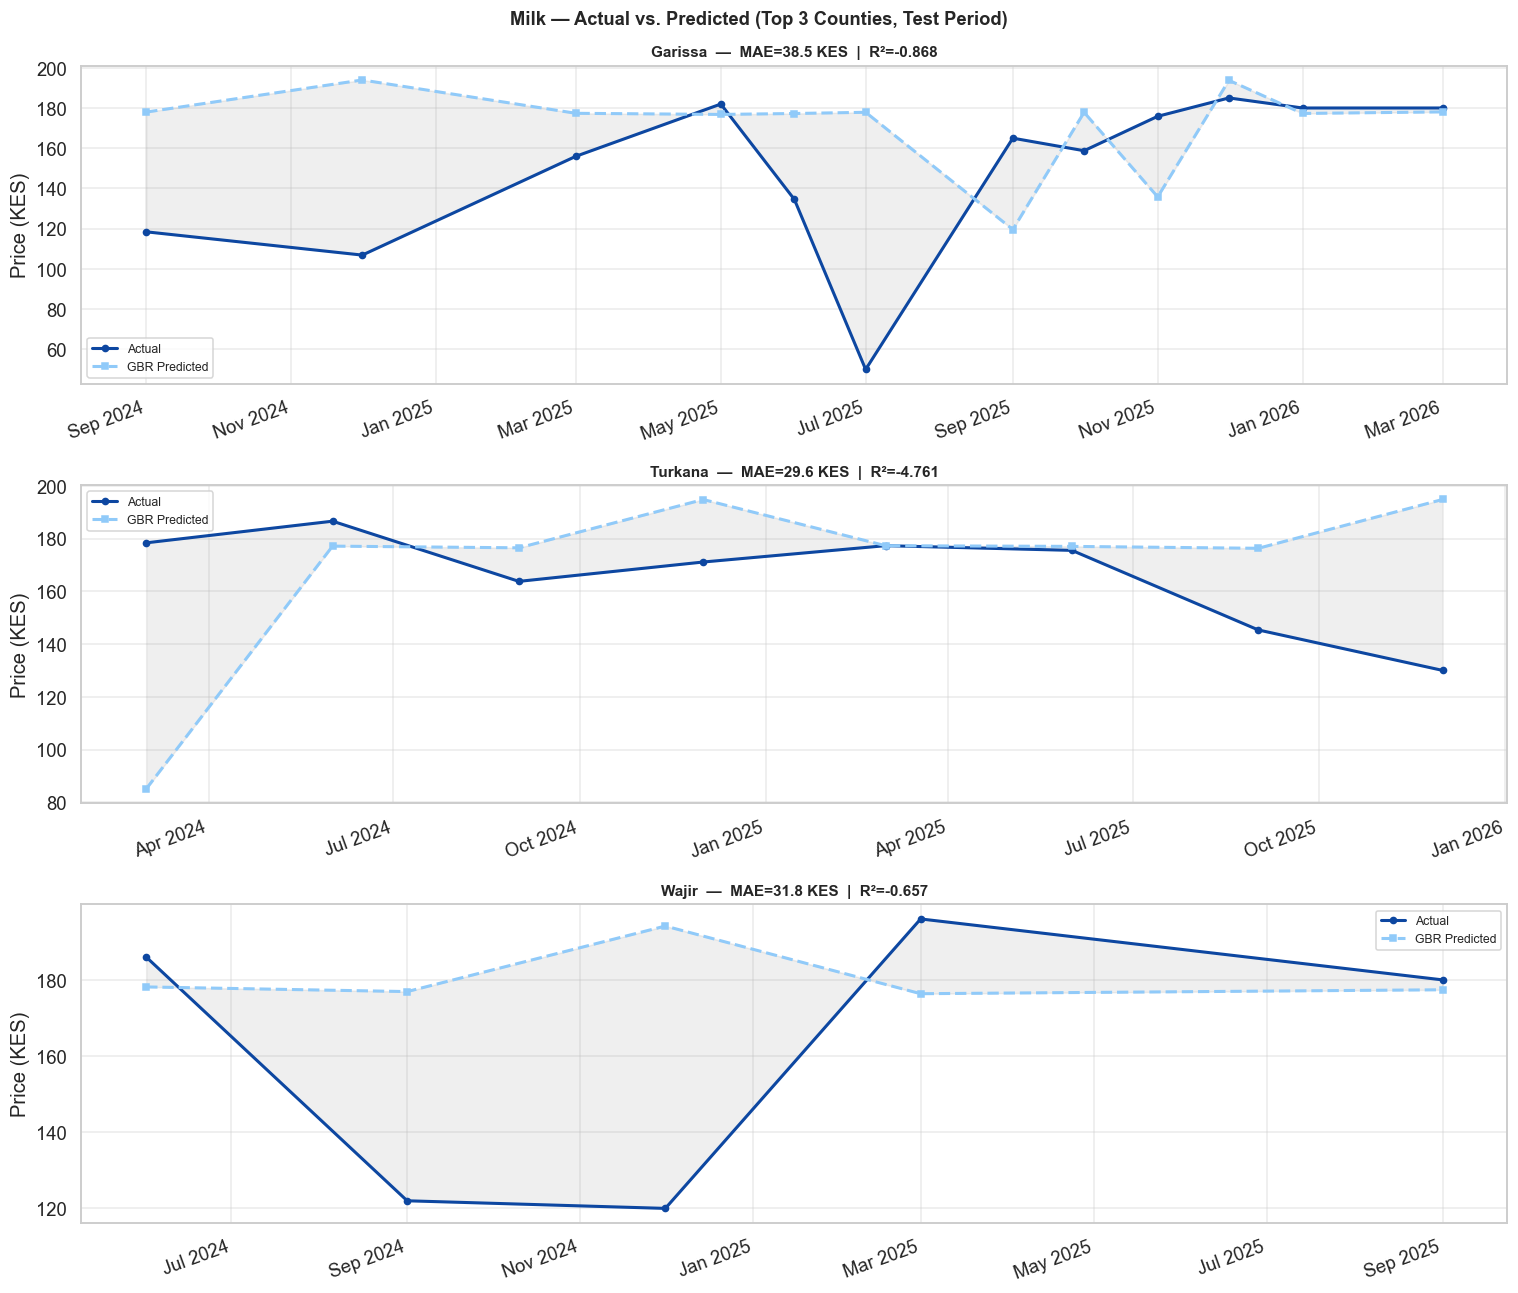

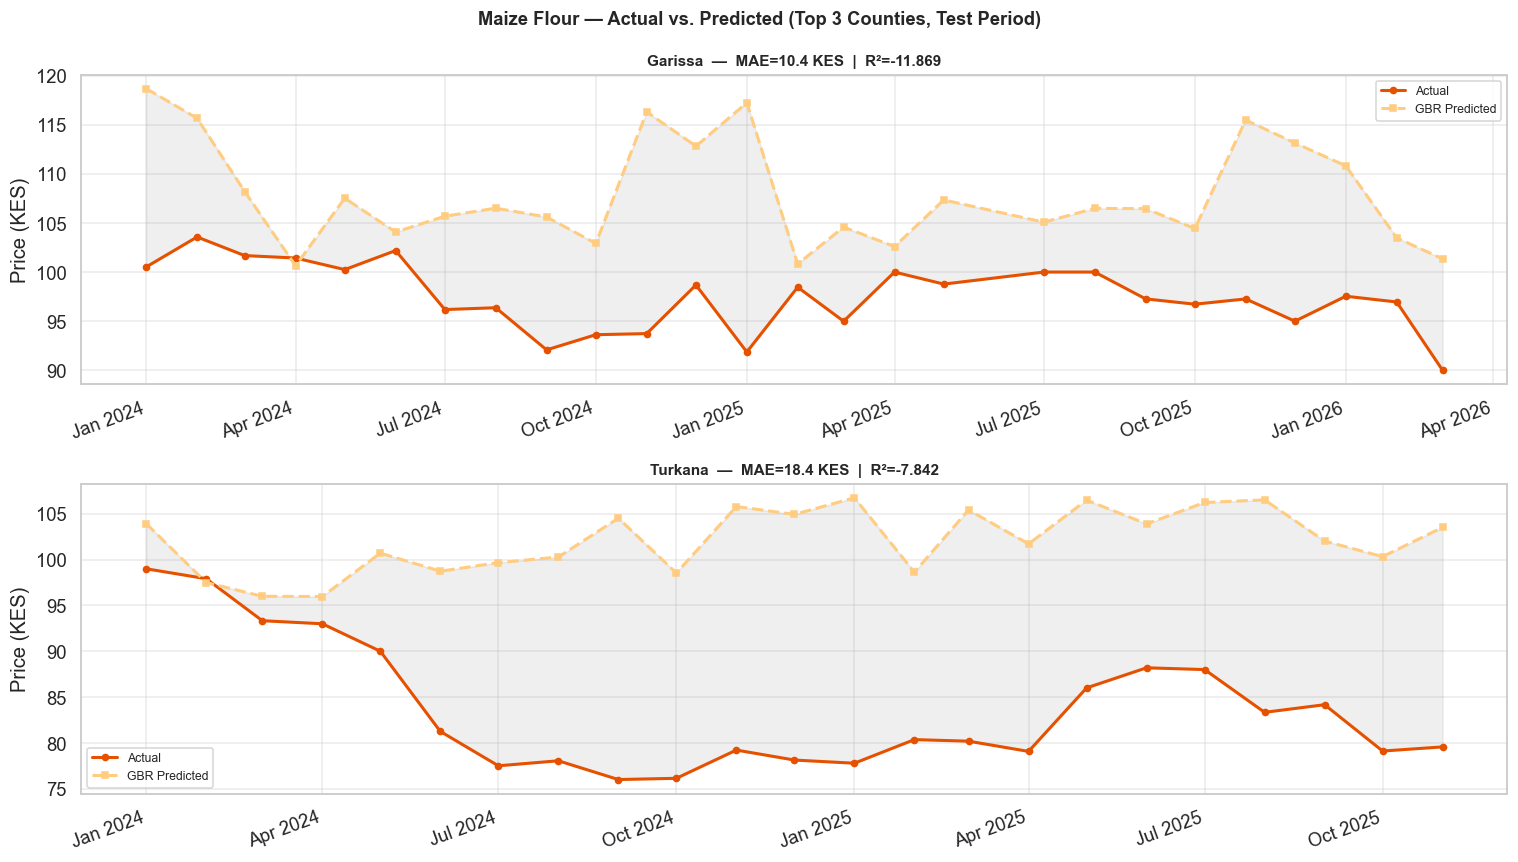

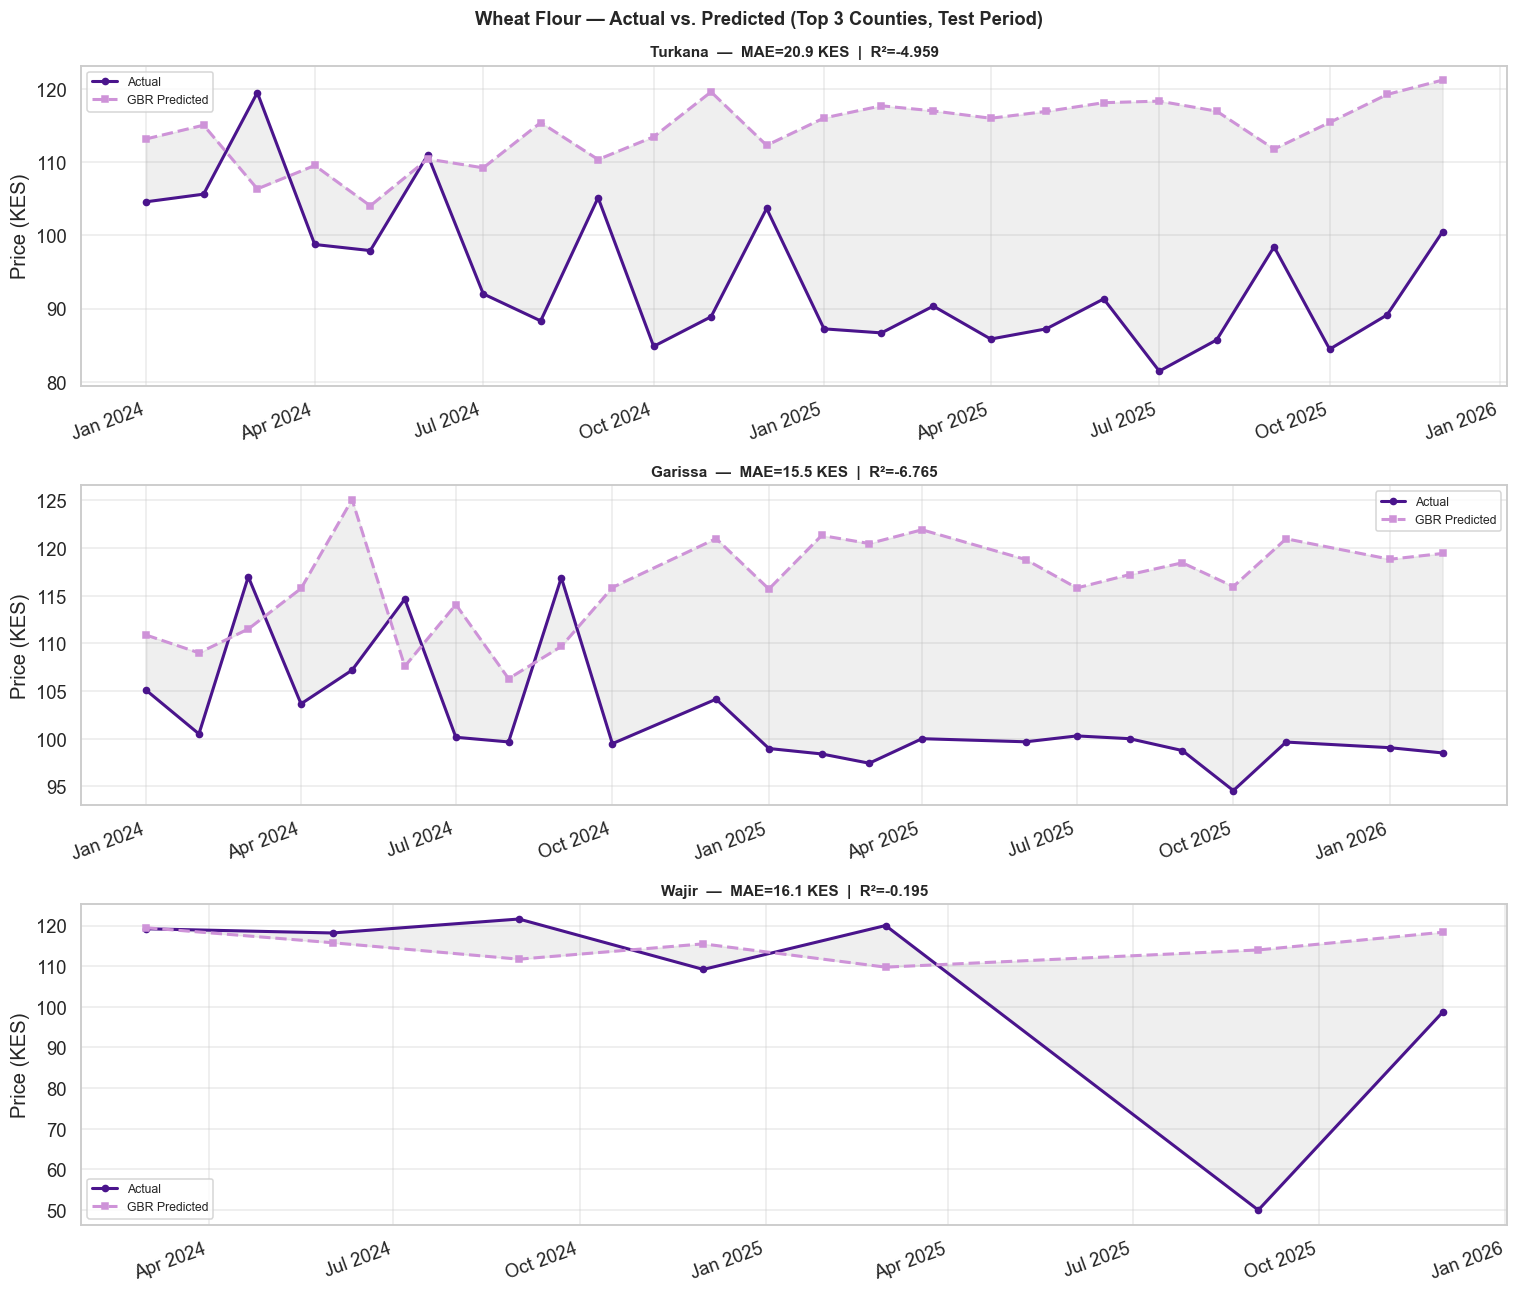

In [48]:
# Time-series: Actual vs Predicted for each commodity — top 3 counties
act_colors  = ['#BF360C','#1B5E20','#0D47A1','#E65100','#4A148C']
pred_colors = ['#EF9A9A','#A5D6A7','#90CAF9','#FFCC80','#CE93D8']

for i, comm in enumerate(commodities_done):
    res    = comm_results[comm]
    df_c   = res['df_c']
    te_mask = res['te_mask']

    test_c = df_c[te_mask].copy()
    test_c['predicted'] = res['preds']['GBR']

    top_counties = (test_c.groupby('county')['price']
                    .count().nlargest(3).index.tolist())

    n_counties = len(top_counties)
    fig, axes  = plt.subplots(n_counties, 1,
                               figsize=(14, 4 * n_counties), sharex=False)
    if n_counties == 1:
        axes = [axes]

    for ax, county in zip(axes, top_counties):
        sub = test_c[test_c['county'] == county].sort_values('date_month')
        if sub.empty:
            ax.set_title(f'{county} — no test data')
            continue
        mae_loc = mean_absolute_error(sub['price'], sub['predicted'])
        r2_loc  = r2_score(sub['price'], sub['predicted']) if len(sub) > 2 else float('nan')

        ax.plot(sub['date_month'], sub['price'],
                'o-', lw=2, ms=4, color=act_colors[i],  label='Actual')
        ax.plot(sub['date_month'], sub['predicted'],
                's--', lw=2, ms=4, color=pred_colors[i], label='GBR Predicted')
        ax.fill_between(sub['date_month'],
                        sub['price'], sub['predicted'],
                        alpha=0.12, color='grey')
        ax.set_title(f'{county}  —  MAE={mae_loc:.1f} KES  |  R²={r2_loc:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_ylabel('Price (KES)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.4)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

    plt.suptitle(f'{comm} — Actual vs. Predicted (Top 3 Counties, Test Period)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 8.10. Final Consolidated Leaderboard — All Commodities

╔═══════════════════════════════════════════════════════════════════════════╗
  FINAL LEADERBOARD — Best Model per Commodity
╚═══════════════════════════════════════════════════════════════════════════╝
   Commodity Best Model  MAE (KES)  RMSE (KES)      R²  MAE % of Price  Test Rows
       Maize         LR       5.78        8.16  0.2462             8.8         46
 Wheat Flour         RF      14.24       17.19 -0.8330            13.8         82
       Beans         LR      21.30       26.39 -0.3145            14.5         74
 Maize Flour        GBR      14.16       16.40 -2.5806            15.6         49
        Milk         LR      37.50       48.30 -1.0911            24.9         43


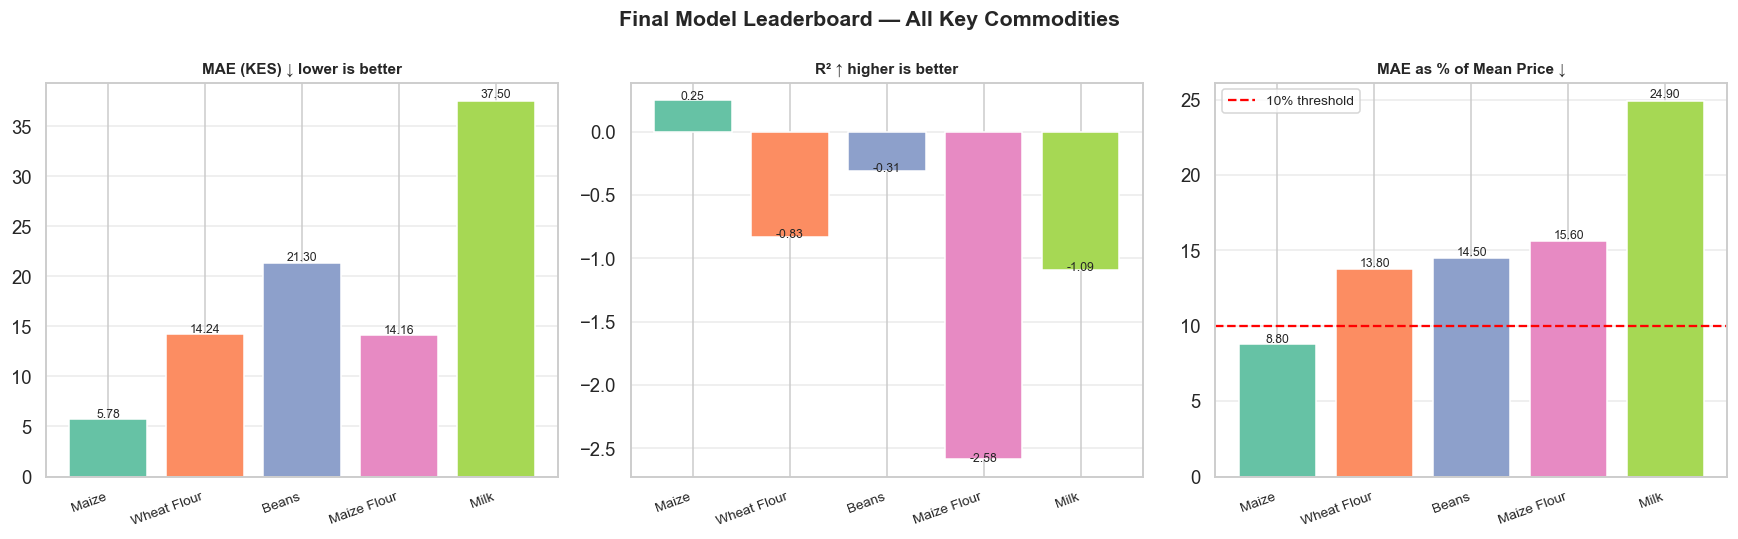

In [49]:
# Final leaderboard: best model per commodity + CV summary
leaderboard_rows = []
for comm in commodities_done:
    res  = comm_results[comm]
    mets = res['metrics']
    best_model = min(mets, key=lambda m: mets[m]['MAE'])
    bm = mets[best_model]
    mean_price = res['y_te'].mean()
    leaderboard_rows.append({
        'Commodity':      comm,
        'Best Model':     best_model,
        'MAE (KES)':      round(bm['MAE'], 2),
        'RMSE (KES)':     round(bm['RMSE'], 2),
        'R²':             round(bm['R2'], 4),
        'MAE % of Price': round(bm['MAE'] / mean_price * 100, 1),
        'Test Rows':      len(res['y_te']),
    })

lb = pd.DataFrame(leaderboard_rows).sort_values('MAE % of Price')
print('╔' + '═'*75 + '╗')
print('  FINAL LEADERBOARD — Best Model per Commodity')
print('╚' + '═'*75 + '╝')
print(lb.to_string(index=False))

# Summary bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette_lb = sns.color_palette('Set2', len(lb))

for ax, col, title in zip(axes,
    ['MAE (KES)', 'R²', 'MAE % of Price'],
    ['MAE (KES) ↓ lower is better',
     'R² ↑ higher is better',
     'MAE as % of Mean Price ↓']):
    bars = ax.bar(lb['Commodity'], lb[col], color=palette_lb, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticklabels(lb['Commodity'], rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    for bar, v in zip(bars, lb[col]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()*1.01,
                f'{v:.2f}', ha='center', fontsize=8)

# Add threshold line on MAE % chart
axes[2].axhline(10, color='red', ls='--', lw=1.5, label='10% threshold')
axes[2].legend(fontsize=9)

plt.suptitle('Final Model Leaderboard — All Key Commodities',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
